# PART6_Select_genomic_regions_and_useful_RILs

Select top3 beneficial genomic regions and top3 detrimental genomic regions.

Then, useful RILs were selected based on selected genomic regions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import ast
from numpy import random as rnd
import random
import copy
import itertools
from tqdm import tqdm
from scipy.stats import zscore
sns.set()


from sklearn.linear_model import ElasticNet

from modules.make_data_for_prediction import make_data
from modules.tuning import tuning_ElasticNet
from modules.training_module import train_Enet

from modules.breeding import make_regional_info, get_top_regions, plot_regional_info, plot_regional_info_with_target, target_effect_summary, visualize_line_genotype, visualize_RIL_genotype

# Extract HBs for 3 economical traits

merge haplotype blocks for grain number, panicle number, grain size.

In [2]:
with open('../data/PART4_Select_HBs/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)

genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
Breeding_genotype = pd.read_csv("../data/PART5_validate_with_Breeding_lines/Haplotype_Breeding_LD90.csv")

merge_index = []
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    model = trait_summary.sort_values(by="r", ascending=False).iloc[0, 1]
    print(trait_name, model, HB_num)
    
    with open('../data/PART4_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary_all_HB = pickle.load(p)
    summary_all_HB = pd.DataFrame(summary_all_HB)
    
    imp = np.mean(summary_all_HB.loc[(summary_all_HB.iloc[:, 0] == trait_name) & (summary_all_HB.iloc[:, 2] == model), 6].values, axis=0)
    merge_index.extend(np.argsort(np.abs(imp))[::-1][:HB_num])
    
path = "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv"
genotype.loc[np.sort(np.unique(merge_index)), :].to_csv(path, index=None)
Breeding_path = "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_Breeding_high_imp_HBs_for_3traits.csv"
Breeding_genotype.loc[np.sort(np.unique(merge_index)), :].to_csv(Breeding_path, index=None)

GN_mean Enet 900
PN_mean Enet 1000
Area.size.AS..mm2. Enet 600


# Parameter tuning for selected HBs

In [ ]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype = "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV=5
optuna_seed=1024

Enet_params = []
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    # Tuning Enet        
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)
    for i in range(CV):
        train_data_CVn = train_data[i]
        X = train_data_CVn[0]; y = train_data_CVn[1]
        Enet_params.append([trait_name, i, tuning_ElasticNet(X, y)])
    
pd.DataFrame(Enet_params).to_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Enet_high_imp_HBs_params.csv")

# Train models

In [7]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype = "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 
summary = []
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)
    for i in range(CV):
        tmp_test_data = test_data[i]
        tmp_train_data = train_data[i]
        Enet_params = pd.read_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        test_pred, r2, acc_RIL, coefs = train_Enet(tmp_test_data, tmp_train_data, Enet_params)
        summary.append(["Enet", i, trait_name, test_pred, r2, acc_RIL, coefs])
with open('../data/PART6_Select_genomic_regions_and_useful_RILs/Enet_all_traits_high_imp_HBs.pic.bin', 'wb') as p:
    pickle.dump(summary, p)

# Check accuracy of model

In [2]:
with open('../data/PART6_Select_genomic_regions_and_useful_RILs/Enet_all_traits_high_imp_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)
summary.groupby(2).mean()

,1,4
2,,
Area.size.AS..mm2.,2.0,0.881168
GN_mean,2.0,0.895246
PN_mean,2.0,0.904726


In [3]:
each_RIL_accs = []
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    each_RILs_CVs = summary[summary.iloc[:, 2] == trait_name].iloc[:, 5]
    tmp = []
    for each_RILs in each_RILs_CVs:
        tmp.append(each_RILs[0])
    tmp = np.mean(tmp, axis=0)
    each_RIL_accs.append(tmp)
each_RIL_accs = pd.DataFrame(each_RIL_accs)
each_RIL_accs.columns = each_RILs[1]
each_RIL_accs.index = ["GN_mean", "PN_mean", "Area.size.AS..mm2."]
each_RIL_accs

,N01,N03,N04,N05,N06,N07,N08,N09,N10,N11,N12,N13,N14,N16,N17,N18,N19,N20,N21
GN_mean,0.882944,0.845200,0.849732,0.848747,0.872003,0.876546,0.809121,0.739622,0.662543,0.838076,0.785680,0.772544,0.862234,0.675542,0.882882,0.849249,0.834483,0.590285,0.684308
PN_mean,0.876064,0.778808,0.887789,0.862159,0.853792,0.921299,0.902731,0.834395,0.745129,0.847416,0.816441,0.891356,0.835643,0.742682,0.719190,0.883581,0.803288,0.608620,0.826689
Area.size.AS..mm2.,0.771036,0.813825,0.736055,0.878490,0.737221,0.558585,0.792005,0.792102,0.783634,0.855012,0.731890,0.784174,0.445842,0.927153,0.759066,0.730697,0.606492,0.740721,0.775199


# Select genomic regions with high genetic effect and useful RILs

## check genotype effects

In [4]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
imp_data = pd.read_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv").iloc[:, :3]
imp_data["GN_imps"] = np.mean(summary[summary.iloc[:, 2] == "GN_mean"].iloc[:, 6].values, axis=0)
imp_data["PN_imps"] = np.mean(summary[summary.iloc[:, 2] == "PN_mean"].iloc[:, 6].values, axis=0)
imp_data["GS_imps"] = np.mean(summary[summary.iloc[:, 2] == "Area.size.AS..mm2."].iloc[:, 6].values, axis=0)
imp_data["sum_zscore"] = zscore(imp_data.GN_imps) + zscore(imp_data.PN_imps) + zscore(imp_data.GS_imps)
# add RIL type columns
SNP_types = pd.DataFrame([list(str(i).zfill(len(family))) for i in imp_data.SNP_type])
SNP_types.columns = [i[:i.find("_")] for i in family]
SNP_types.index = imp_data.index.values
imp_data = pd.concat([imp_data, SNP_types], axis=1)
# add start and end columns
pos_array = imp_data.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
imp_data["start"] = pos[:, 0]
imp_data["end"] = pos[:, 1]
imp_data.to_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits_add.csv", index=None)
imp_data.head()

,chr,pos,SNP_type,GN_imps,PN_imps,GS_imps,sum_zscore,N01,N03,N04,...,N14,N16,N17,N18,N19,N20,N21,N22,start,end
0,chr01,214775_214775,20222222002200020000,-0.056993,0.008121,-0.025010,-1.505269,2,0,2,...,0,0,0,2,0,0,0,0,214775,214775
1,chr01,225668_225668,22222222002020220000,-0.204107,0.016932,-0.002993,-0.199950,2,2,2,...,2,0,2,2,0,0,0,0,225668,225668
2,chr01,539985,00222002000000200000,-0.533193,0.037530,-0.002205,-0.420309,0,0,2,...,0,0,2,0,0,0,0,0,539985,539985
3,chr01,546109_546811,00222202000220200000,-0.388413,0.025842,-0.012702,-1.093981,0,0,2,...,2,0,2,0,0,0,0,0,546109,546811
4,chr01,606022_653581,20000222000000200000,-0.447988,0.015759,0.005516,-0.503798,2,0,0,...,0,0,2,0,0,0,0,0,606022,653581


## check genetic effect on each trait for each RIL

N08


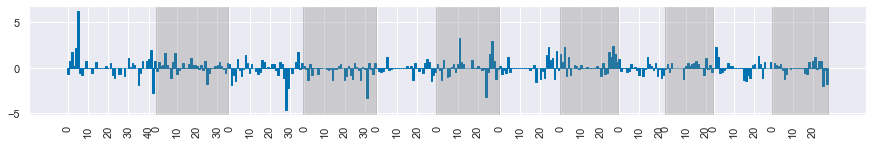

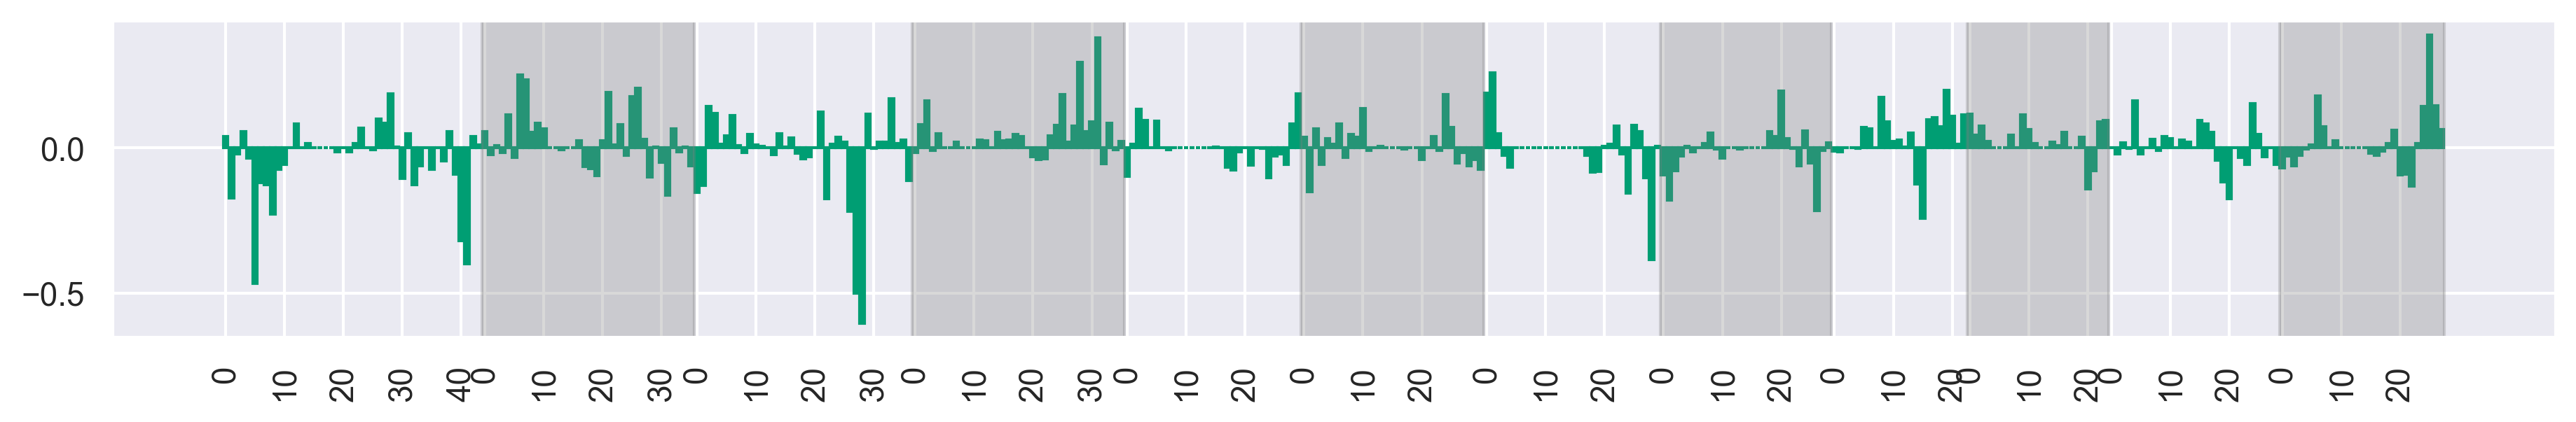

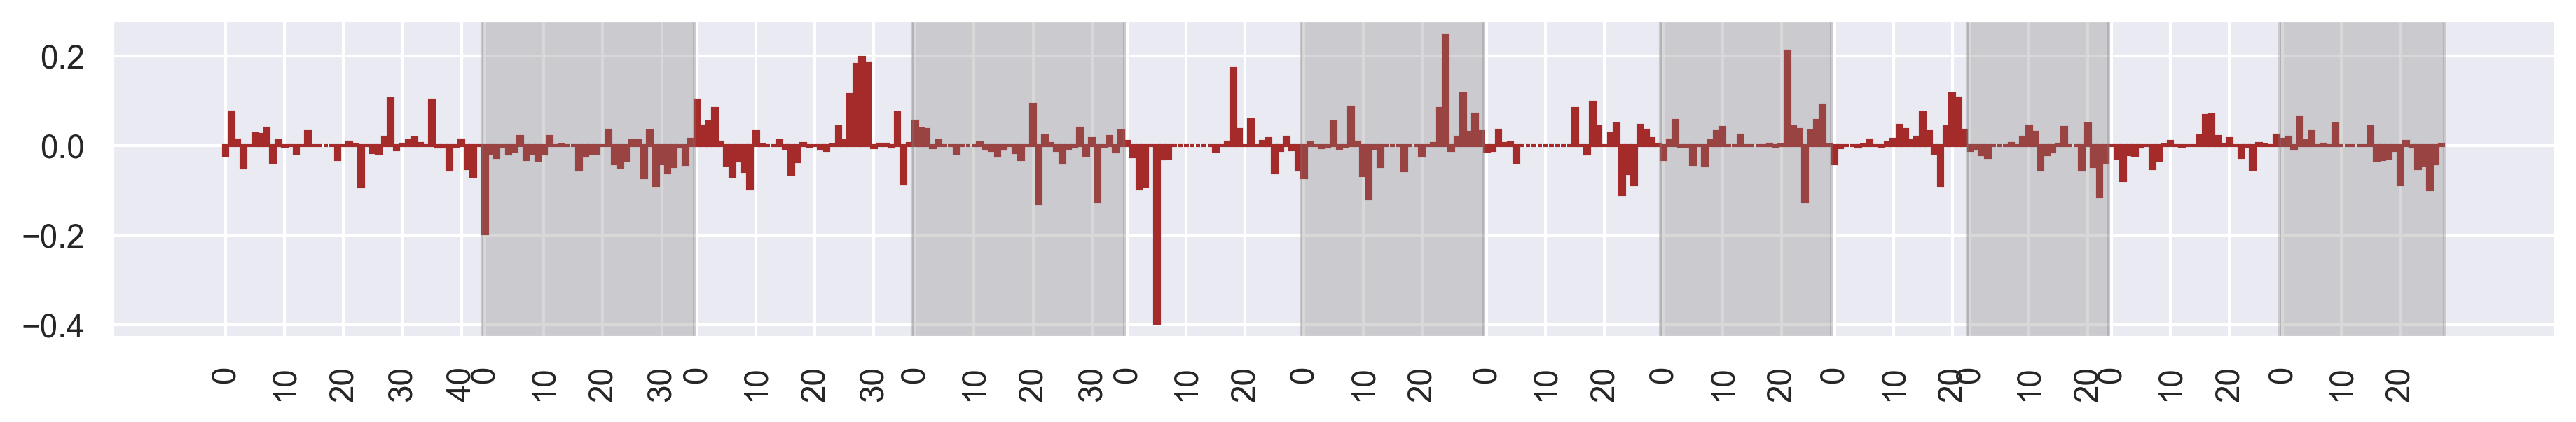

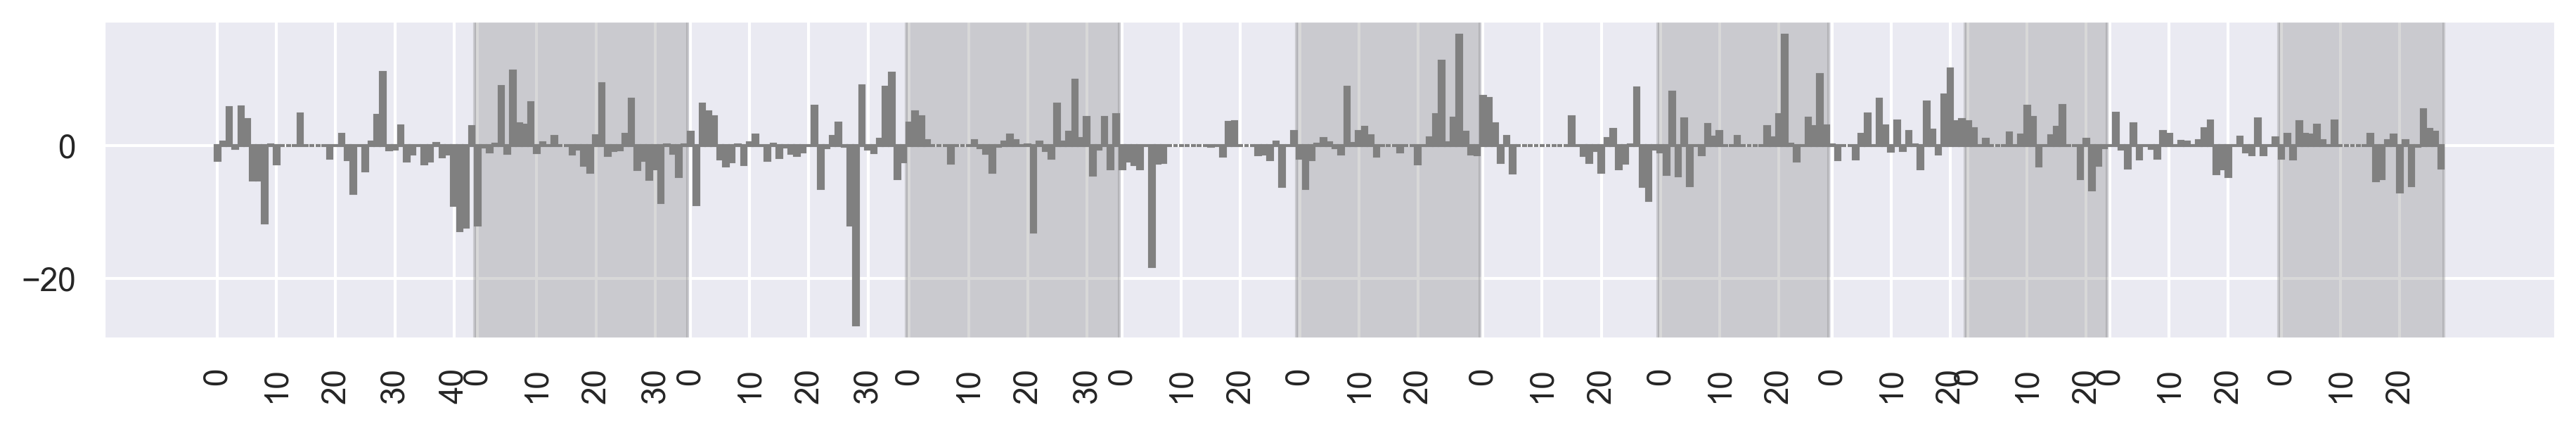

In [5]:
imp_data = pd.read_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits_add.csv")
imp_data.iloc[:, 7:27] = imp_data.iloc[:, 7:27].astype(str)
pop = "N08"
print(pop)
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
plot_regional_info(regional_info_all, "GN_imps", "#0072B2")
plot_regional_info(regional_info_all, "PN_imps", "#009E73")
plot_regional_info(regional_info_all, "GS_imps", "brown")
plot_regional_info(regional_info_all, "sum_zscore", "gray")

## Check genetic effect on GN for each candidate RIL populations

N01


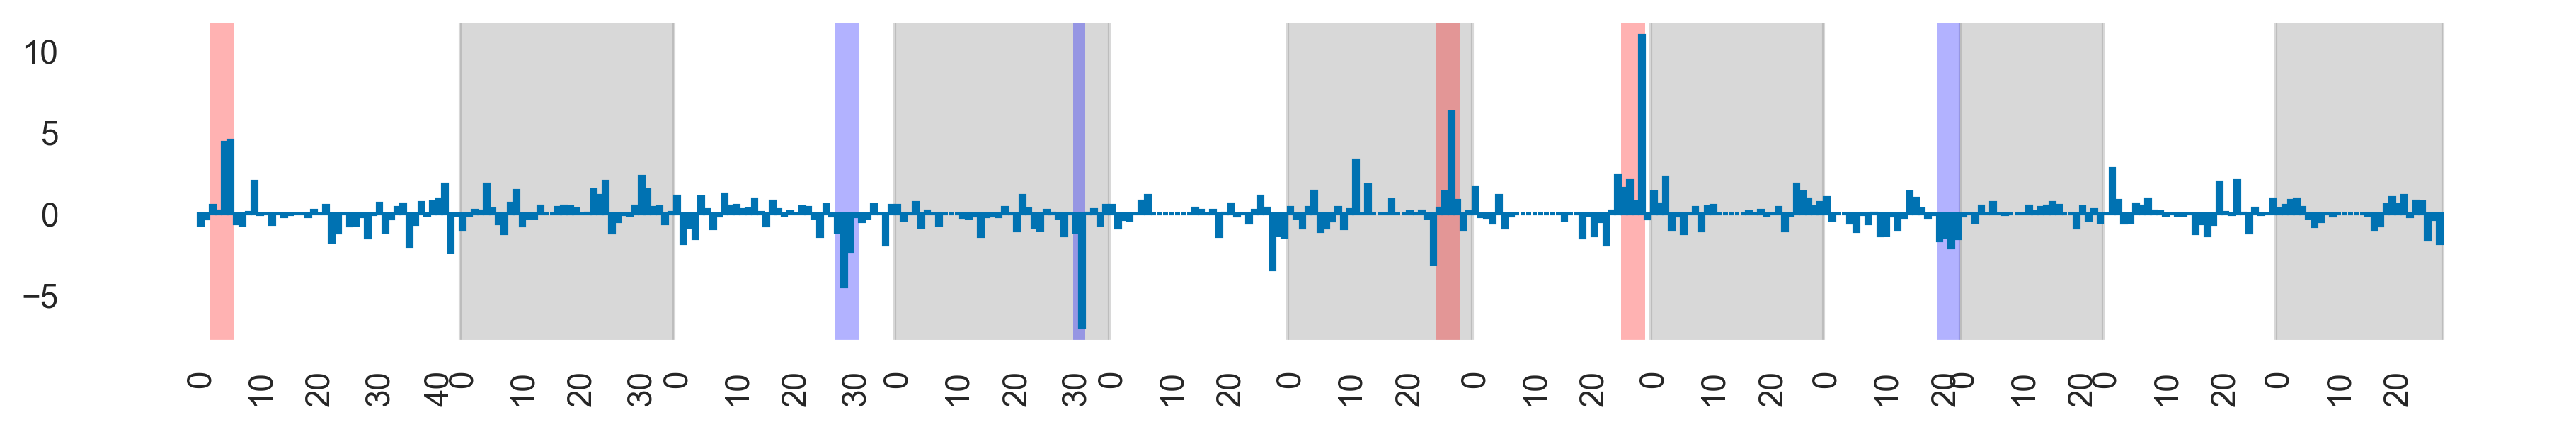

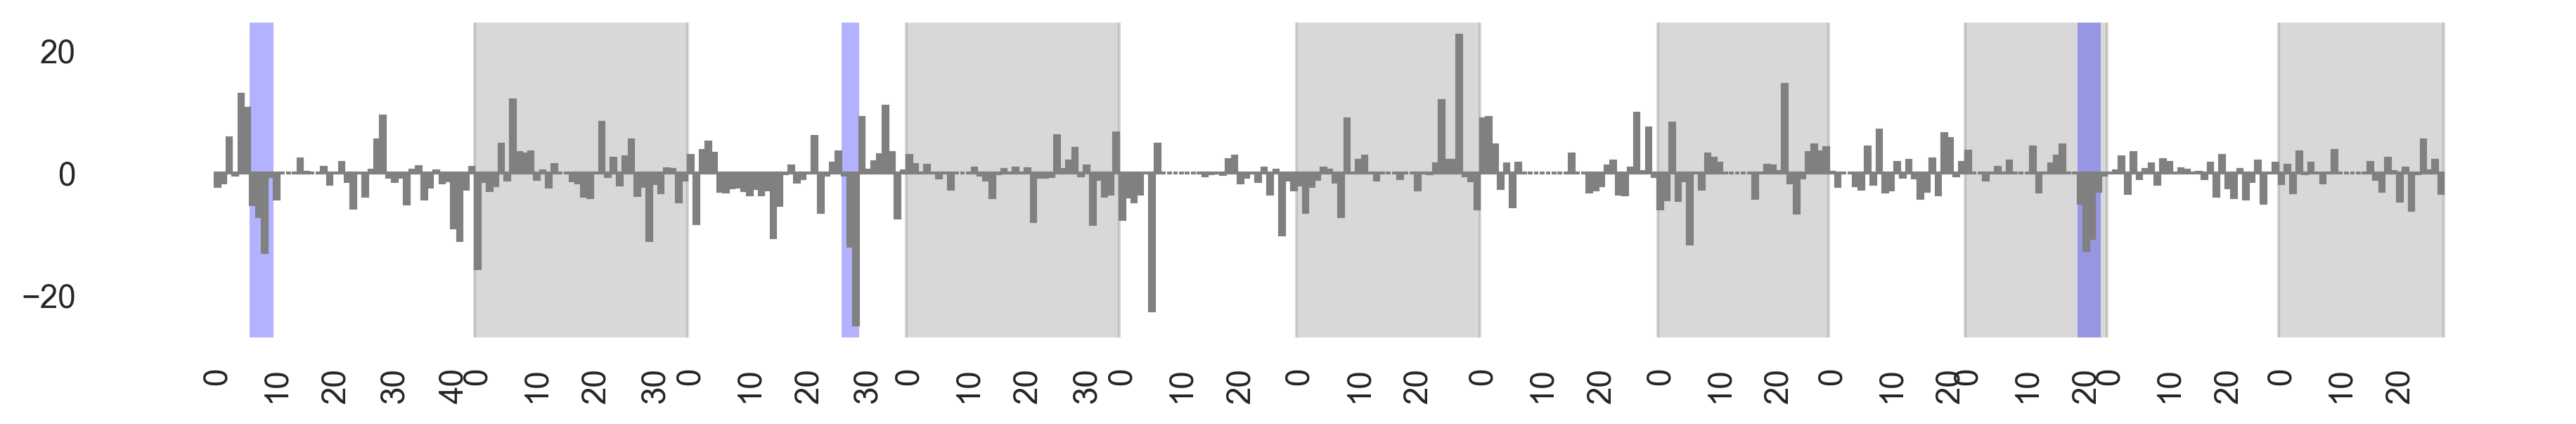

N03


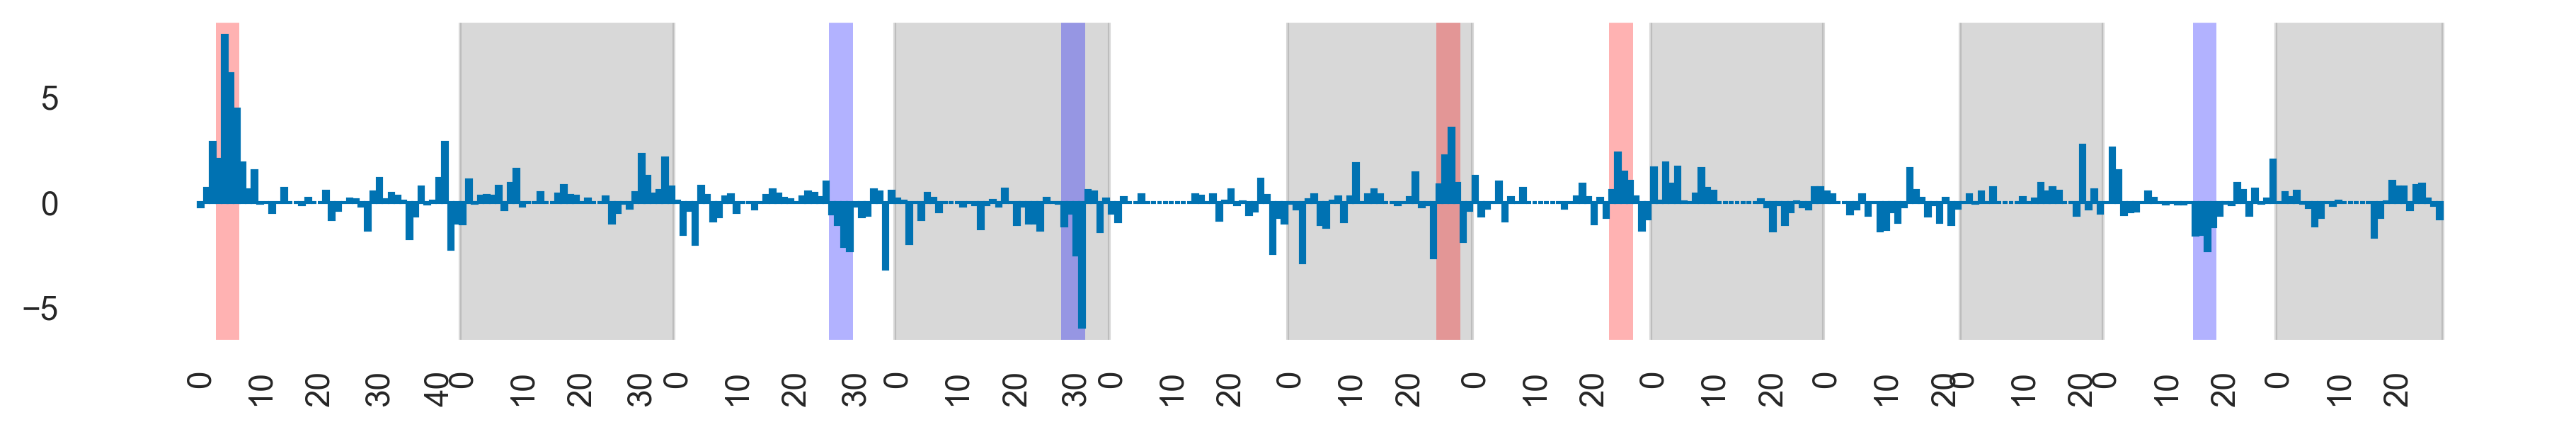

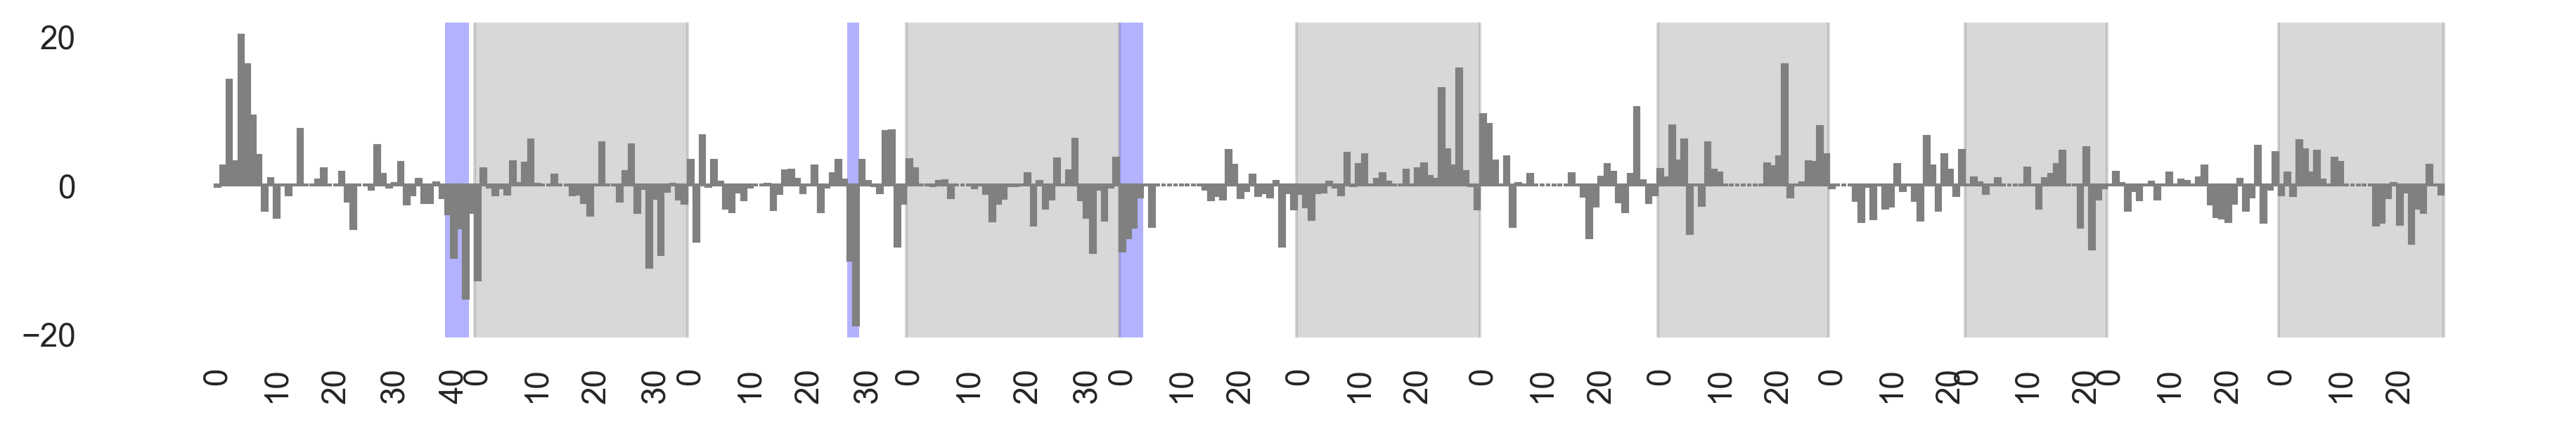

N04


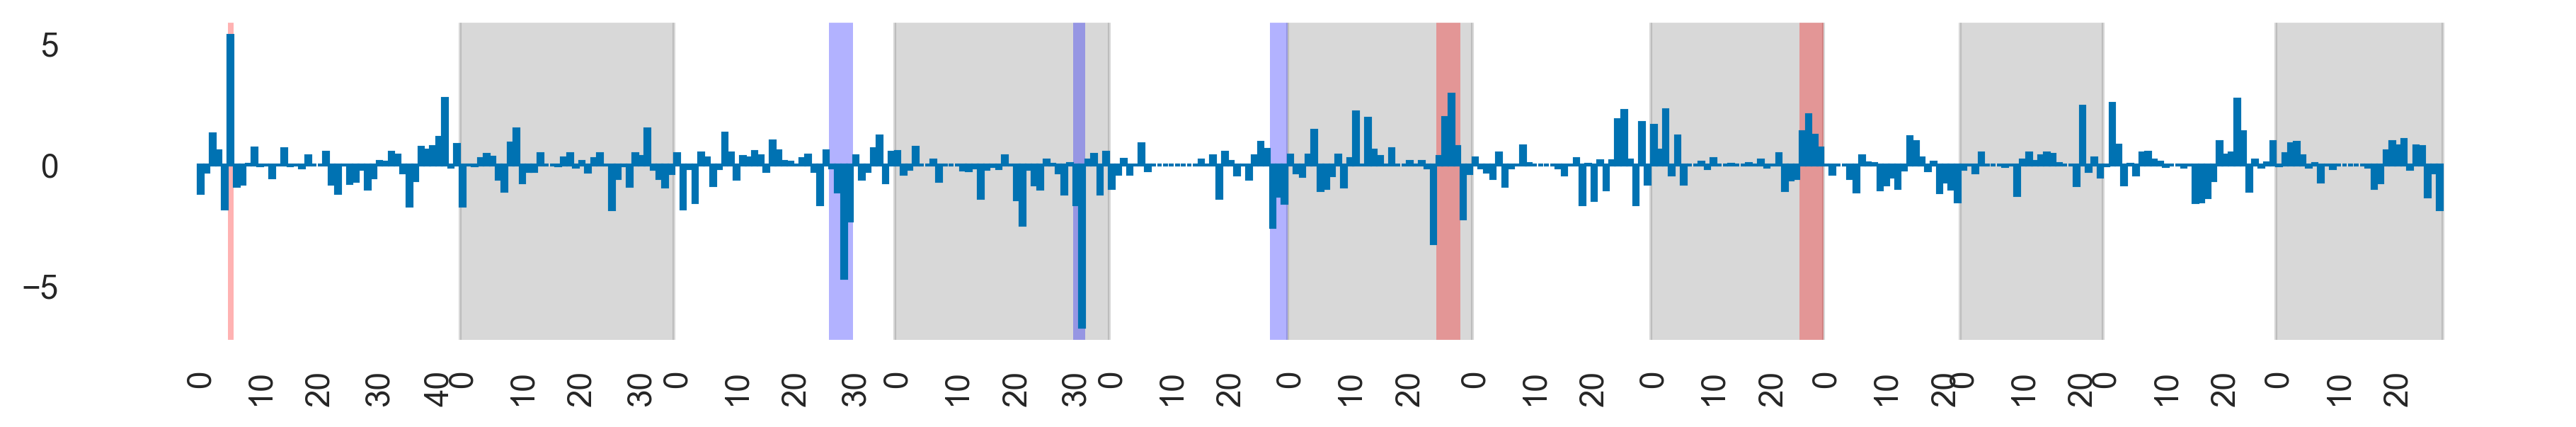

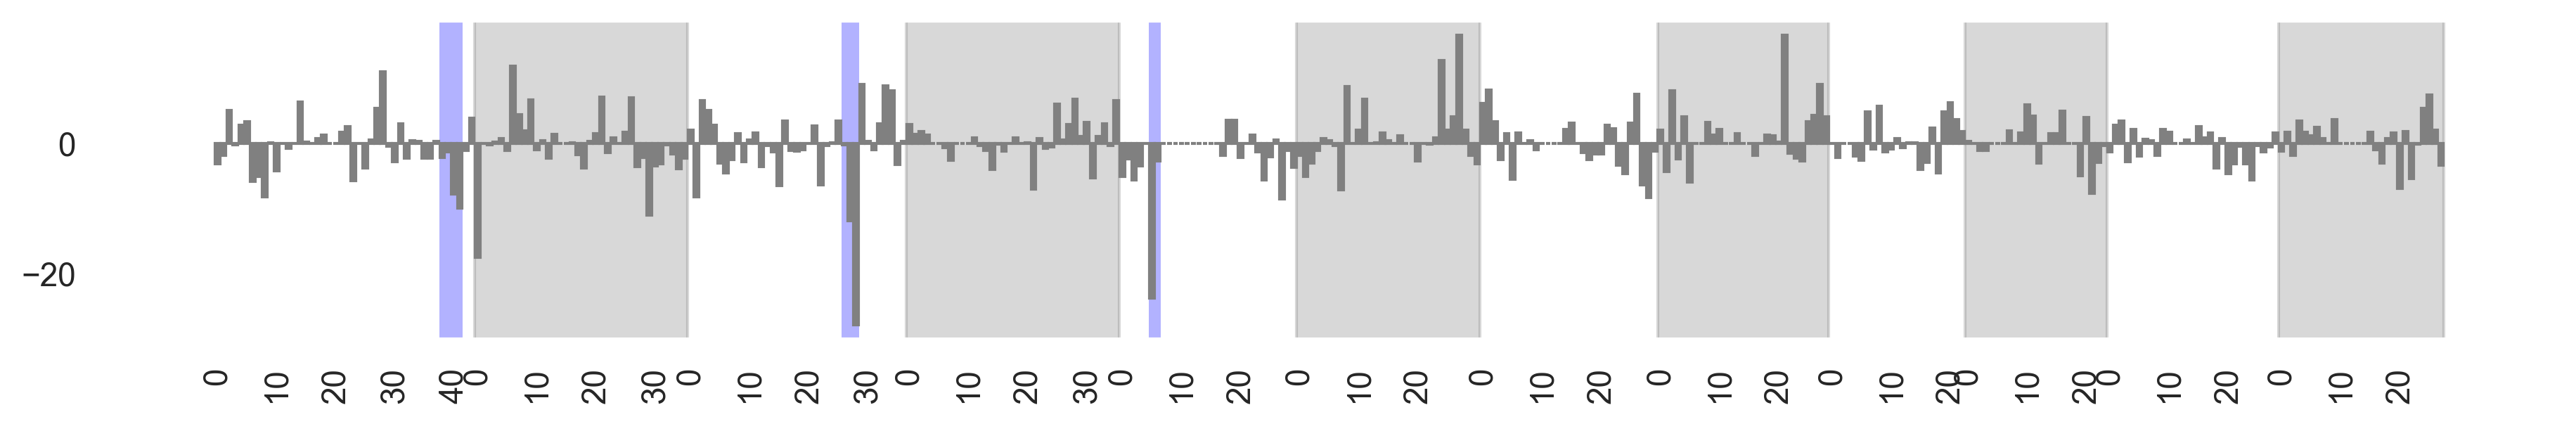

N05


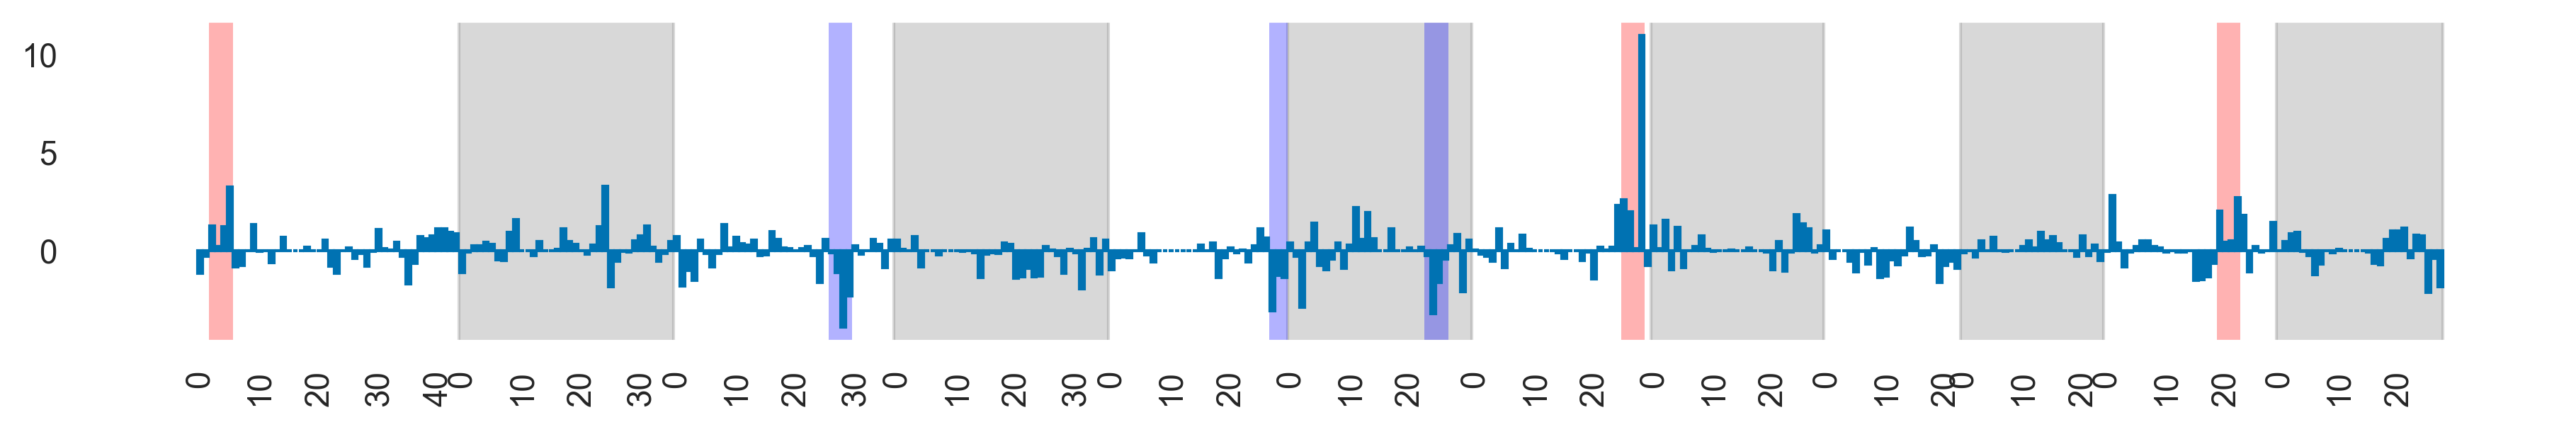

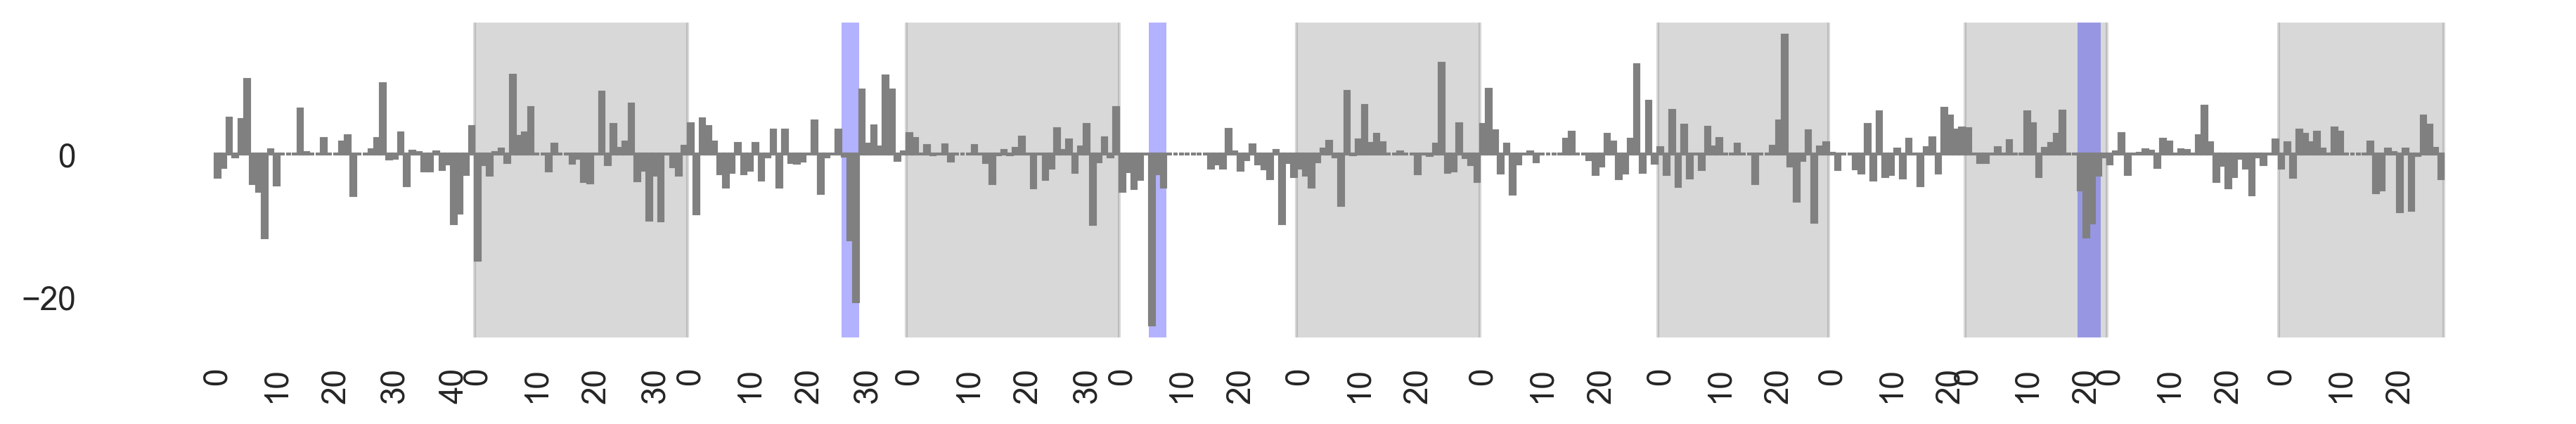

N06


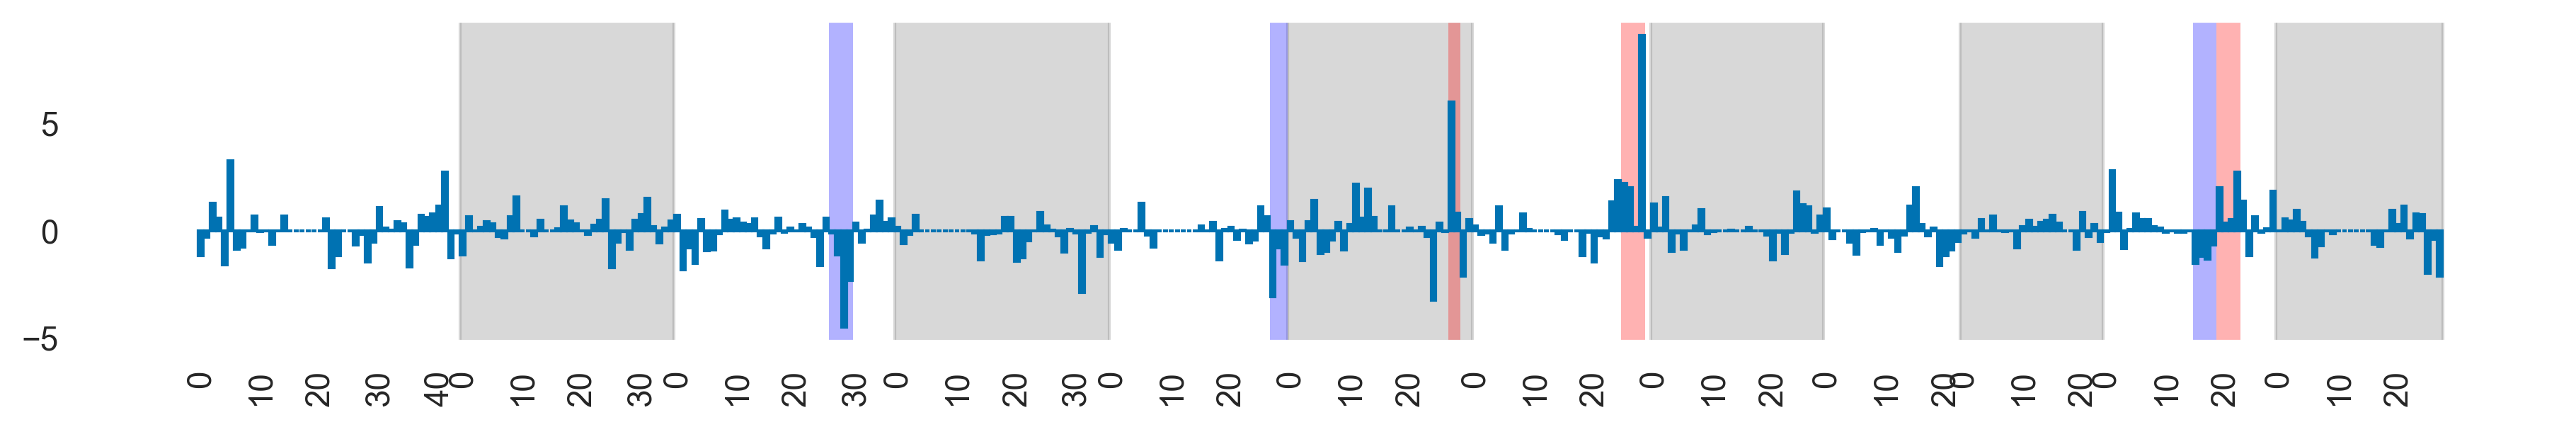

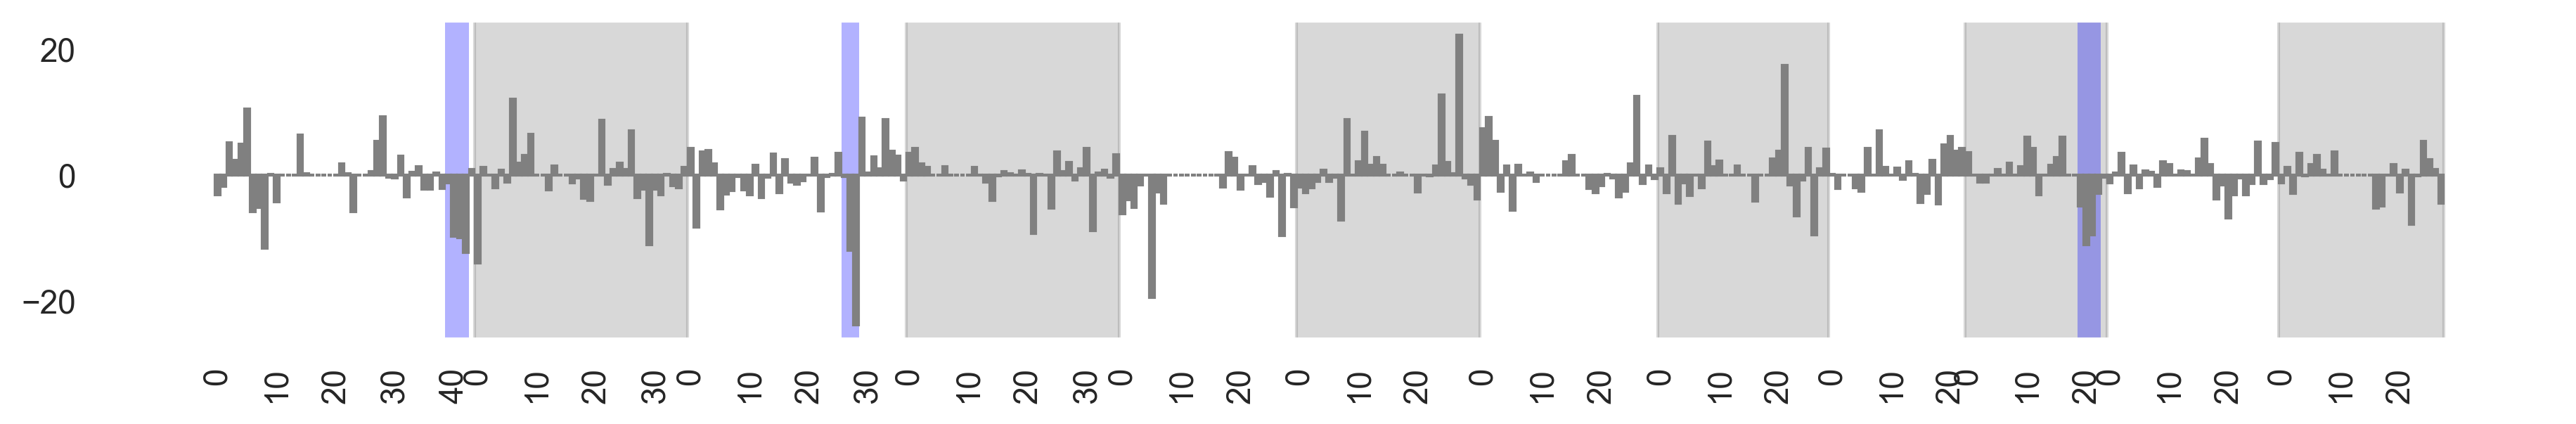

N07


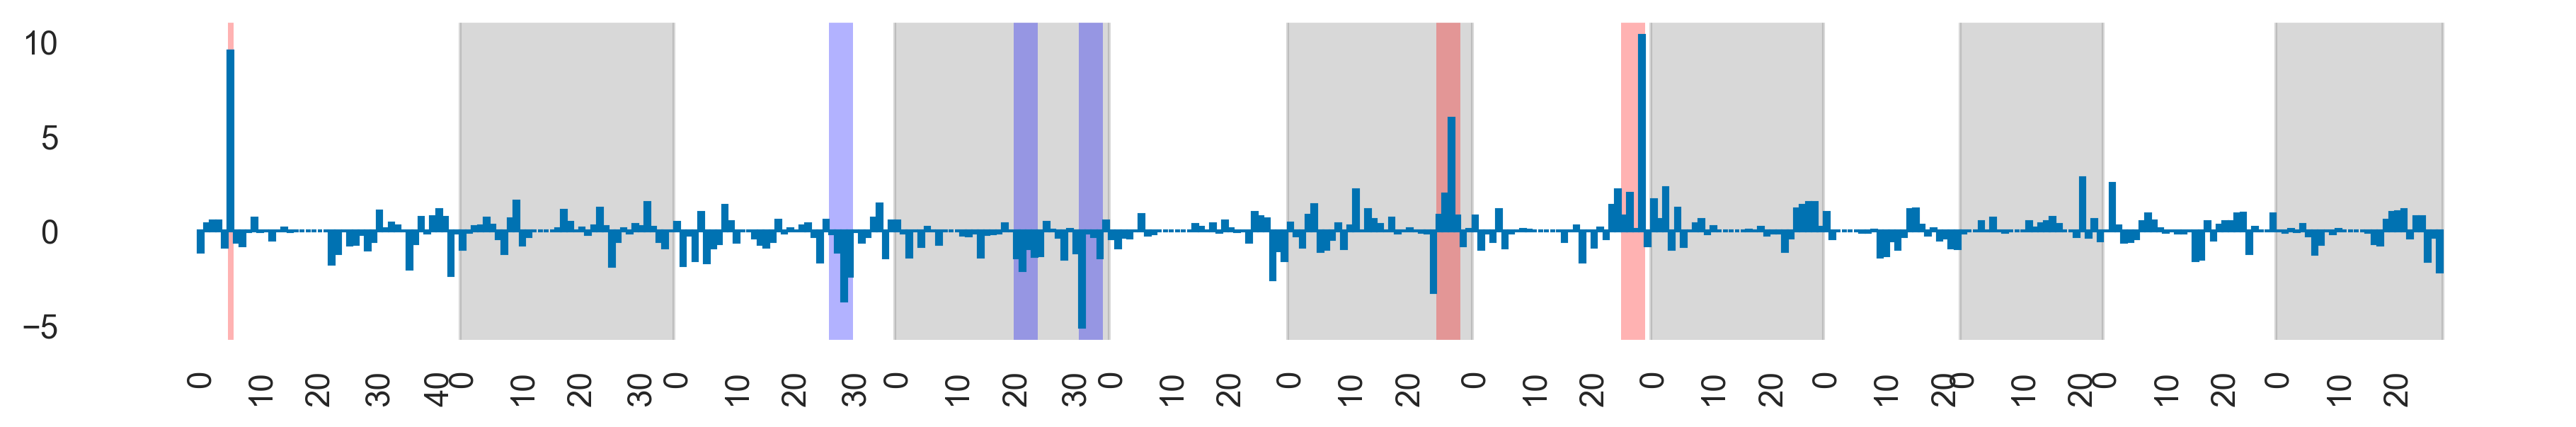

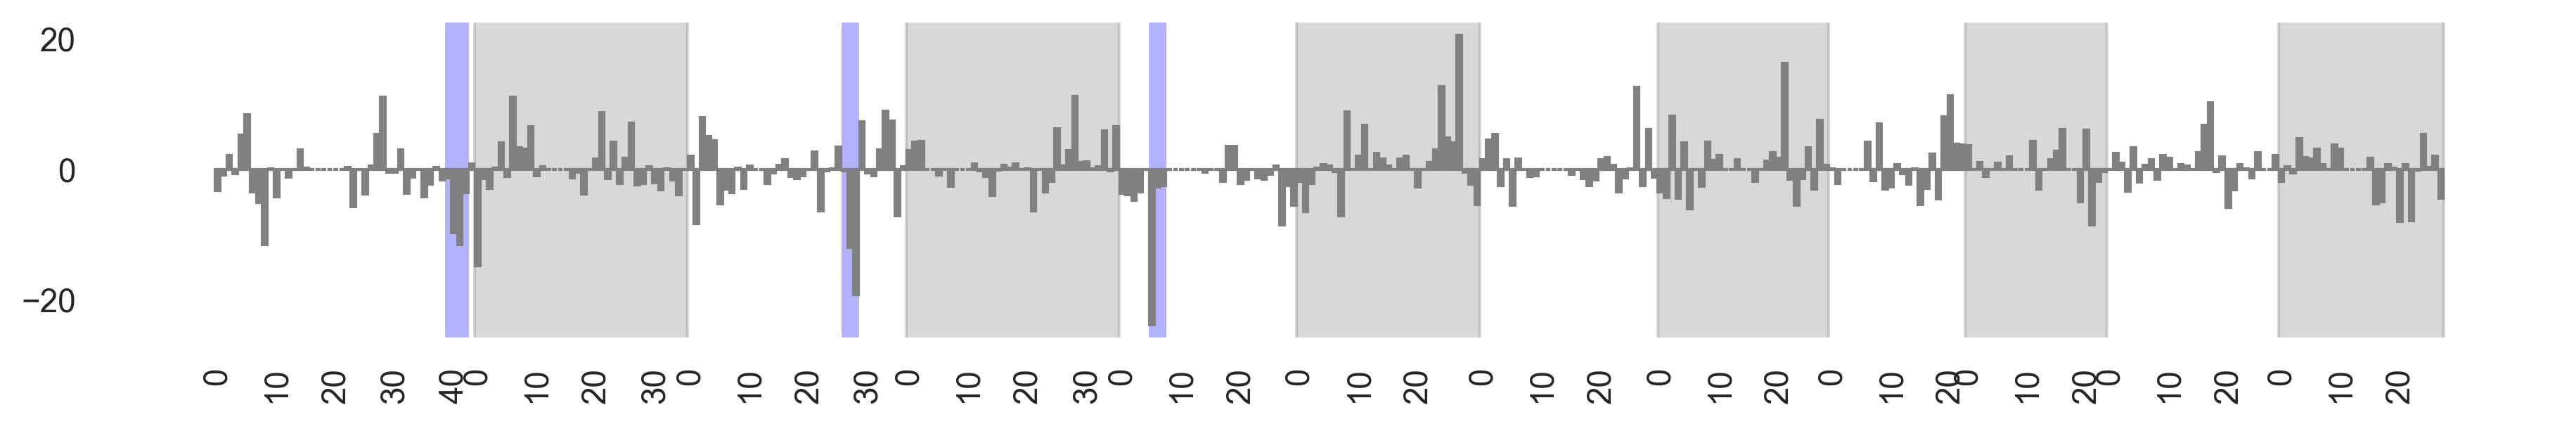

N08


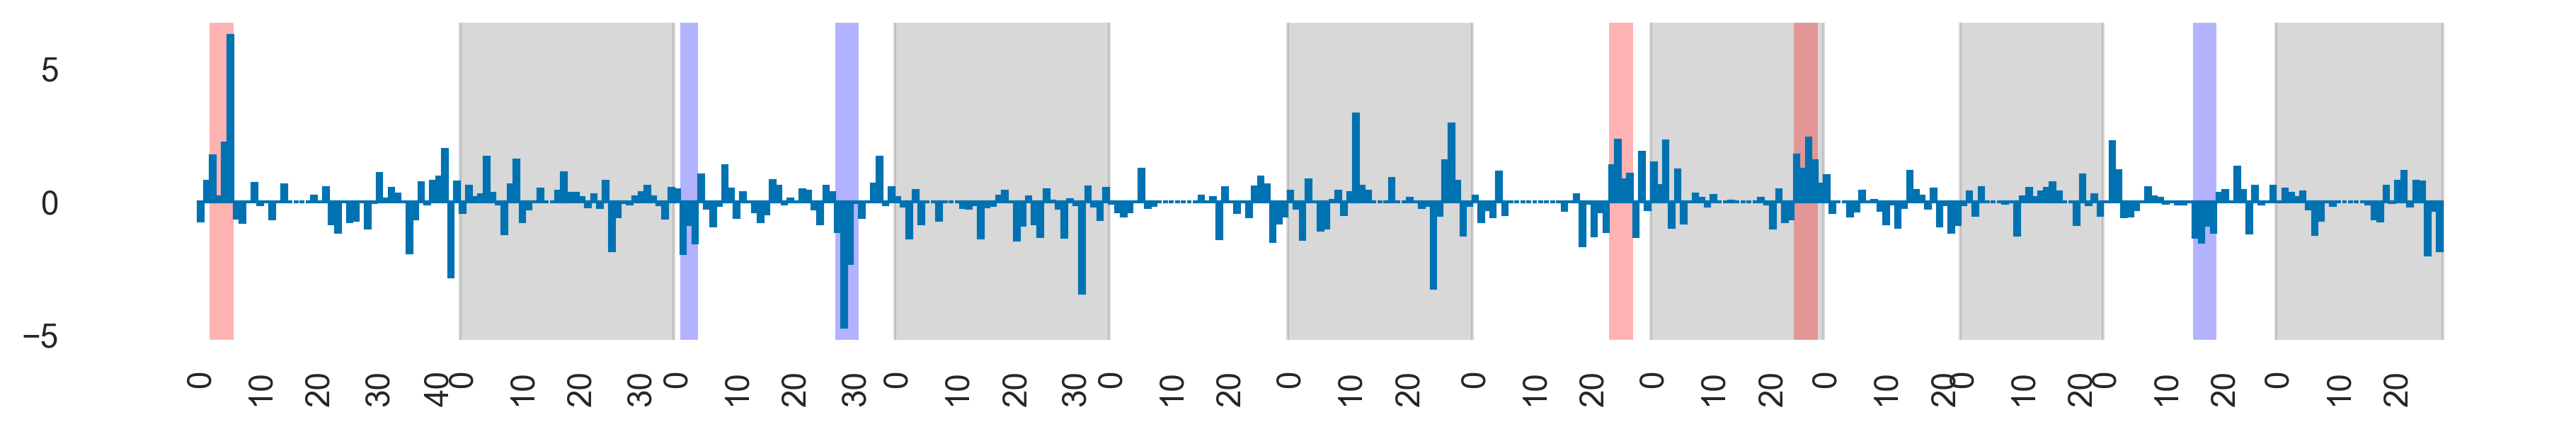

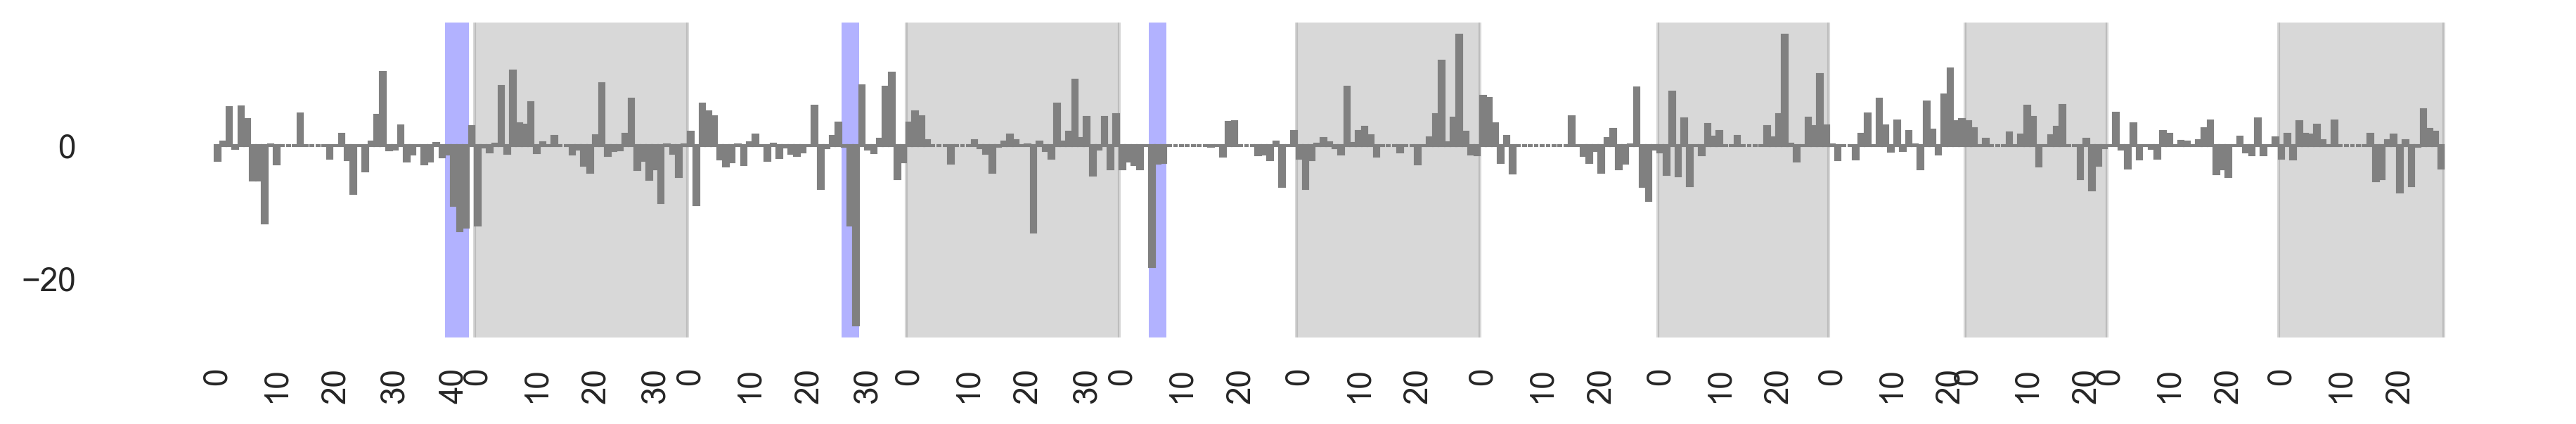

N09


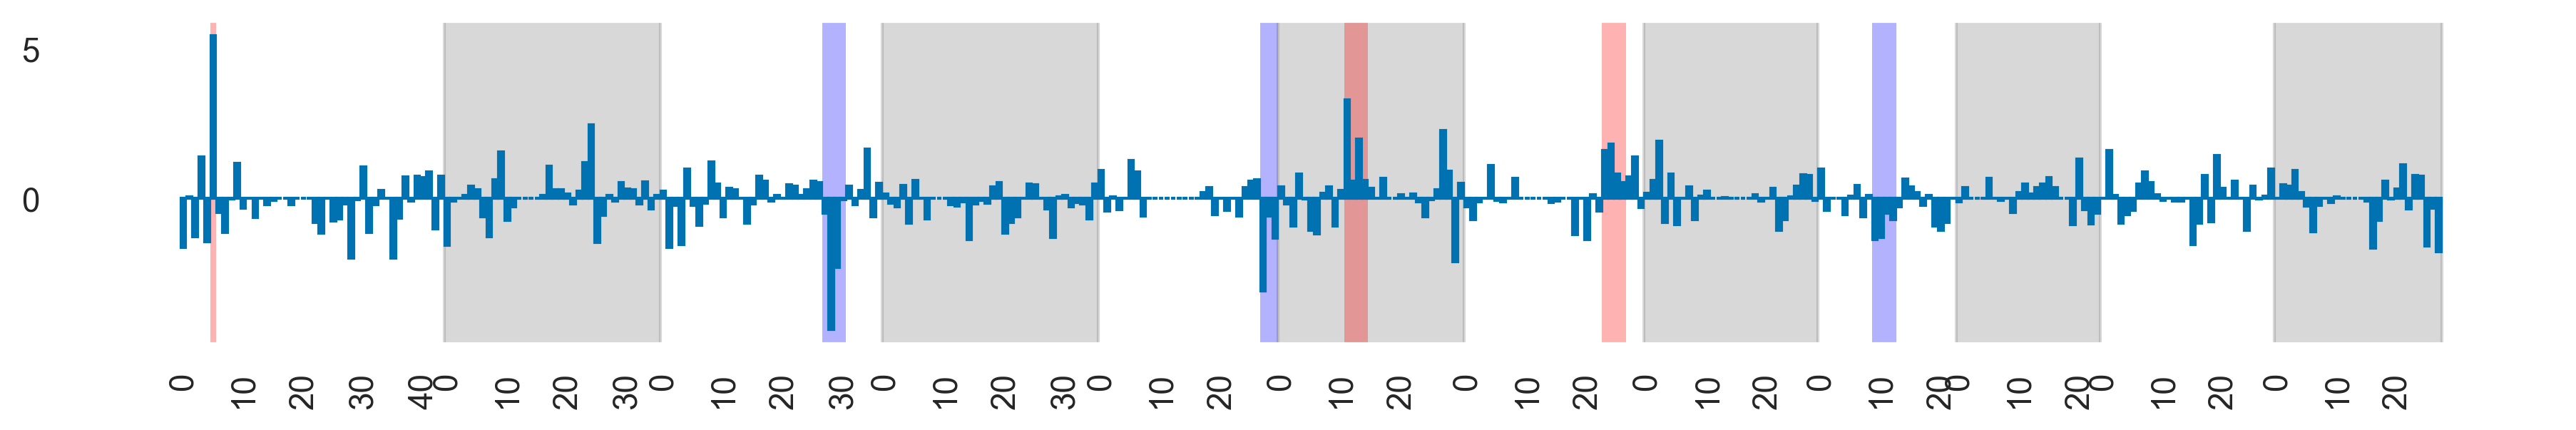

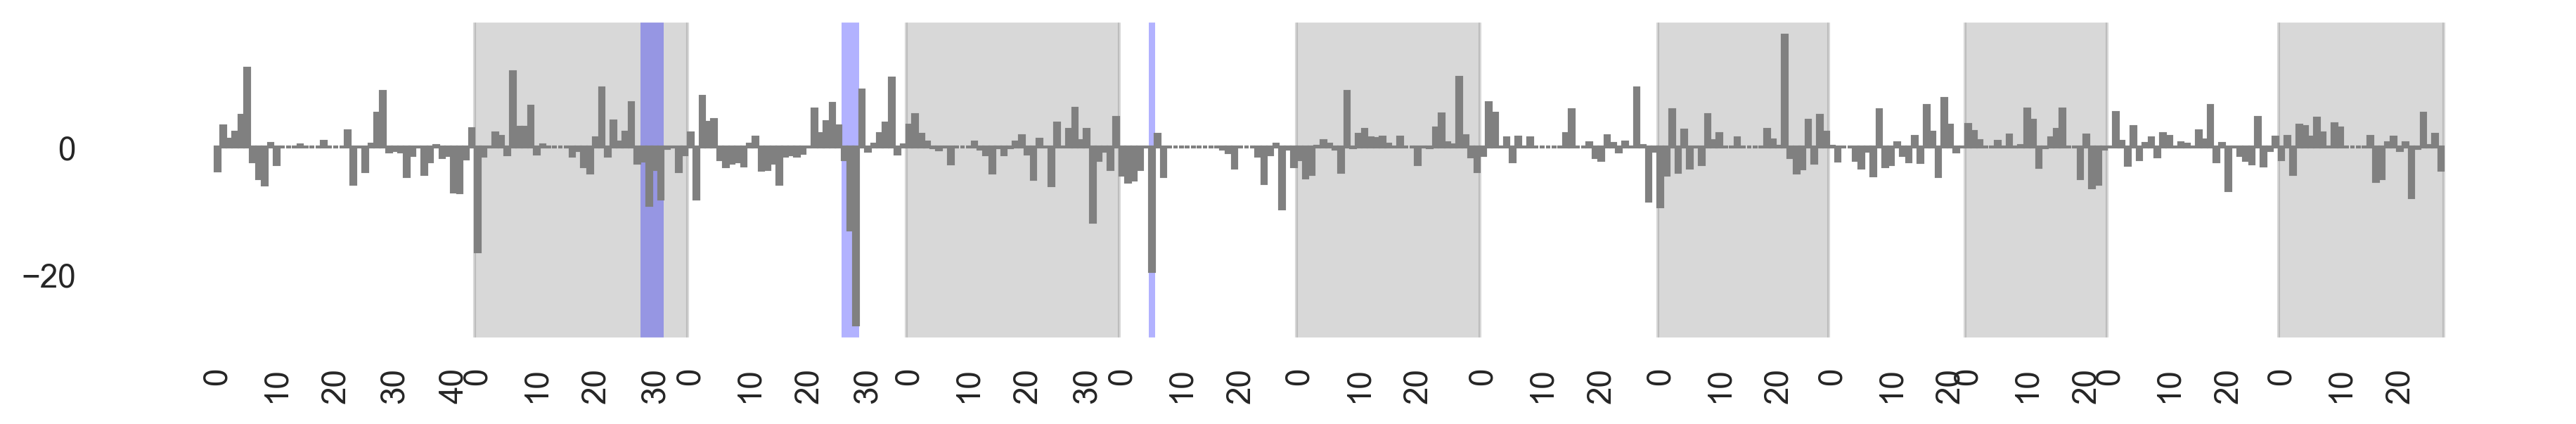

N10


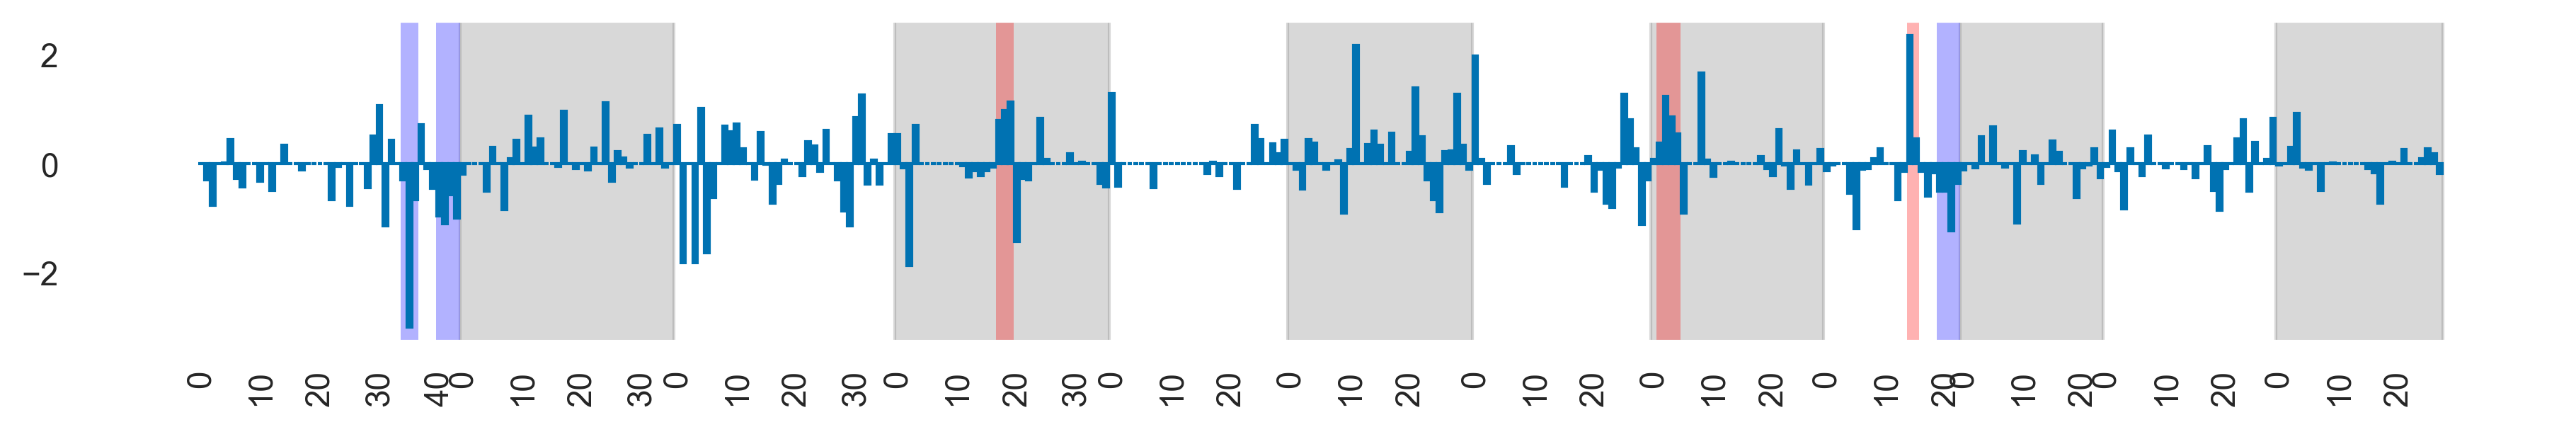

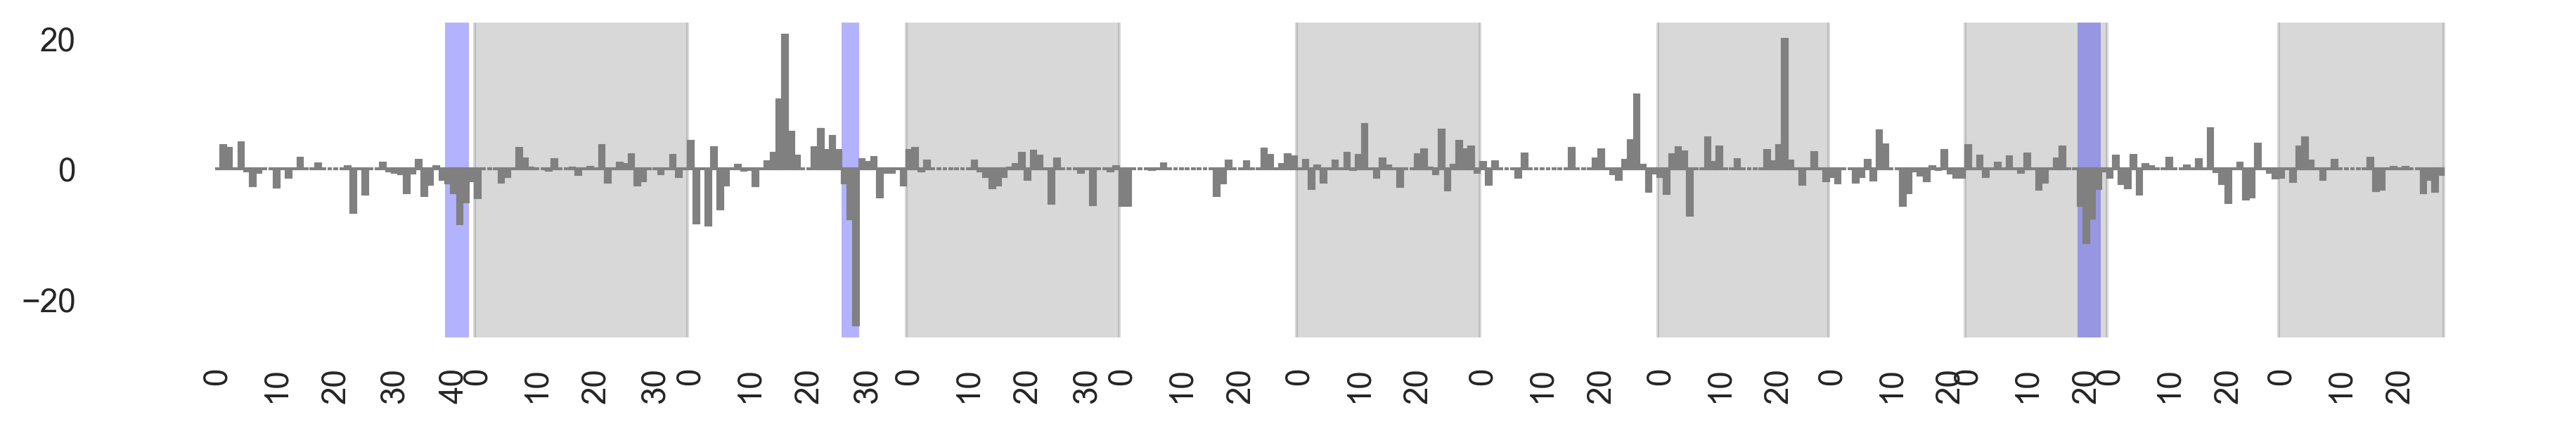

N11


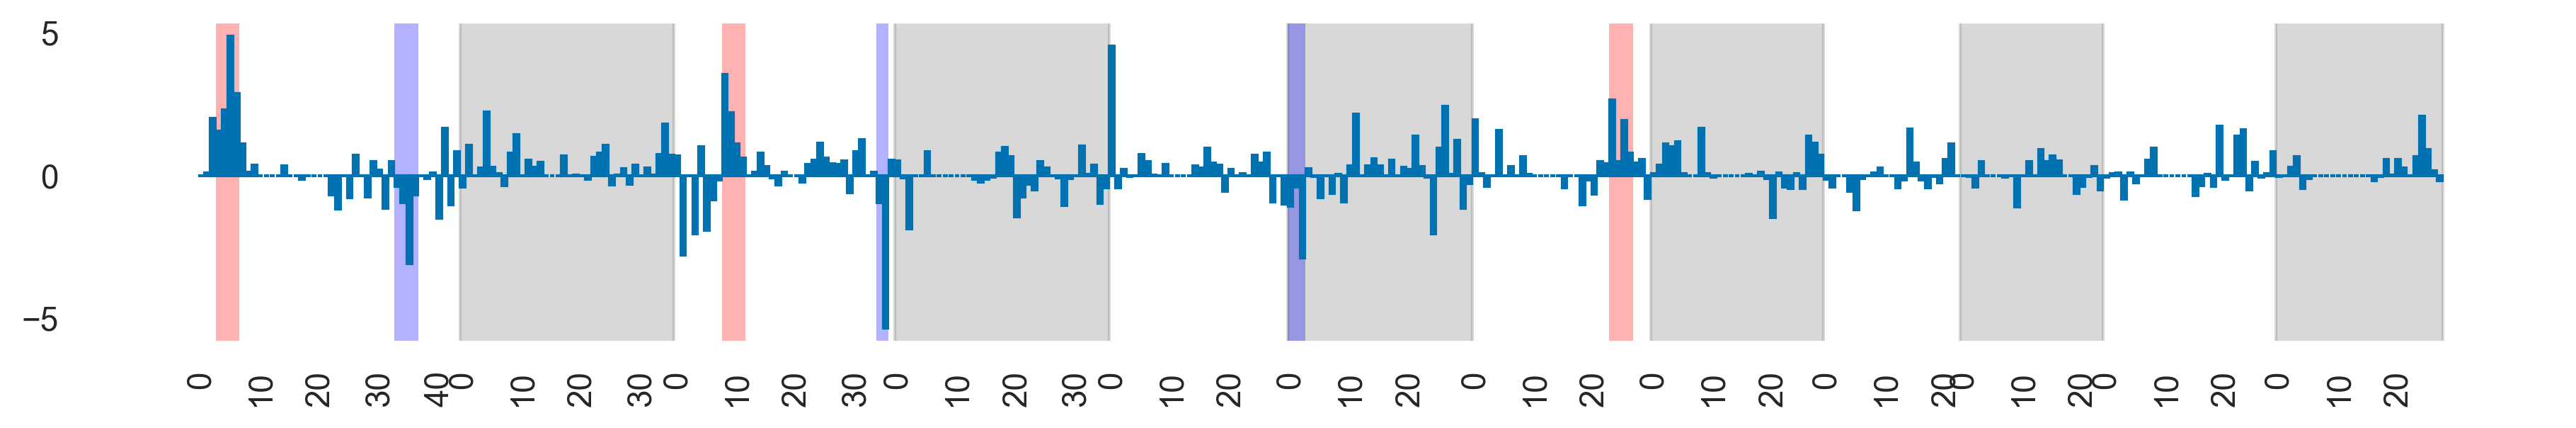

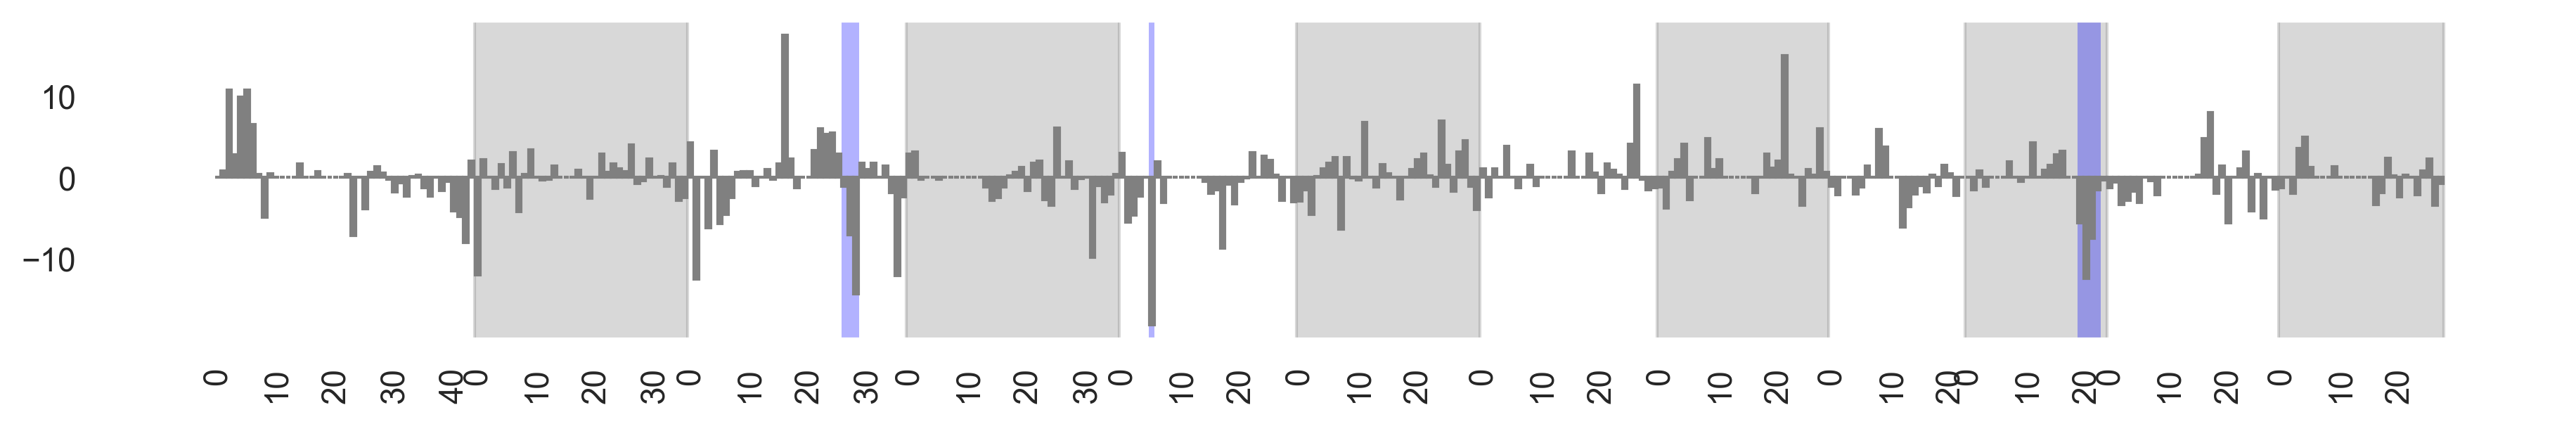

N12


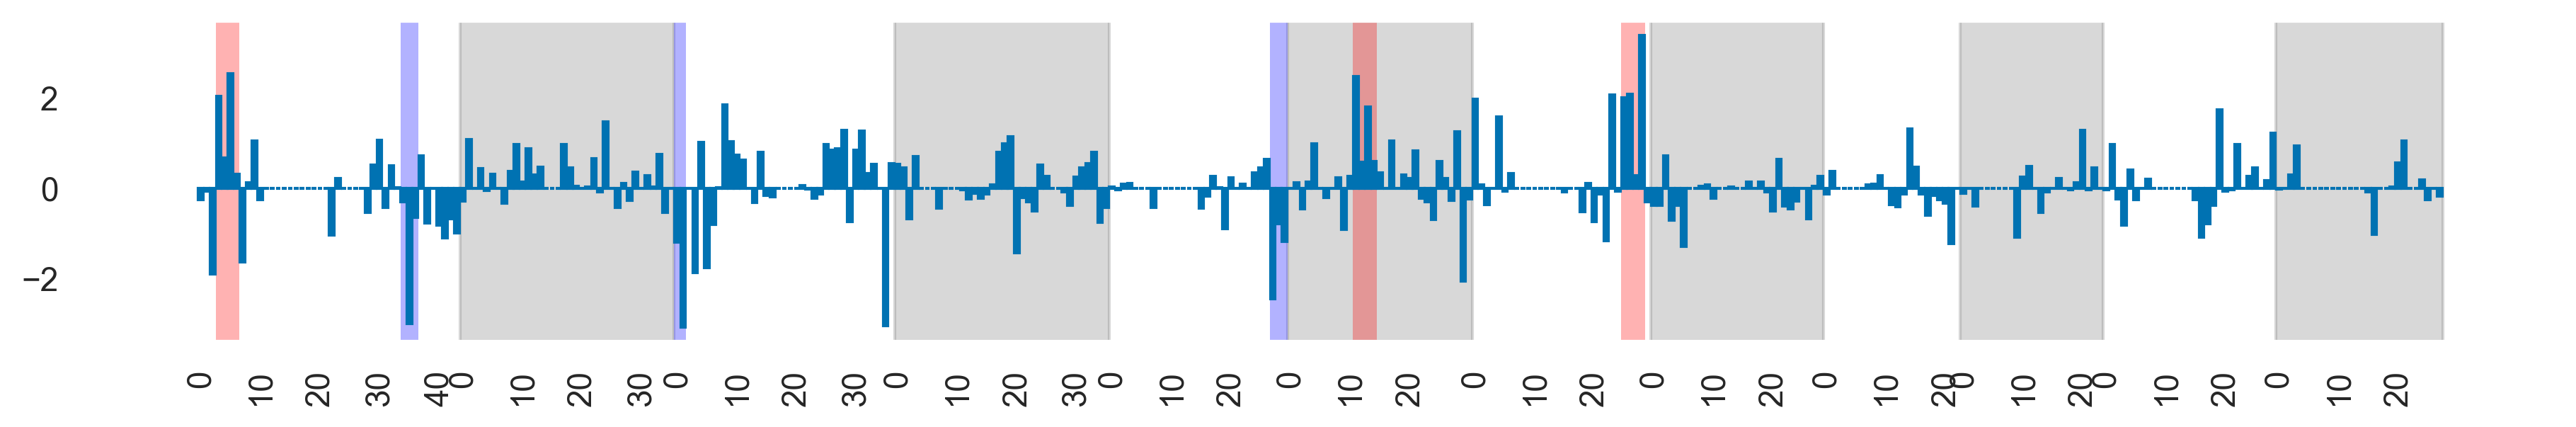

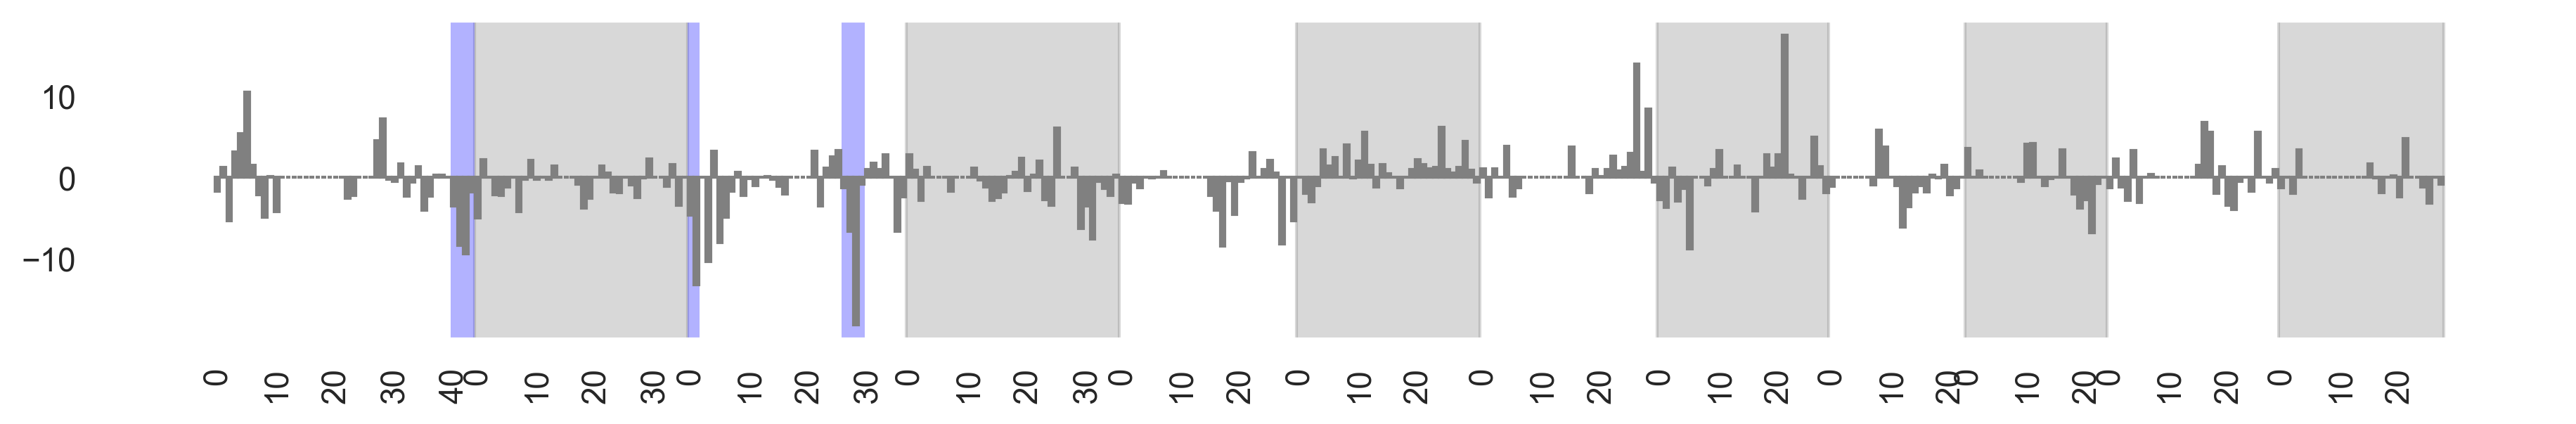

N13


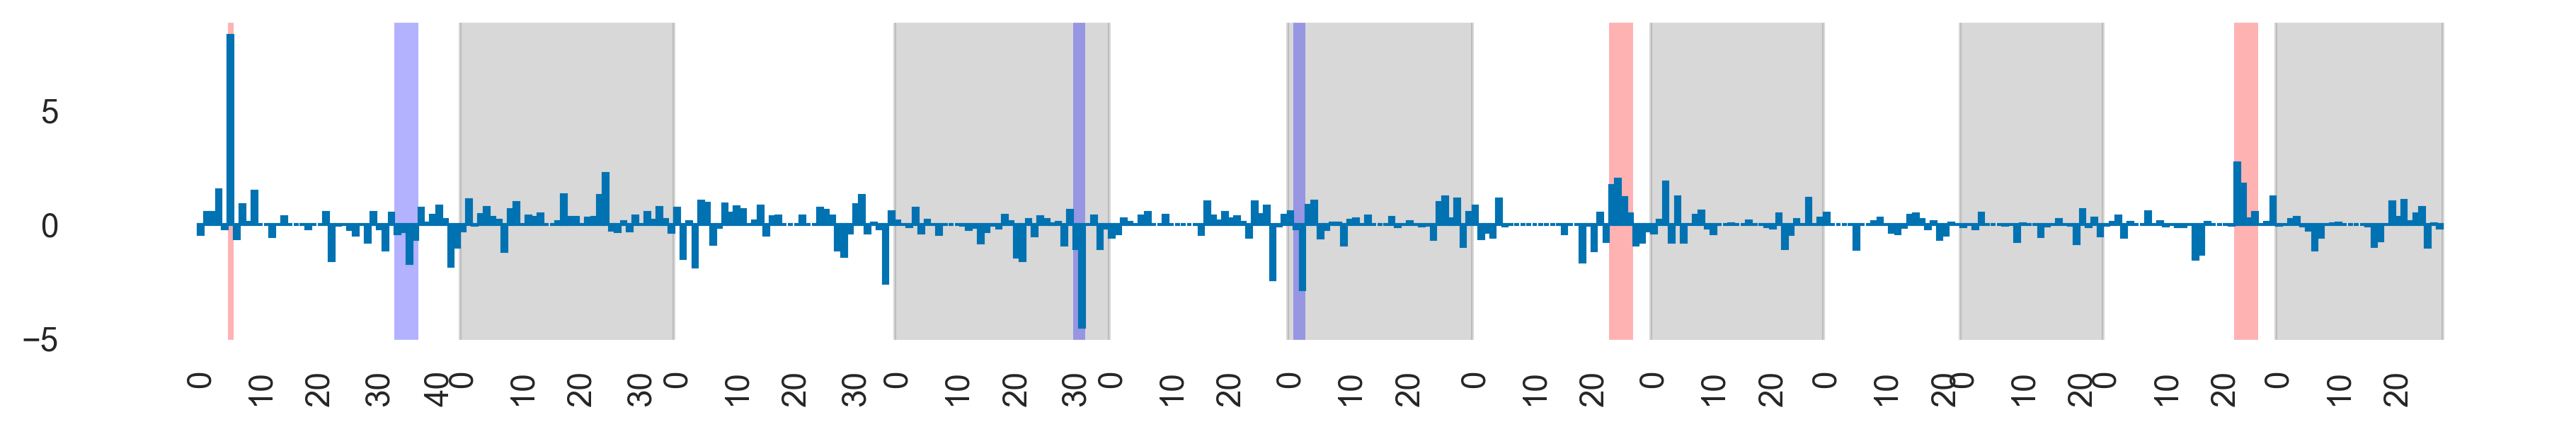

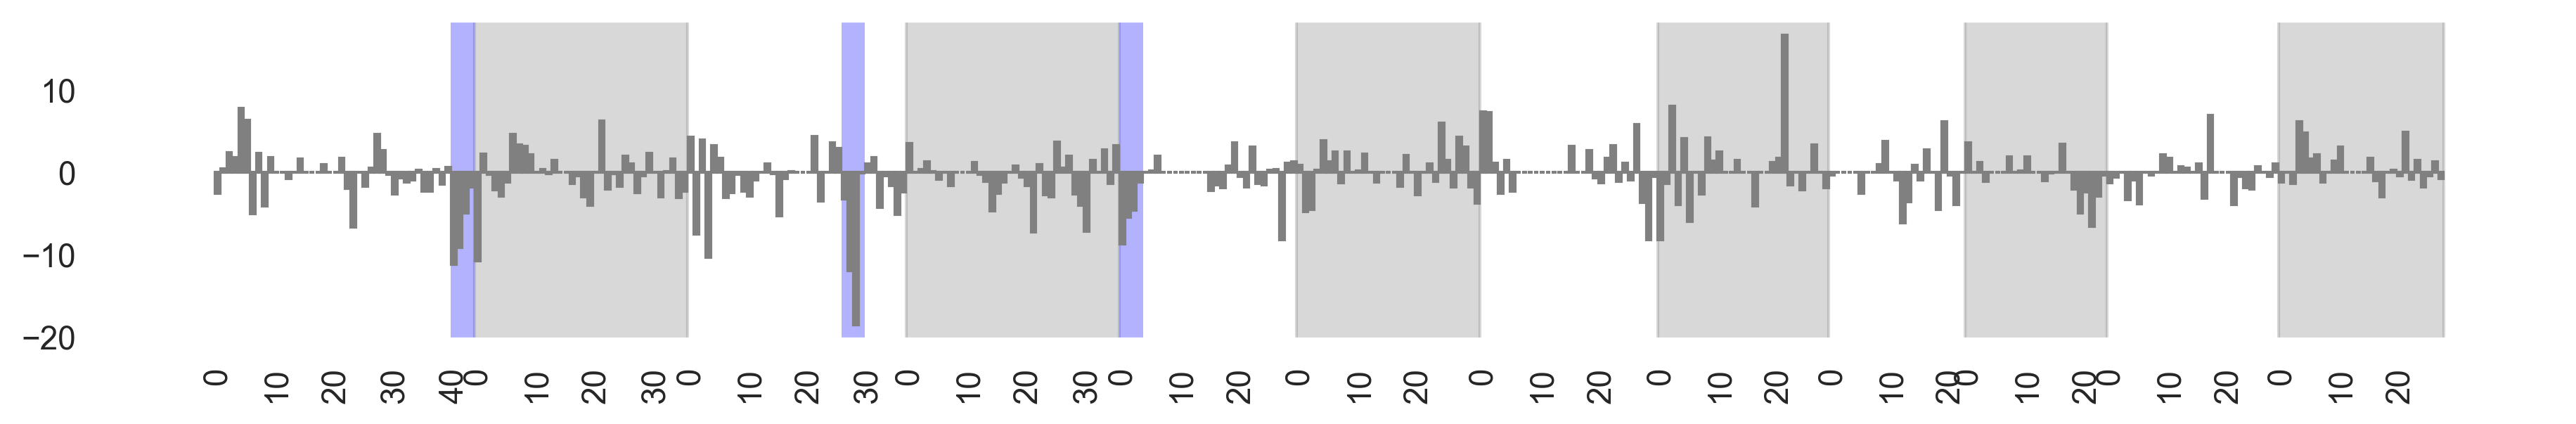

N14


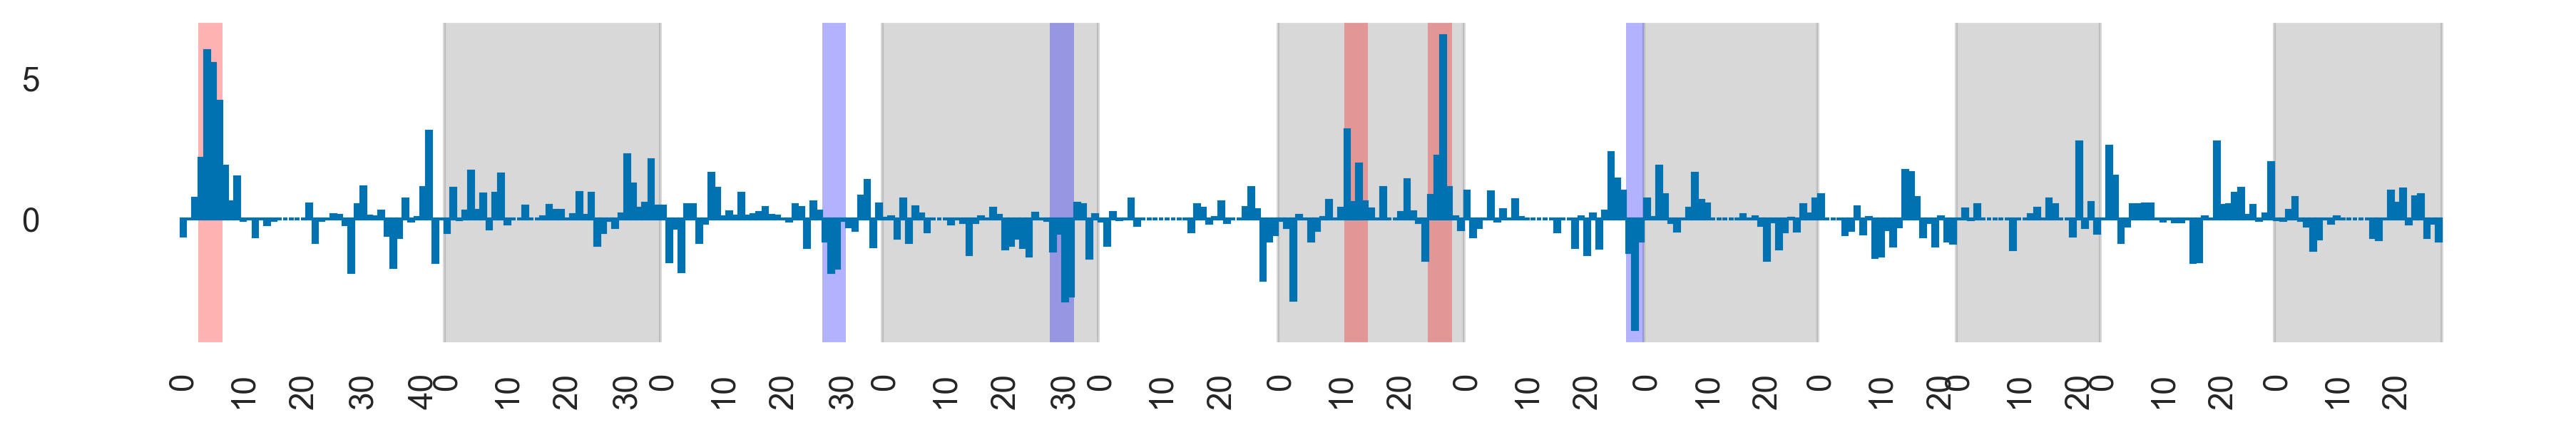

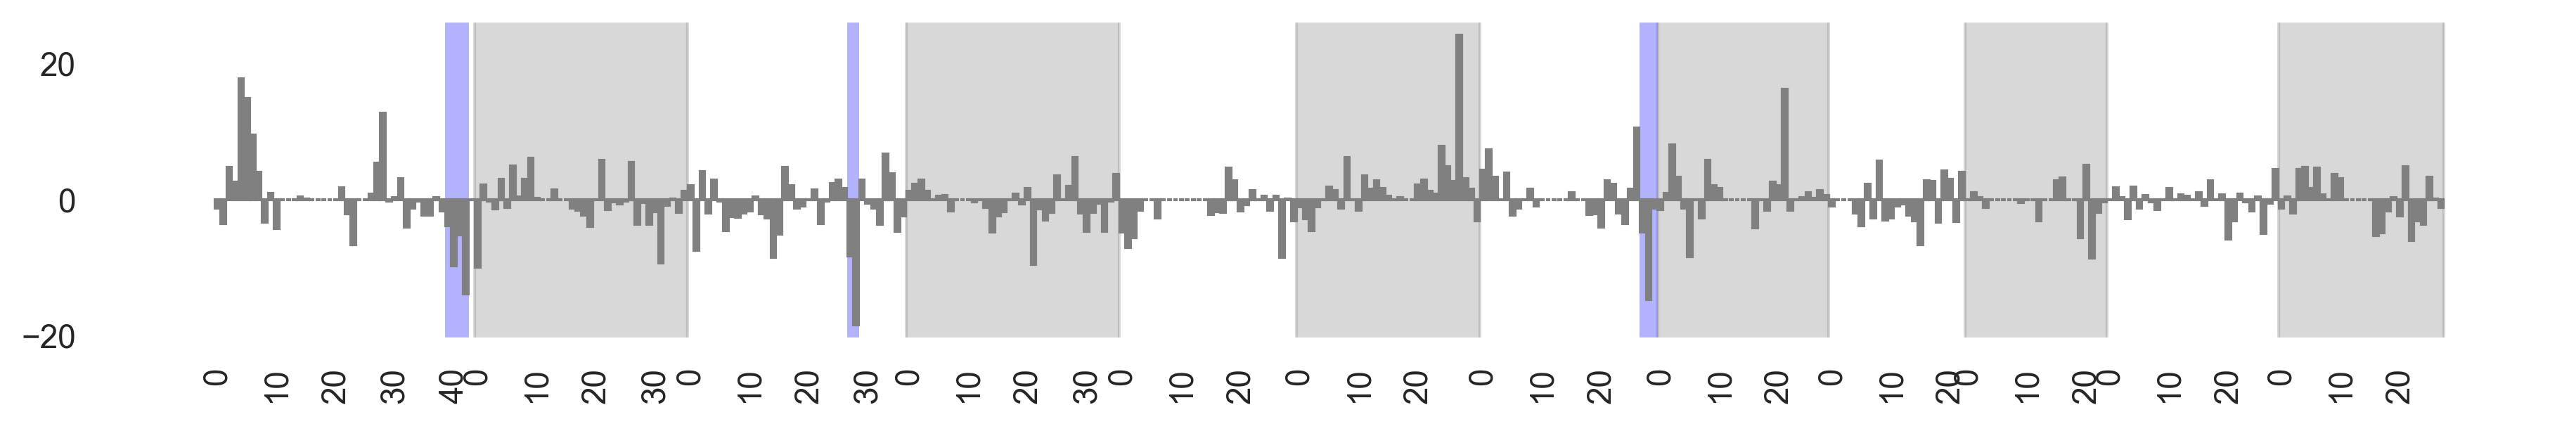

N16


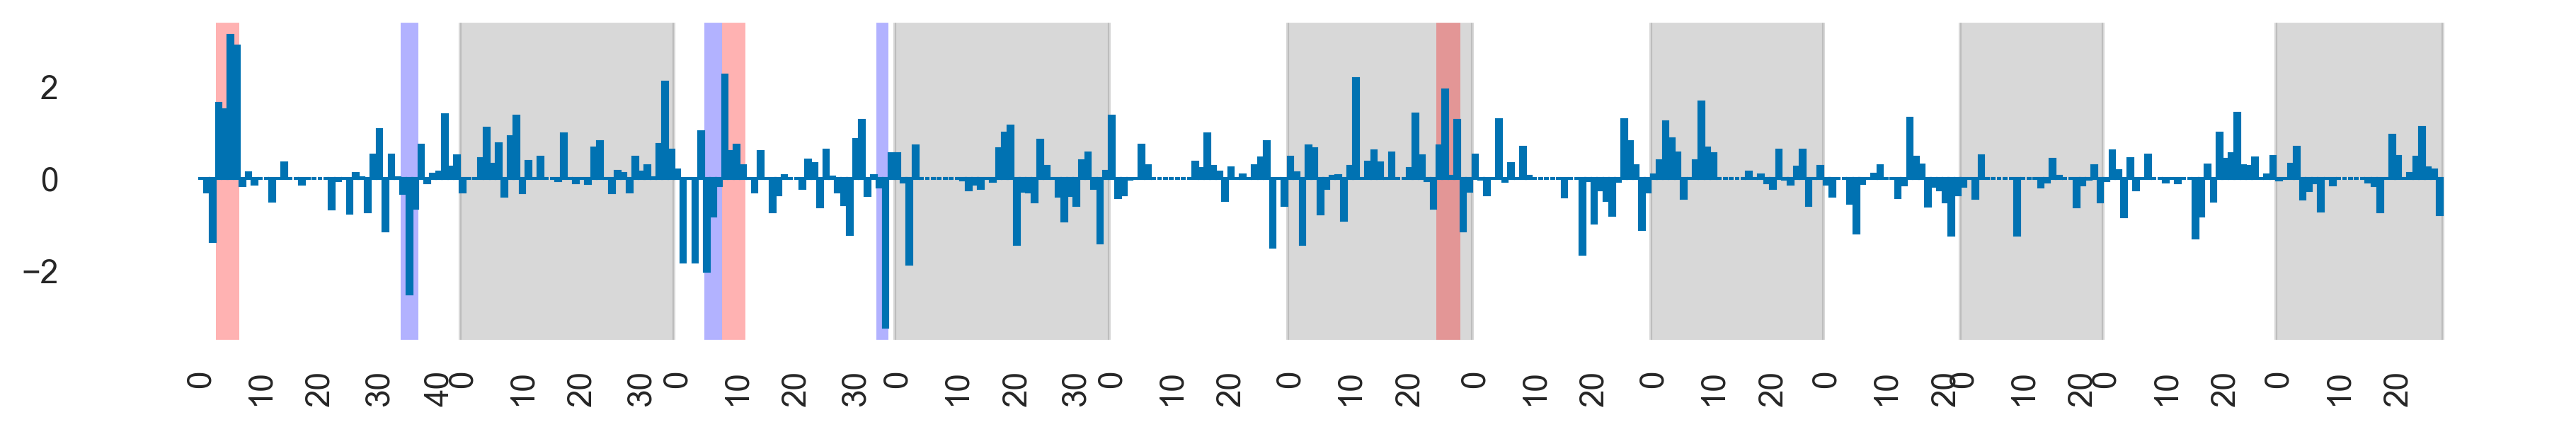

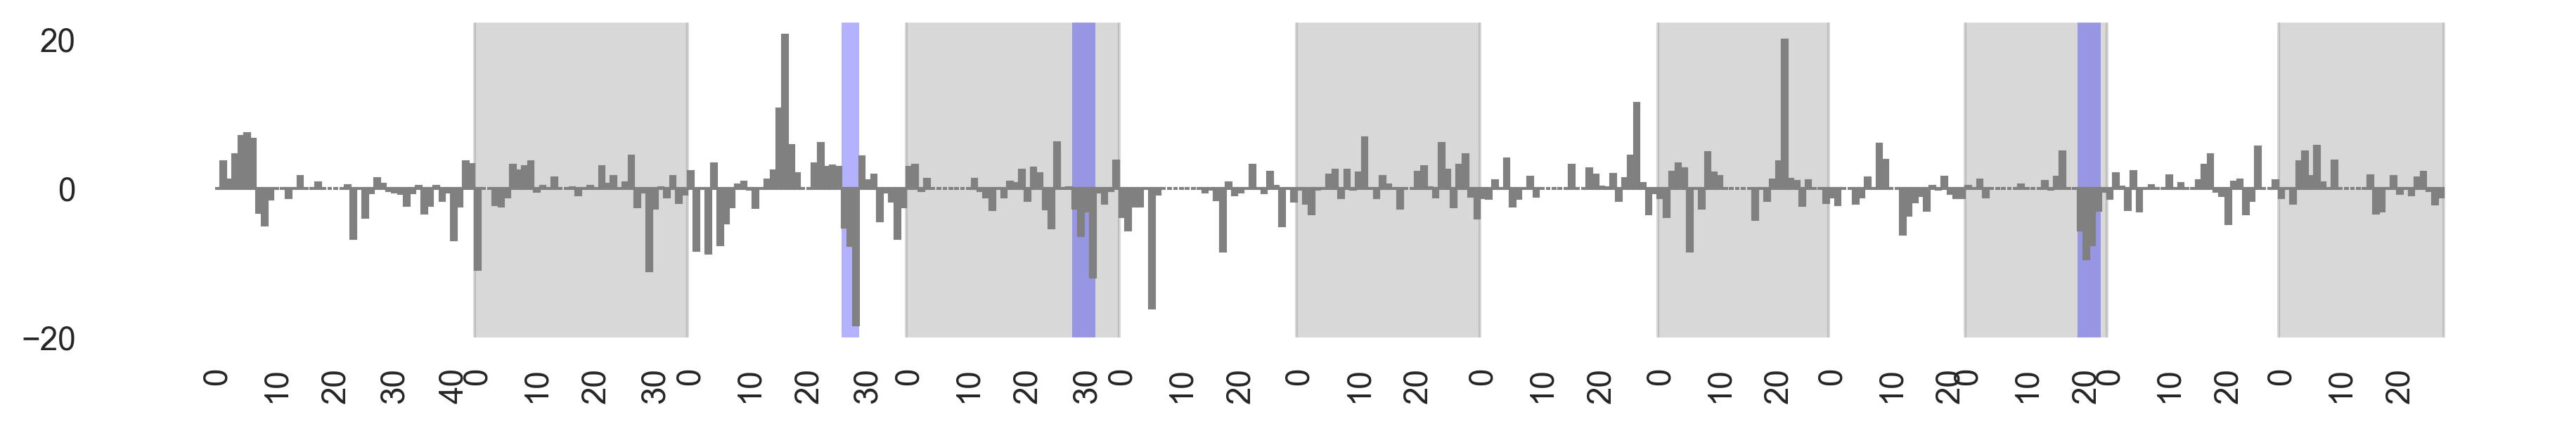

N17


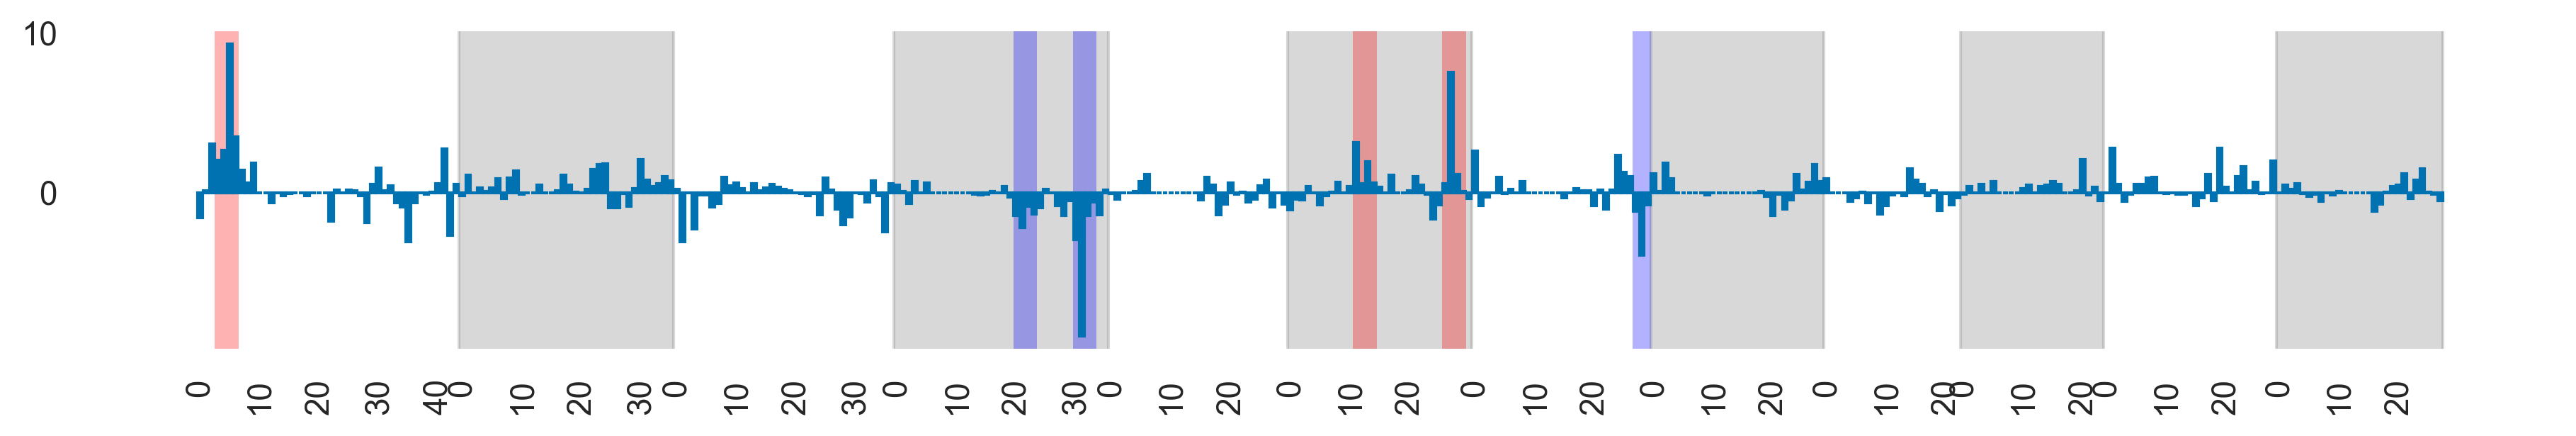

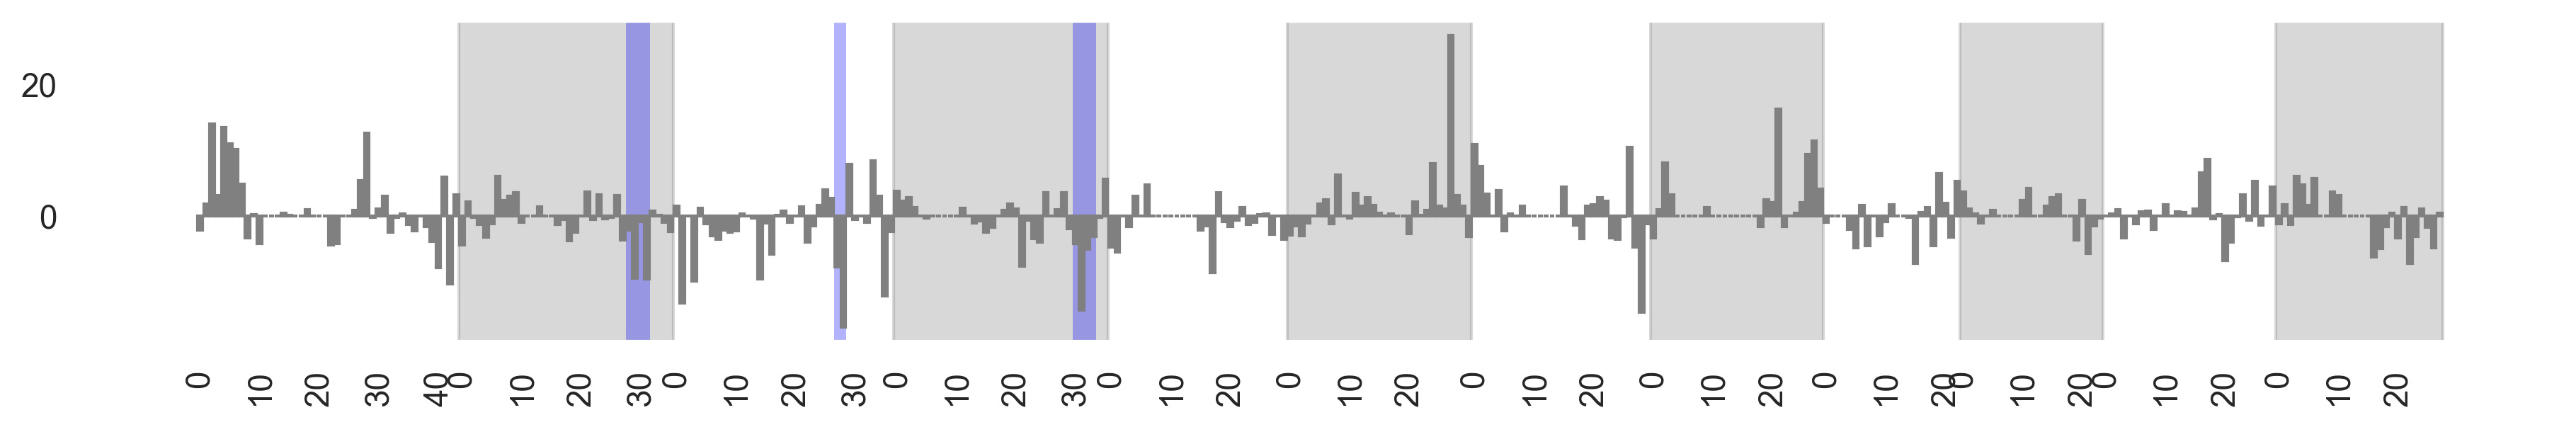

N18


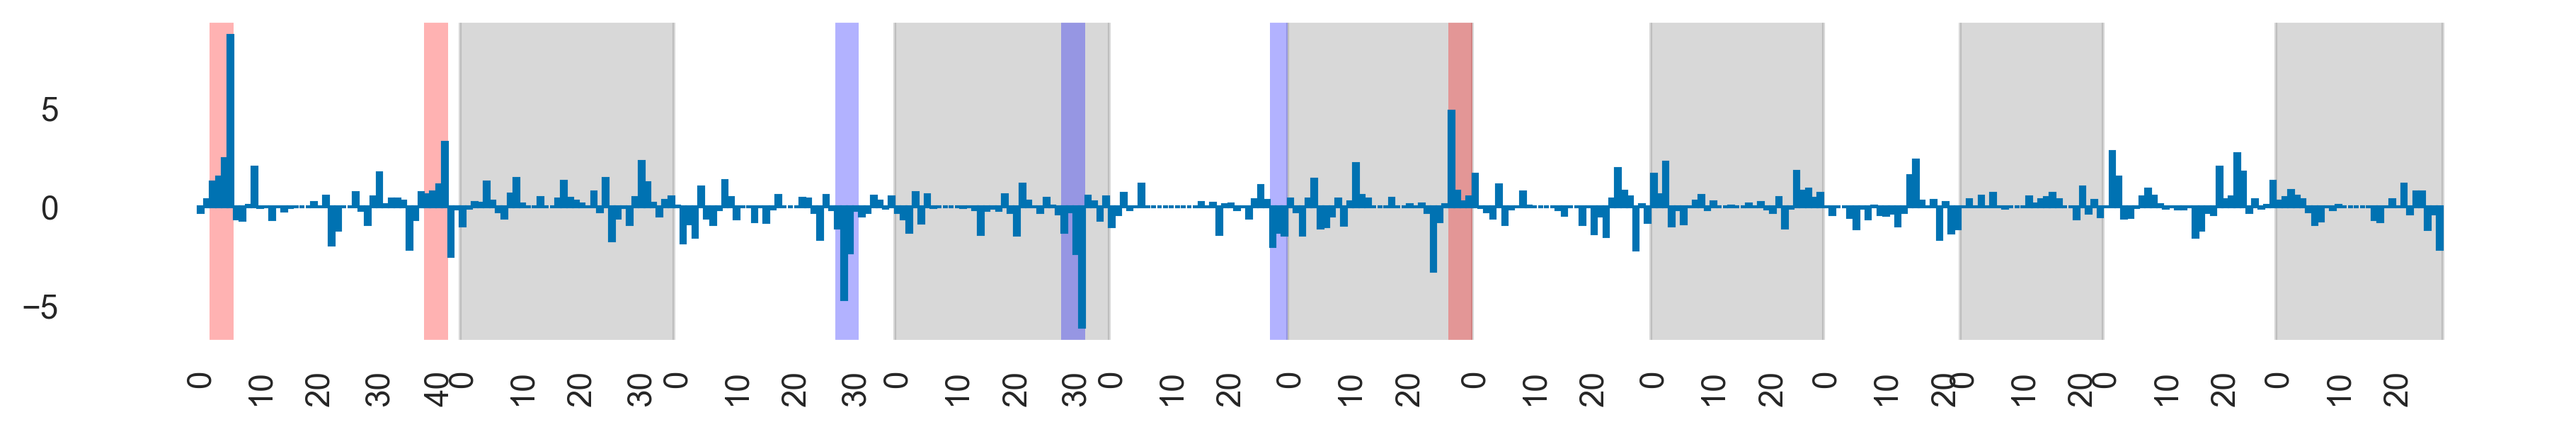

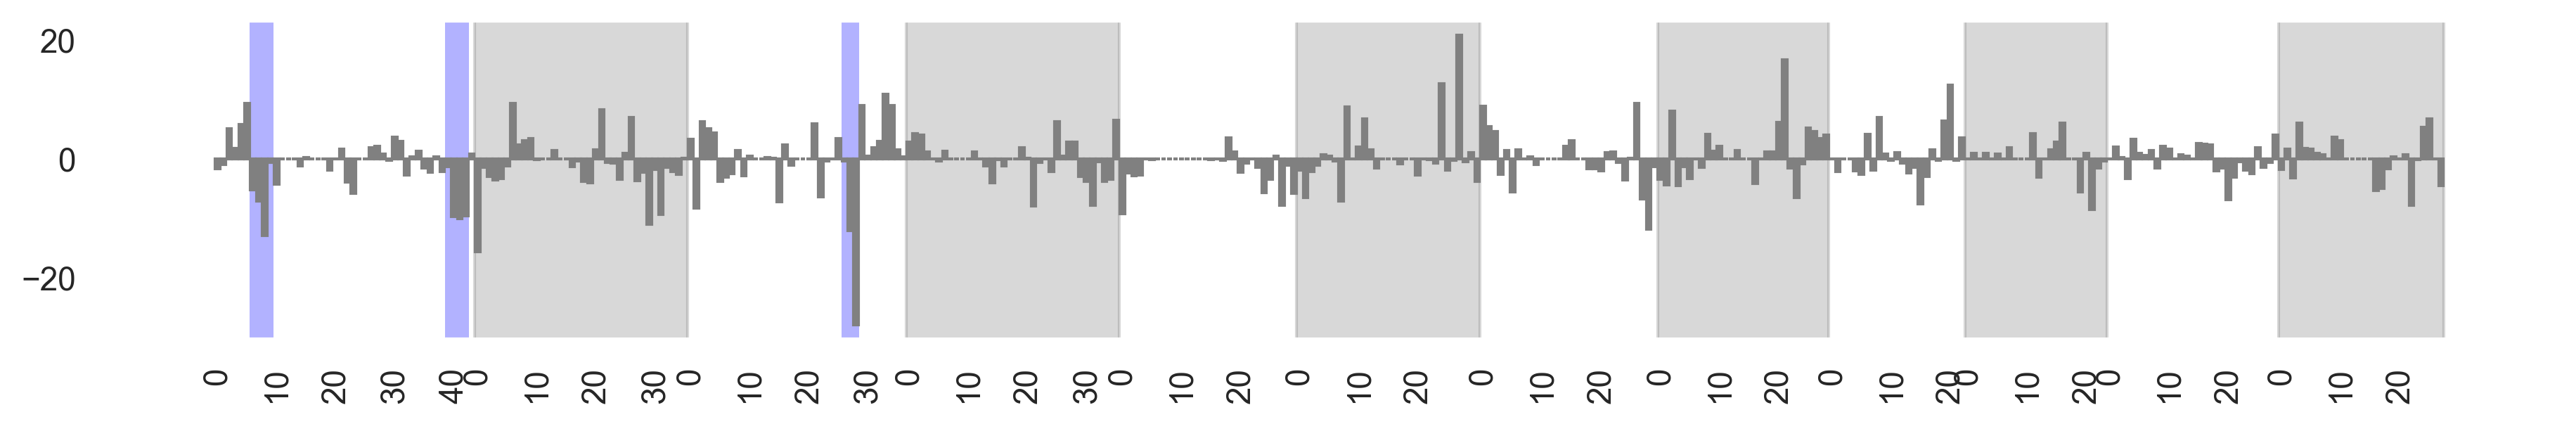

N19


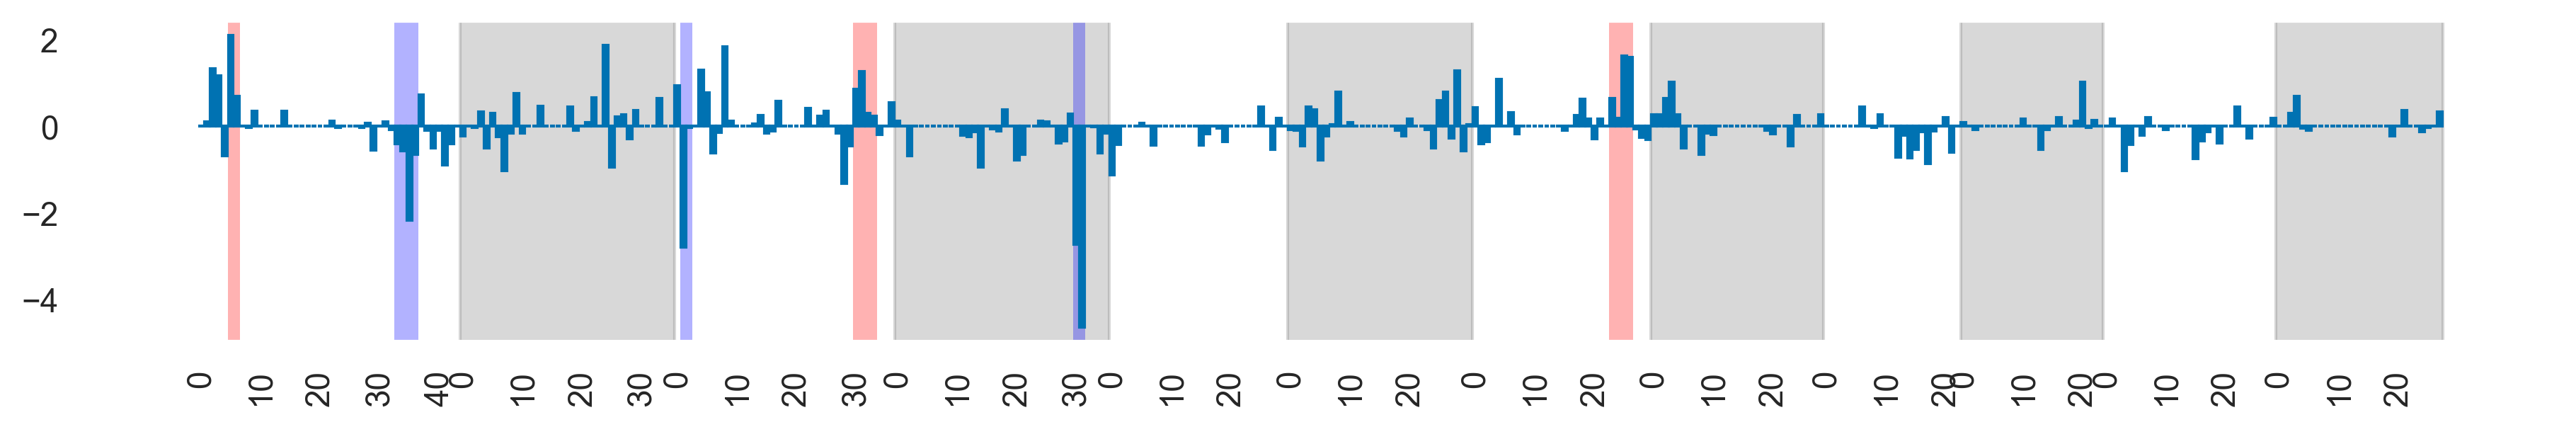

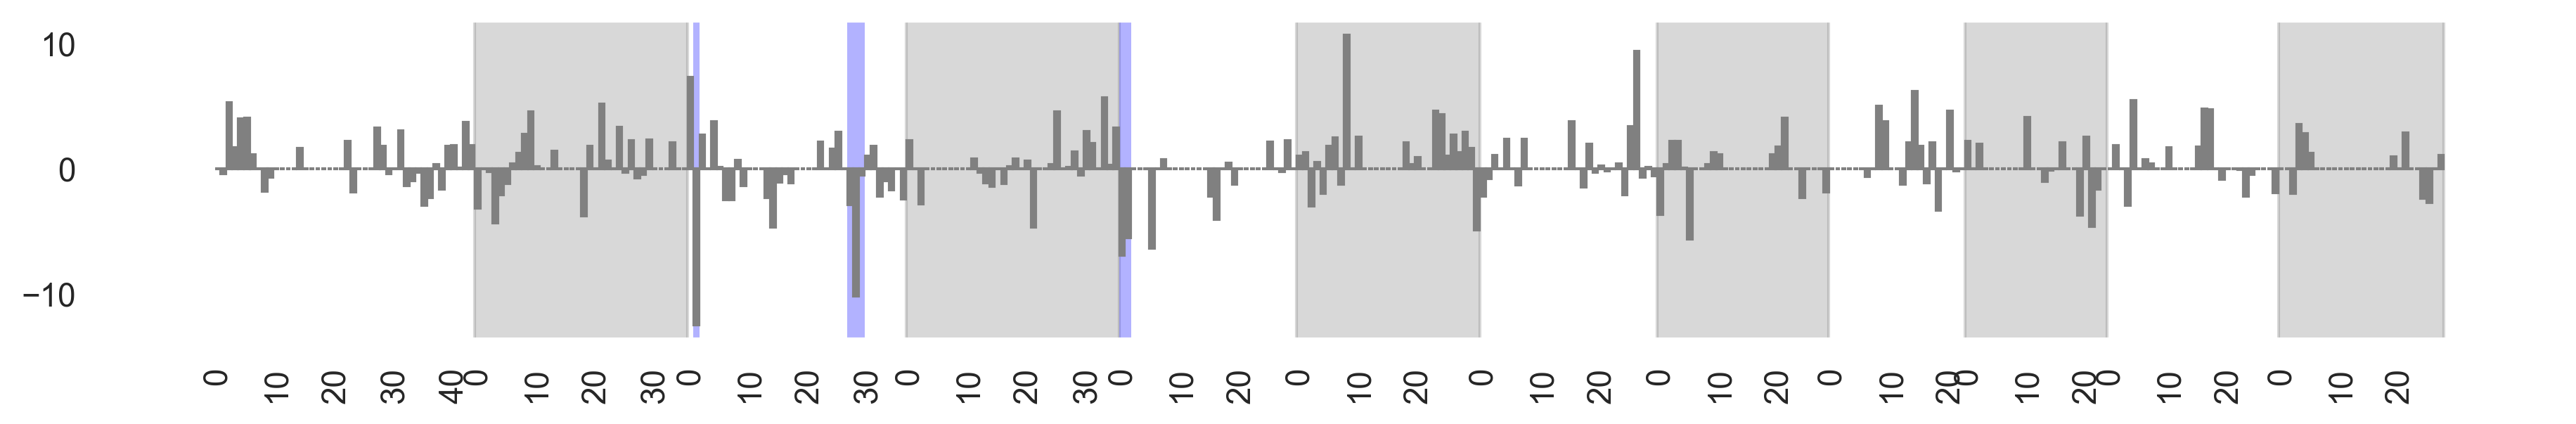

N20


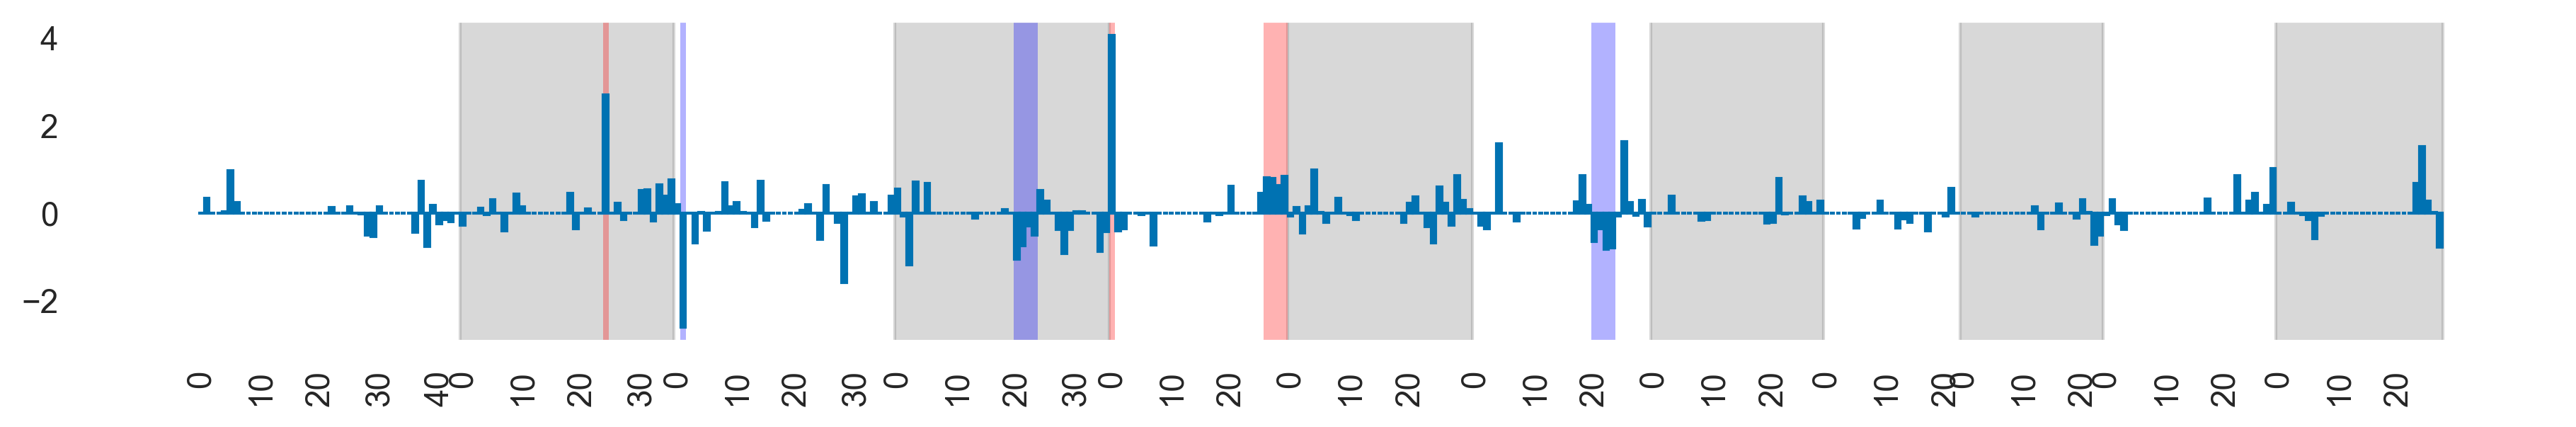

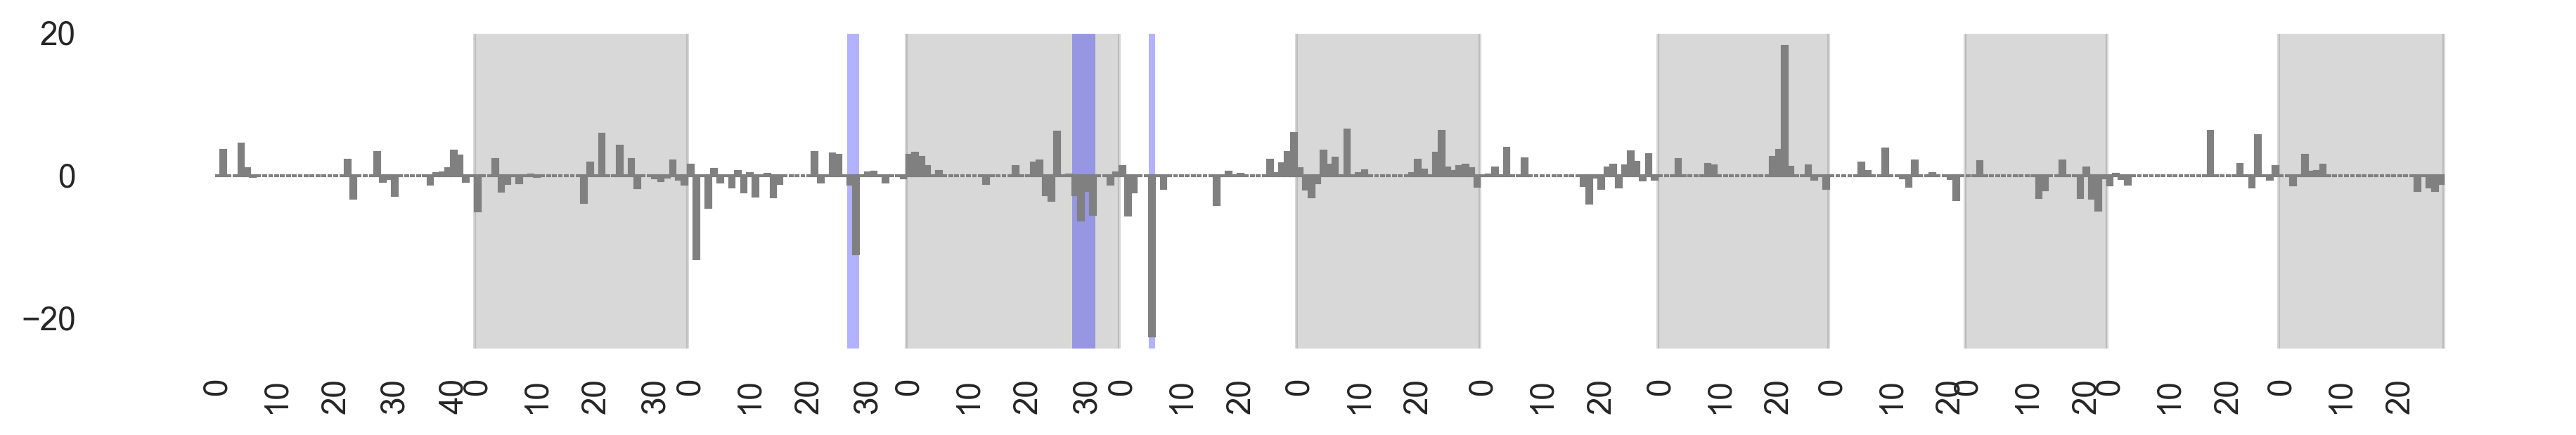

N21


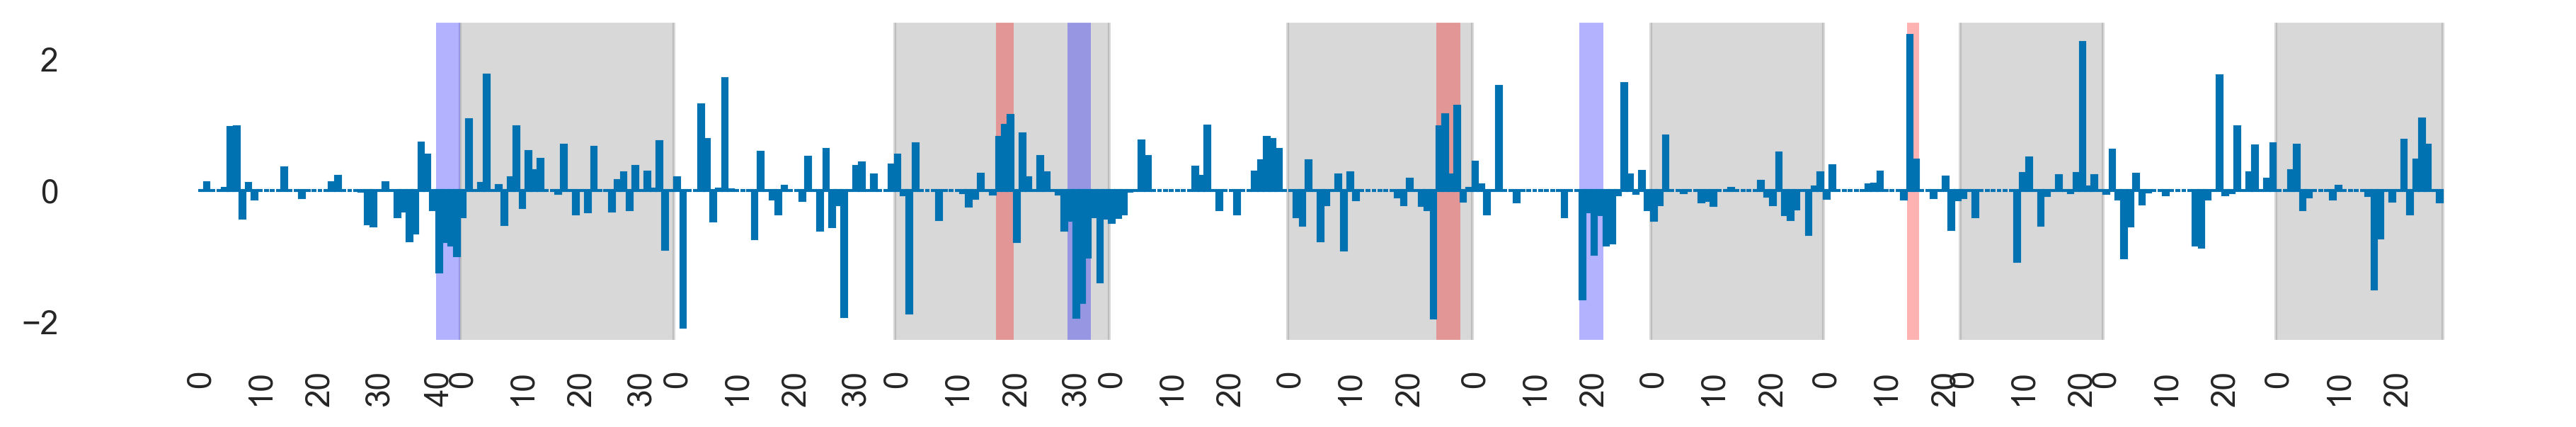

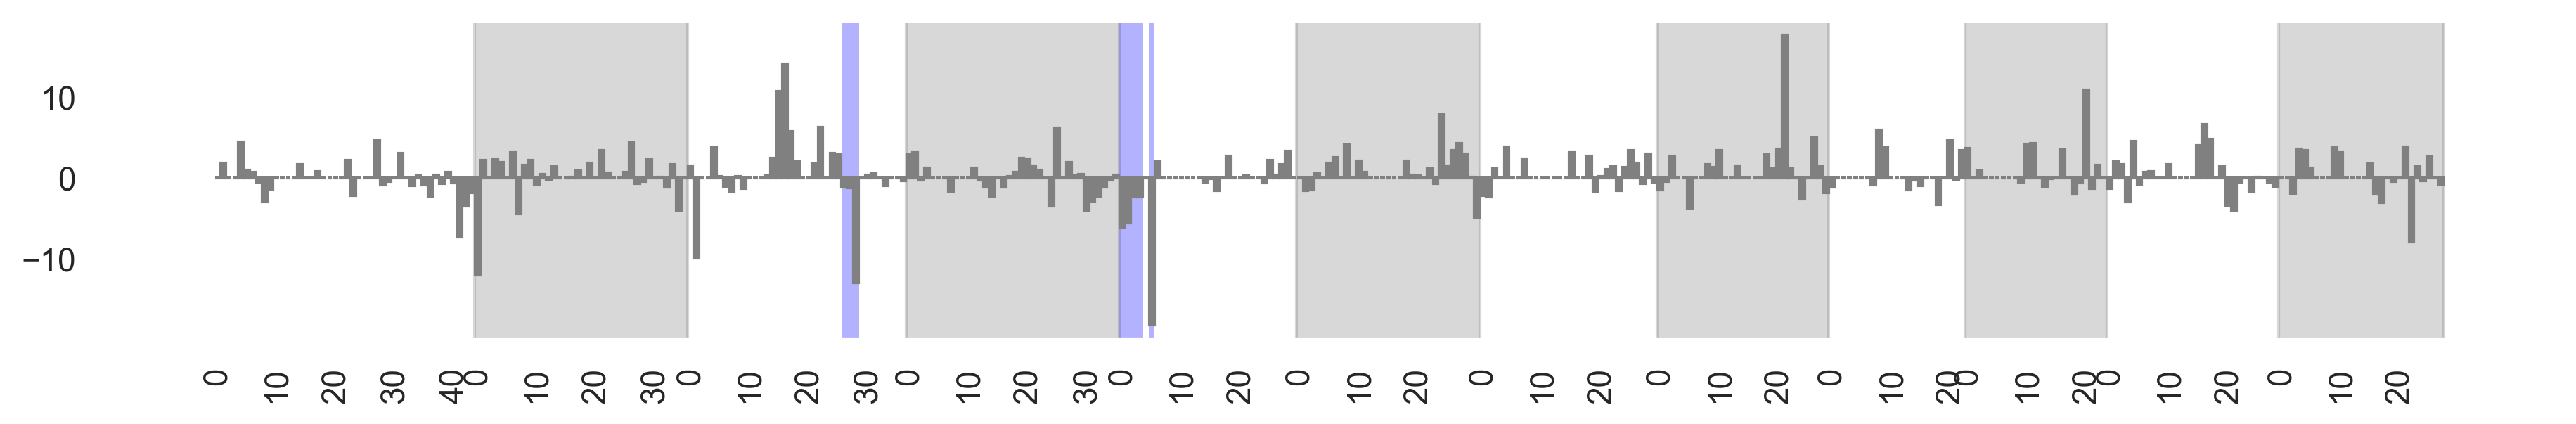

N22


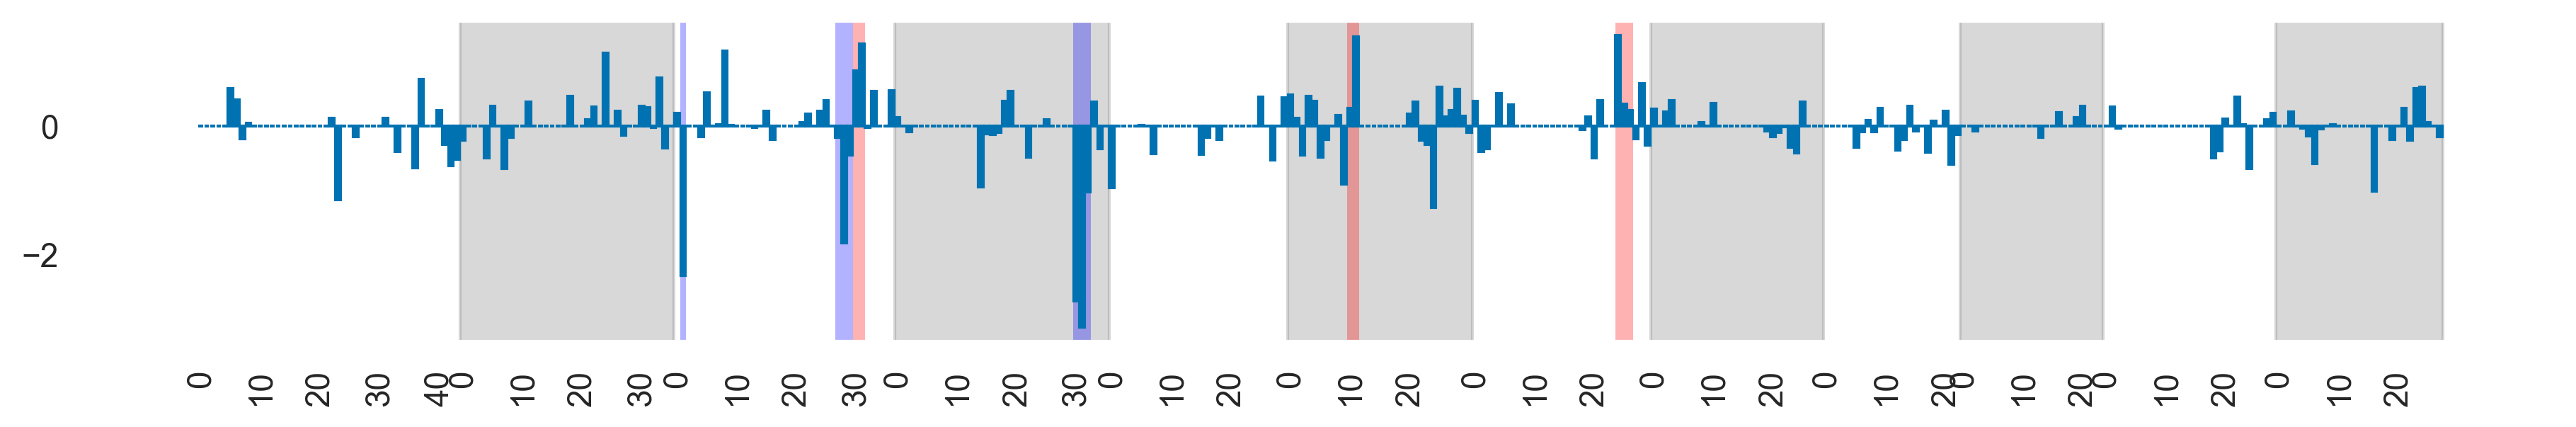

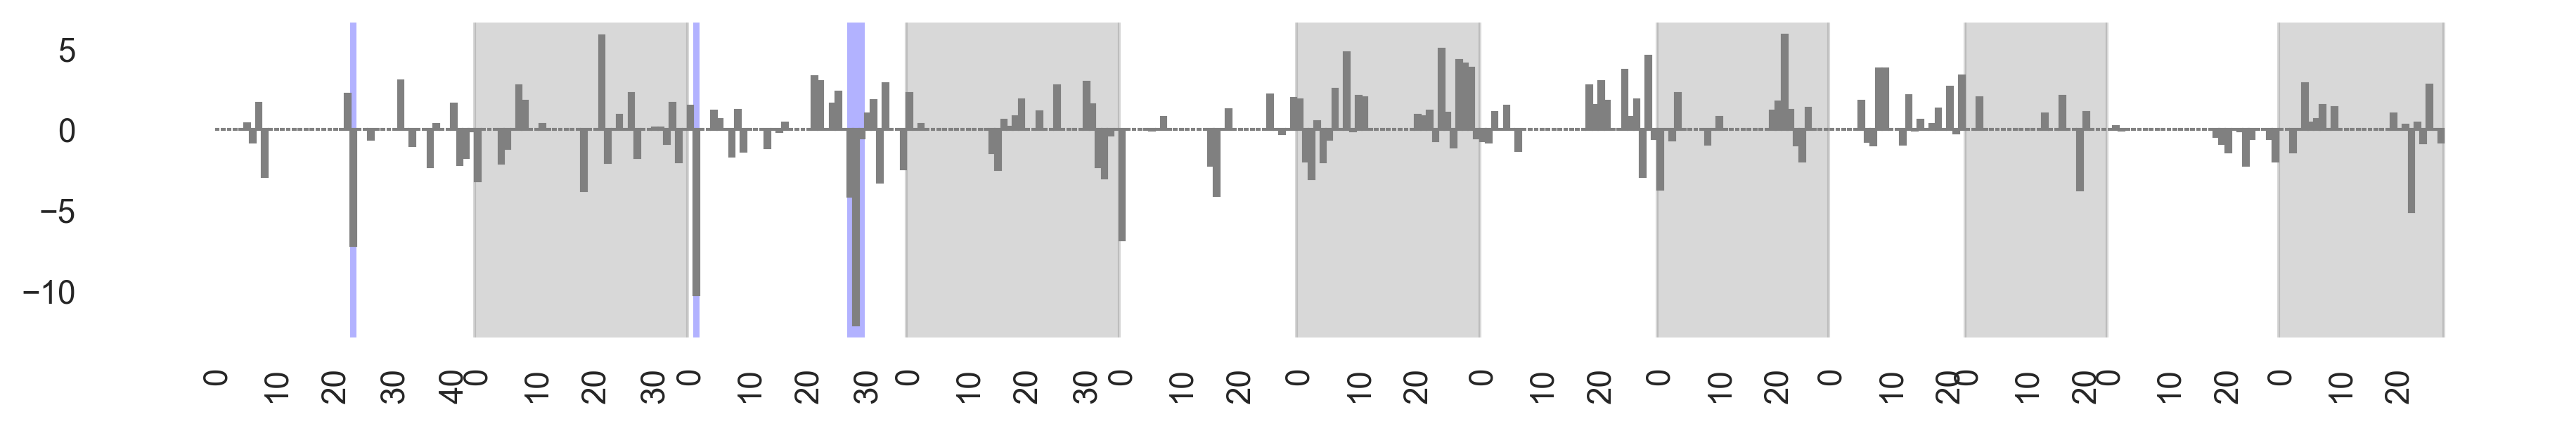

,RIL,GN_plus,GN_plus_regions,GN_plus_region_ratios,GN_minus,GN_minus_region_ratios,GN_merge,zscore_minus,zscore_minus_ratios,Hitome_per,GN_top_regions,GN_worst_regions,Total_worst_regions
159,N01_162,33.702148,3,"1.0, 0.956, 1.0",0.000000,"0, 0, 0",33.702148,0.000000,"0, 0, 0",0.678649,"chr07_25-29Mbp,chr01_2-6Mbp,chr06_25-29Mbp","chr04_30-32Mbp,chr03_27-31Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
70,N17_071,30.553871,3,"1.0, 1.0, 1.0",0.000000,"0, 0, 0",30.553871,-13.914507,"0, 0.696, 0.167",0.736586,"chr01_3-7Mbp,chr06_26-30Mbp,chr06_11-15Mbp","chr04_30-34Mbp,chr07_27-30Mbp,chr04_20-24Mbp","chr04_30-34Mbp,chr03_27-29Mbp,chr02_28-32Mbp"
78,N01_079,33.472421,3,"1.0, 0.933, 1.0",-6.677626,"0, 0, 1.0",26.794795,-0.597710,"0, 0, 0.474",0.721655,"chr07_25-29Mbp,chr01_2-6Mbp,chr06_25-29Mbp","chr04_30-32Mbp,chr03_27-31Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
14,N07_015,22.578780,2,"1.0, 1.0, 0",0.000000,"0, 0, 0",22.578780,-29.367765,"0, 0.833, 0.178",0.650565,"chr07_25-29Mbp,chr06_25-29Mbp,chr01_5-6Mbp","chr03_26-30Mbp,chr04_31-35Mbp,chr04_20-24Mbp","chr03_26-29Mbp,chr05_5-8Mbp,chr01_39-43Mbp"
81,N17_082,22.218251,2,"0.981, 0.818, 0",0.000000,"0, 0, 0",22.218251,0.000000,"0, 0, 0",0.782022,"chr01_3-7Mbp,chr06_26-30Mbp,chr06_11-15Mbp","chr04_30-34Mbp,chr07_27-30Mbp,chr04_20-24Mbp","chr04_30-34Mbp,chr03_27-29Mbp,chr02_28-32Mbp"
63,N03_066,25.853265,3,"0.981, 0.241, 0.926",-4.360569,"0, 0.76, 0.067",21.492696,-14.158021,"0.044, 0, 0.55",0.674250,"chr01_3-7Mbp,chr06_25-29Mbp,chr07_23-27Mbp","chr04_28-32Mbp,chr11_15-19Mbp,chr03_26-30Mbp","chr01_39-43Mbp,chr03_27-29Mbp,chr05_0-4Mbp"
49,N07_050,21.538673,2,"0.938, 0.774, 0",-1.927357,"0, 0, 0.381",19.611316,-0.795294,"0, 0.083, 0",0.817098,"chr07_25-29Mbp,chr06_25-29Mbp,chr01_5-6Mbp","chr03_26-30Mbp,chr04_31-35Mbp,chr04_20-24Mbp","chr03_26-29Mbp,chr05_5-8Mbp,chr01_39-43Mbp"
38,N03_041,19.029217,2,"0.981, 0.207, 0",0.000000,"0, 0, 0",19.029217,-38.607605,"0.511, 0, 0.7",0.848042,"chr01_3-7Mbp,chr06_25-29Mbp,chr07_23-27Mbp","chr04_28-32Mbp,chr11_15-19Mbp,chr03_26-30Mbp","chr01_39-43Mbp,chr03_27-29Mbp,chr05_0-4Mbp"
43,N06_044,24.112255,3,"1.0, 1.0, 0.688",-5.150214,"0, 0.826, 0.4",18.962041,-26.479667,"0, 0, 1.0",0.668060,"chr07_25-29Mbp,chr06_27-29Mbp,chr11_19-23Mbp","chr03_26-30Mbp,chr05_27-30Mbp,chr11_15-19Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr10_19-23Mbp"
64,N18_065,19.895320,2,"1.0, 0.938, 0",-1.581952,"0.106, 0, 0",18.313367,-18.715358,"0, 0, 0.868",0.747712,"chr01_2-6Mbp,chr06_27-31Mbp,chr01_38-42Mbp","chr04_28-32Mbp,chr03_27-31Mbp,chr05_27-30Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr01_6-10Mbp"


In [27]:
genotype_path = "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv"
Hitome_per_path = "../data/PART0_NAM_stats/Percentage_Hitomebore_genotype.csv"

GN_top_regions_effect_summary = pd.DataFrame()
for pop in [i[:3] for i in family]:
    print(pop)
    regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
    GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
    GN_worst_regions = get_top_regions(regional_info_all, "GN_imps", "worst", 3)
    Total_worst_regions = get_top_regions(regional_info_all, "sum_zscore", "worst", 3)
    plot_regional_info_with_target(regional_info_all, "GN_imps", "#0072B2", GN_top_regions, GN_worst_regions)
    plot_regional_info_with_target(regional_info_all, "sum_zscore", "gray", [], Total_worst_regions)
    each_effect_summary = target_effect_summary(imp_data, genotype_path, Hitome_per_path, pop, "GN", GN_top_regions, GN_worst_regions, Total_worst_regions)
    each_effect_summary["GN_top_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in GN_top_regions])
    each_effect_summary["GN_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in GN_worst_regions])
    each_effect_summary["Total_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in Total_worst_regions])
    GN_top_regions_effect_summary = pd.concat([GN_top_regions_effect_summary, each_effect_summary])
GN_top_regions_effect_summary.to_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Select_RILs_for_GN_stats.csv")
display(GN_top_regions_effect_summary[GN_top_regions_effect_summary.Hitome_per > 0.65].sort_values(by="GN_merge", ascending=False).iloc[:10, :])

## Check genetic effect on PN for each candidate RIL populations

N01


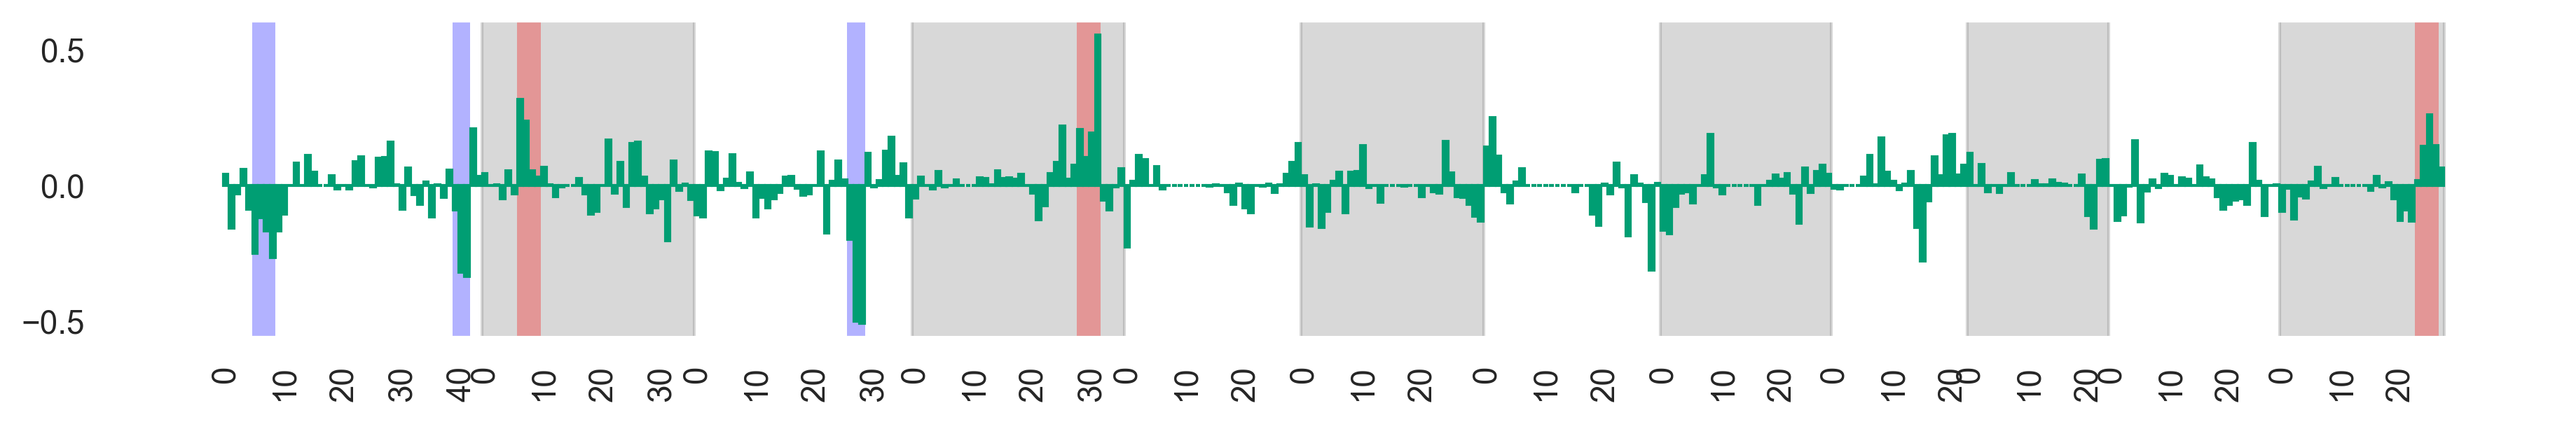

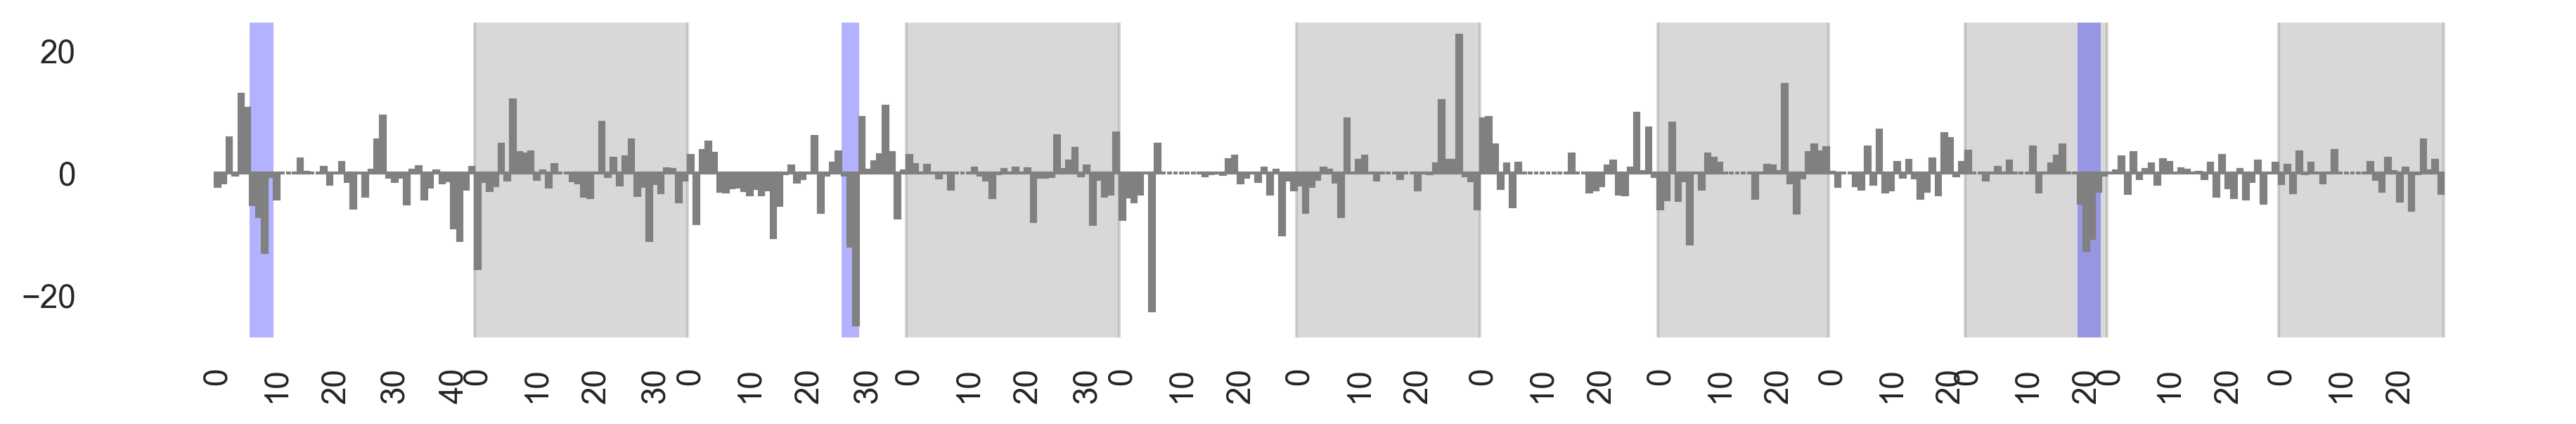

N03


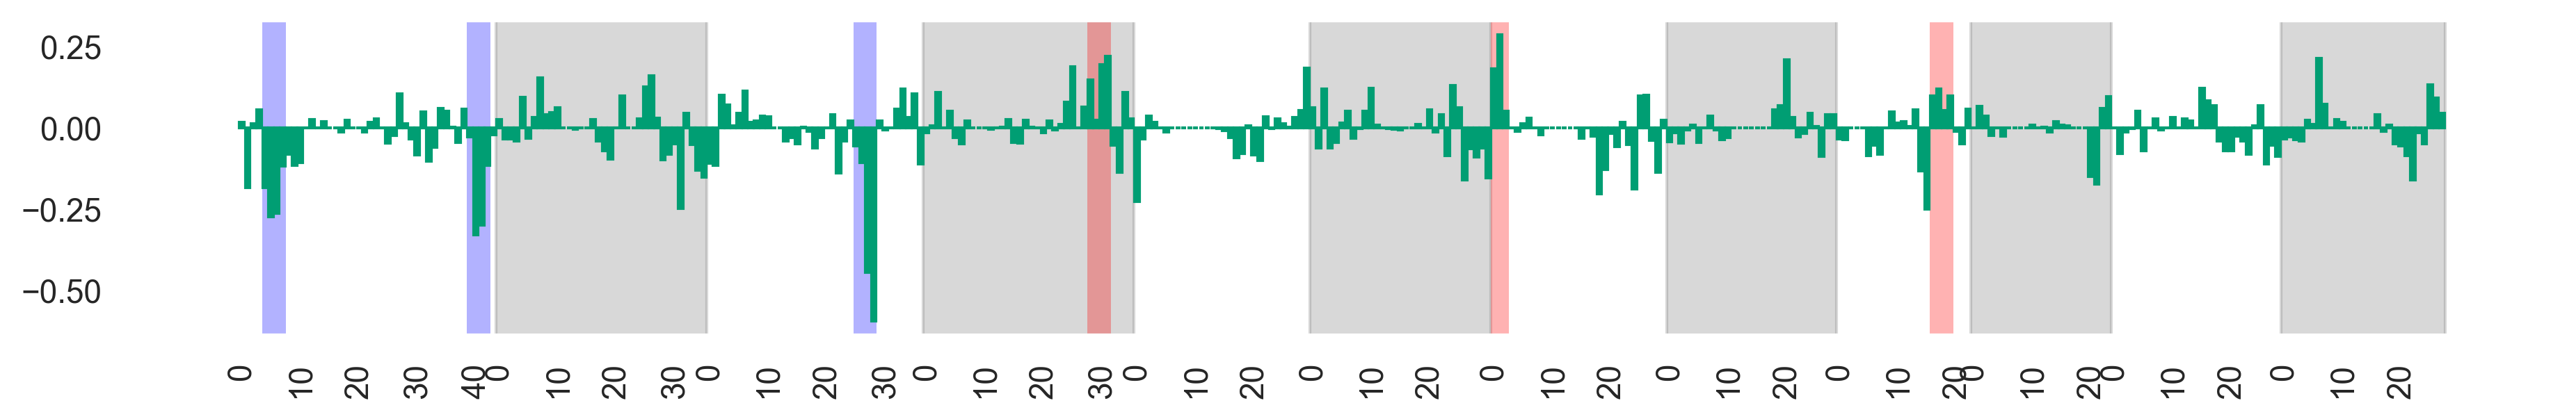

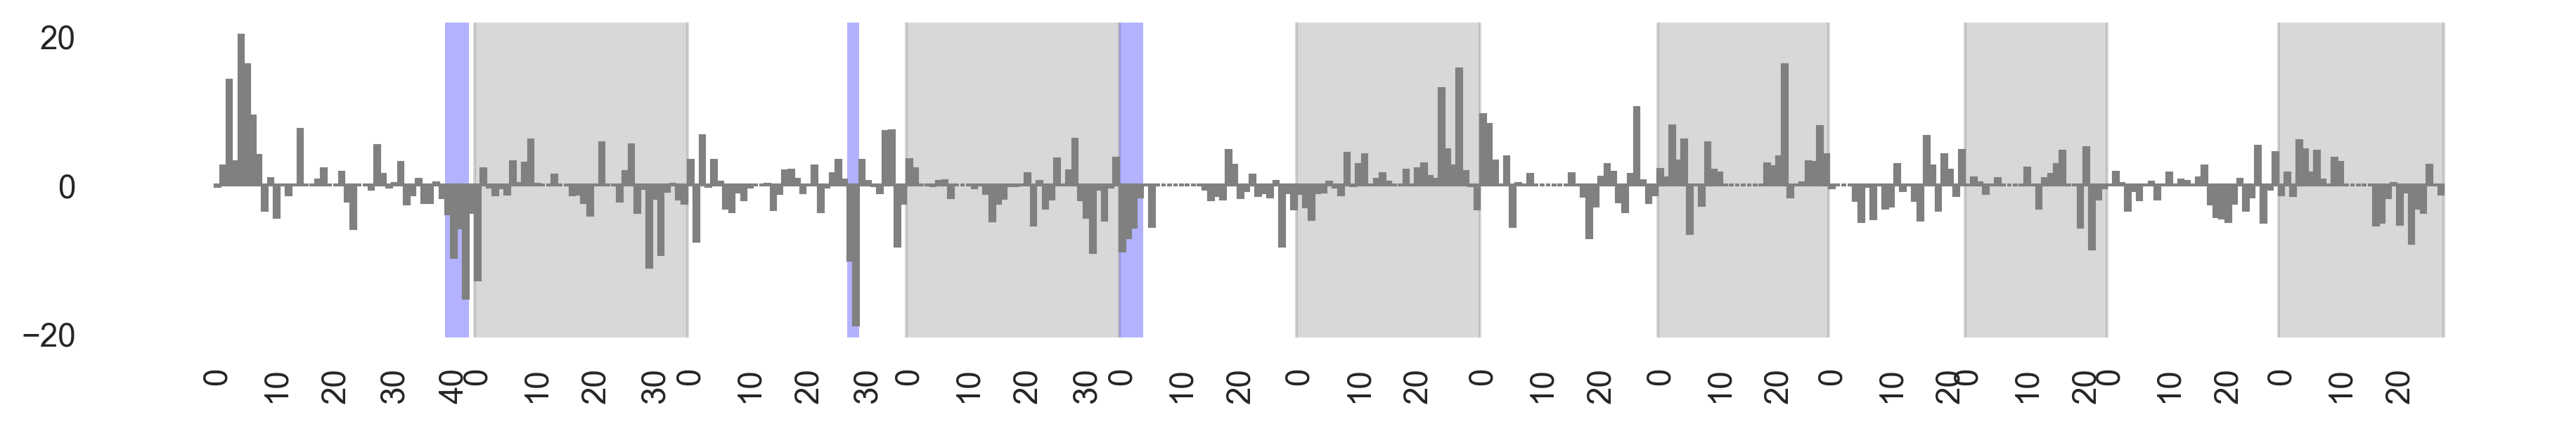

N04


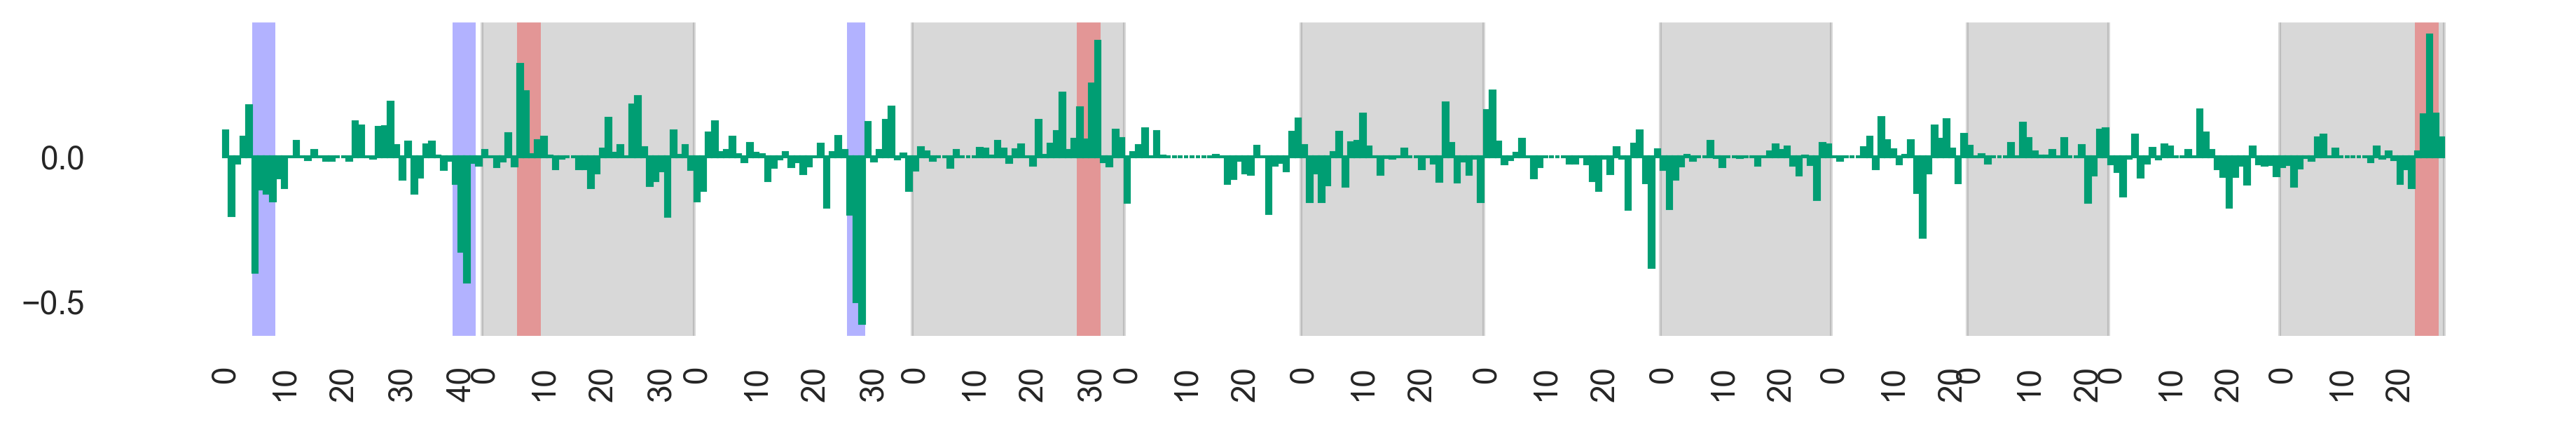

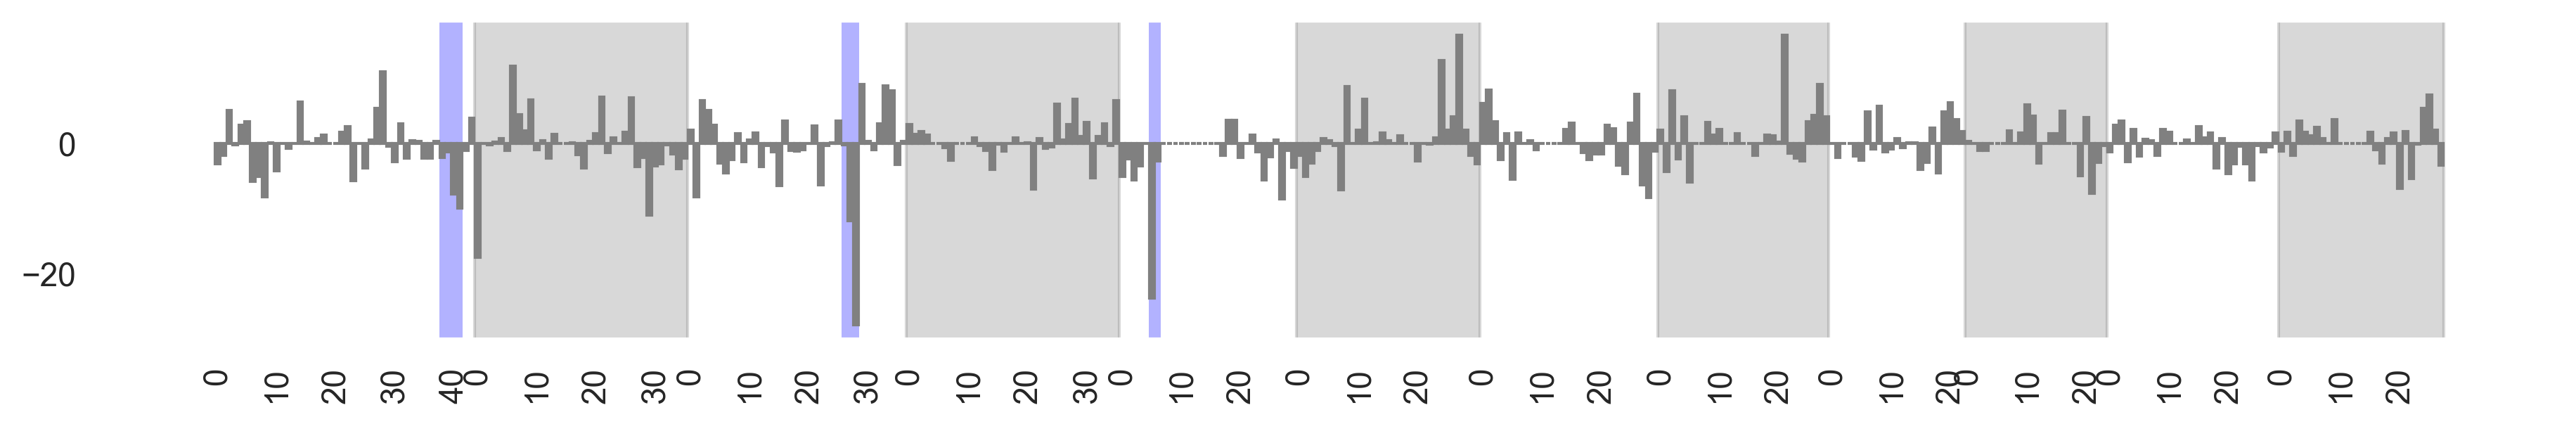

N05


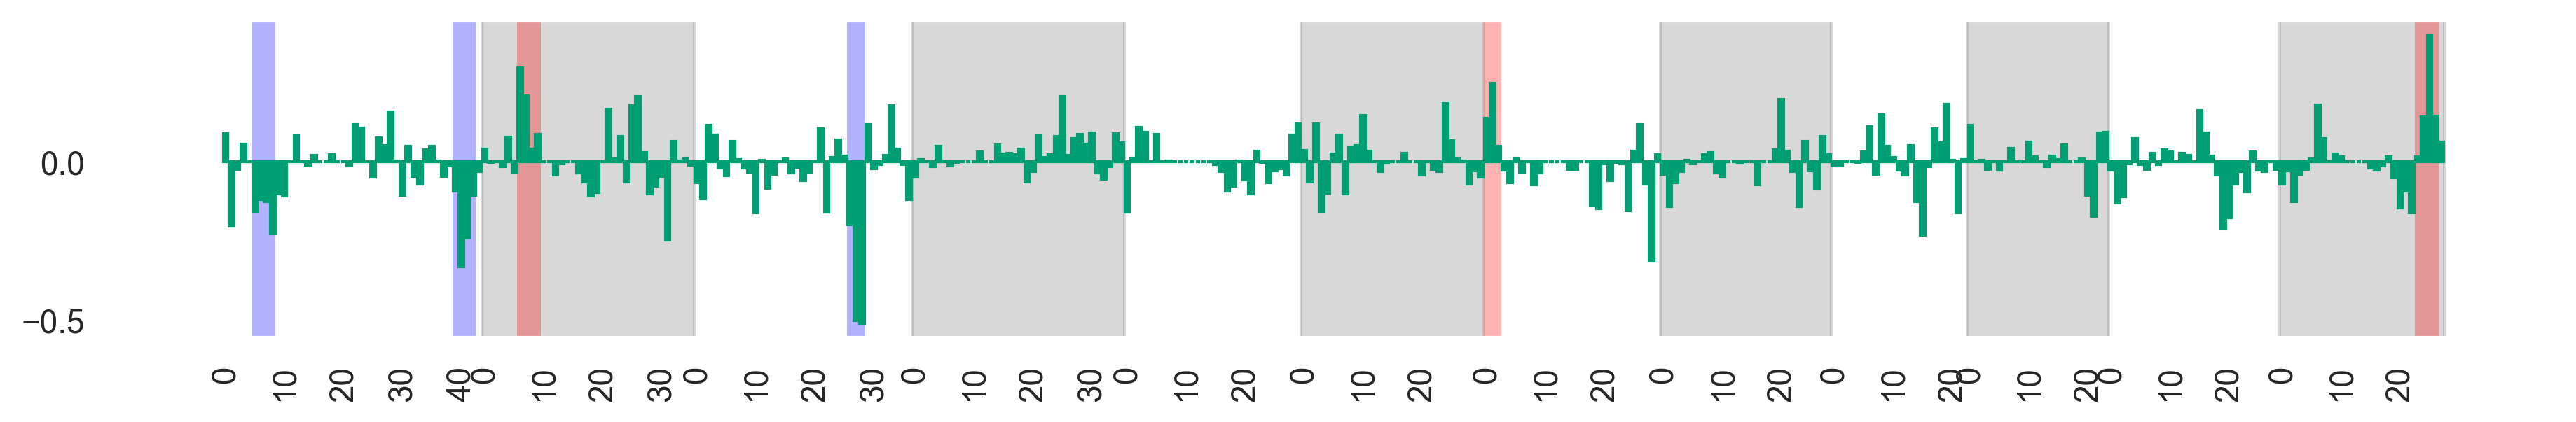

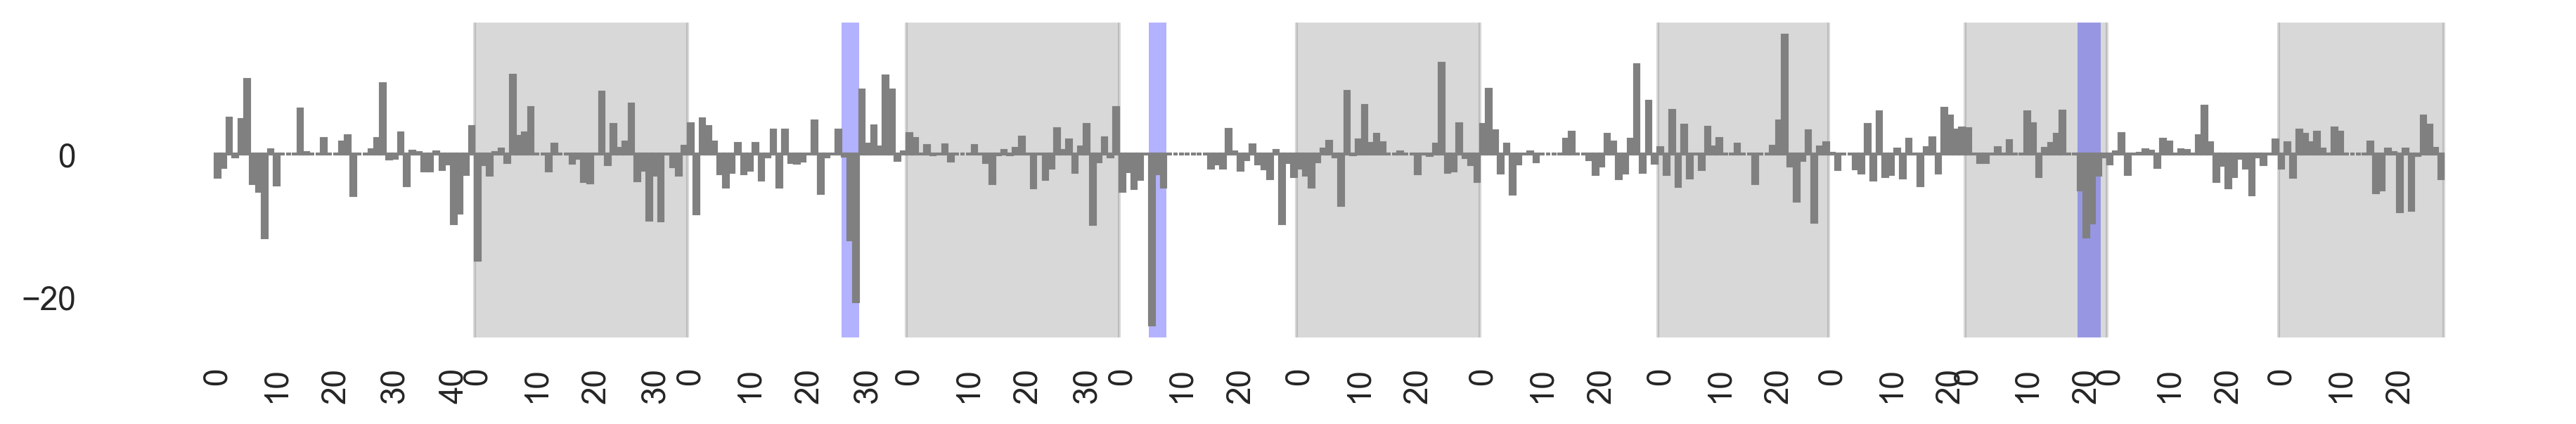

N06


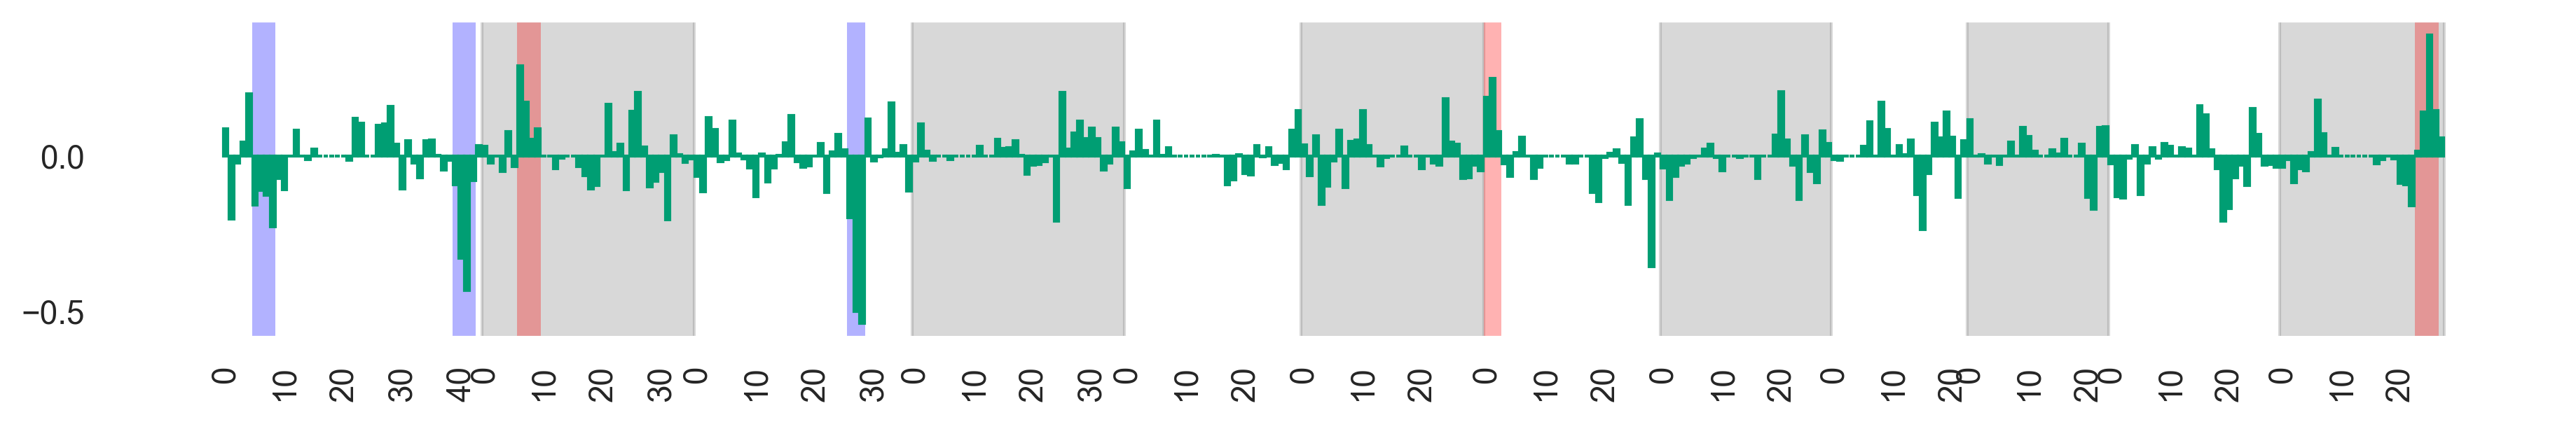

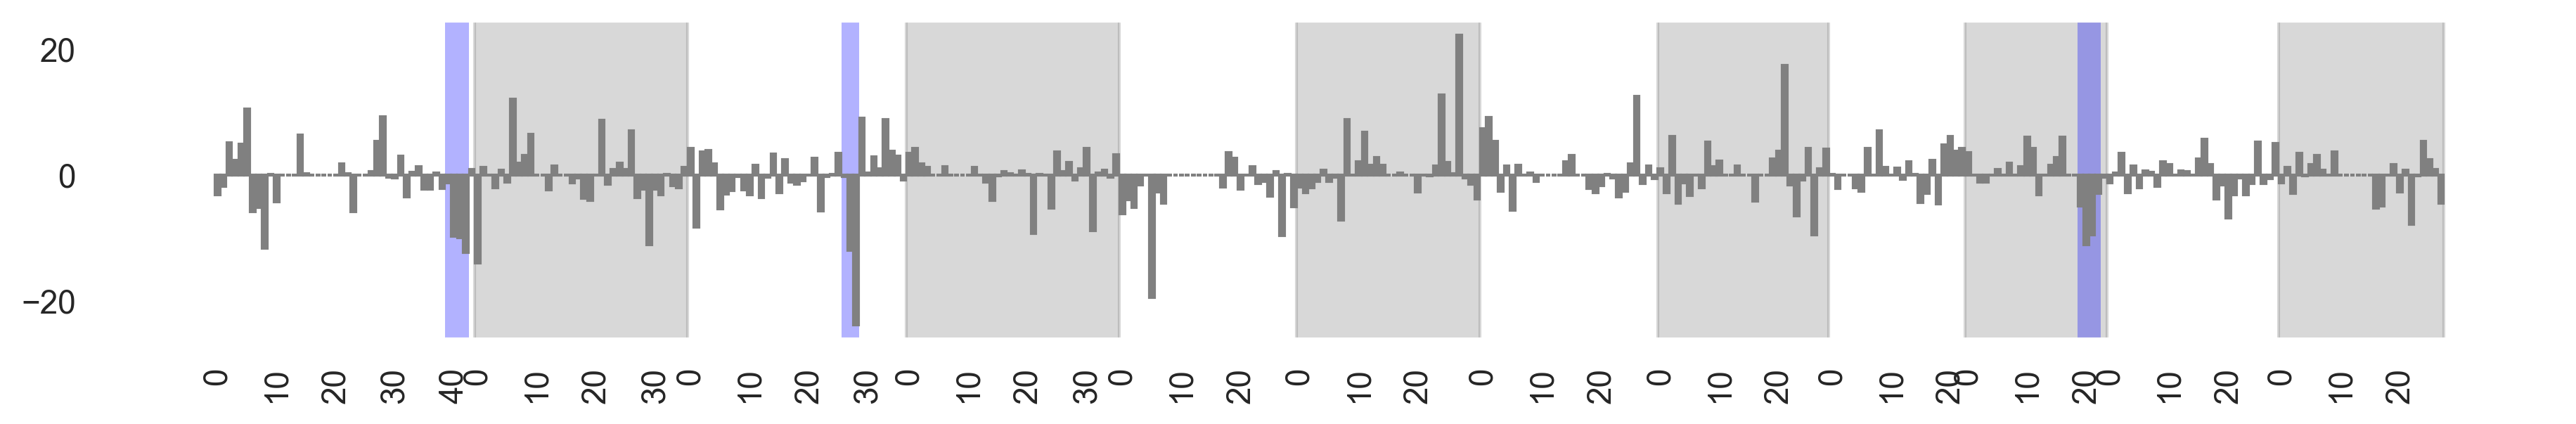

N07


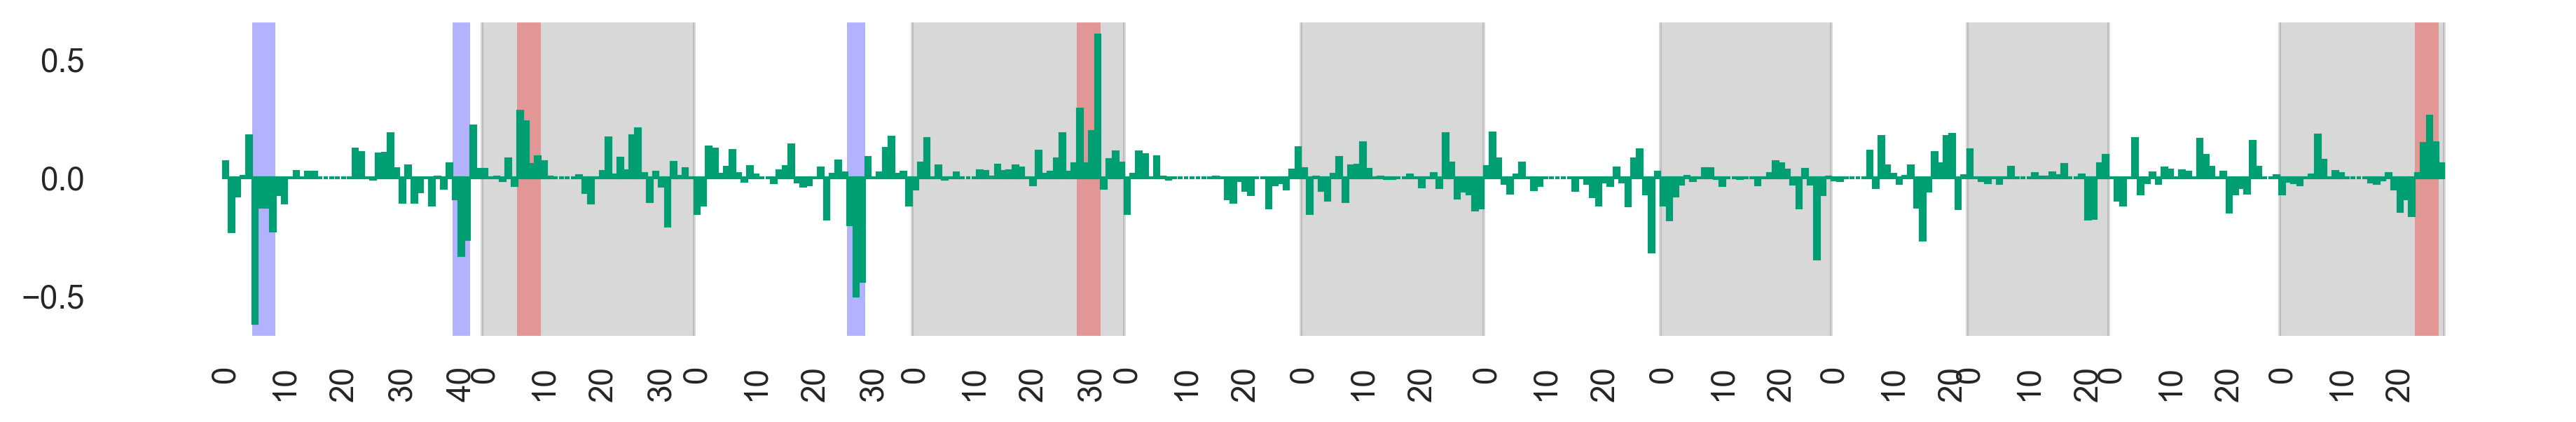

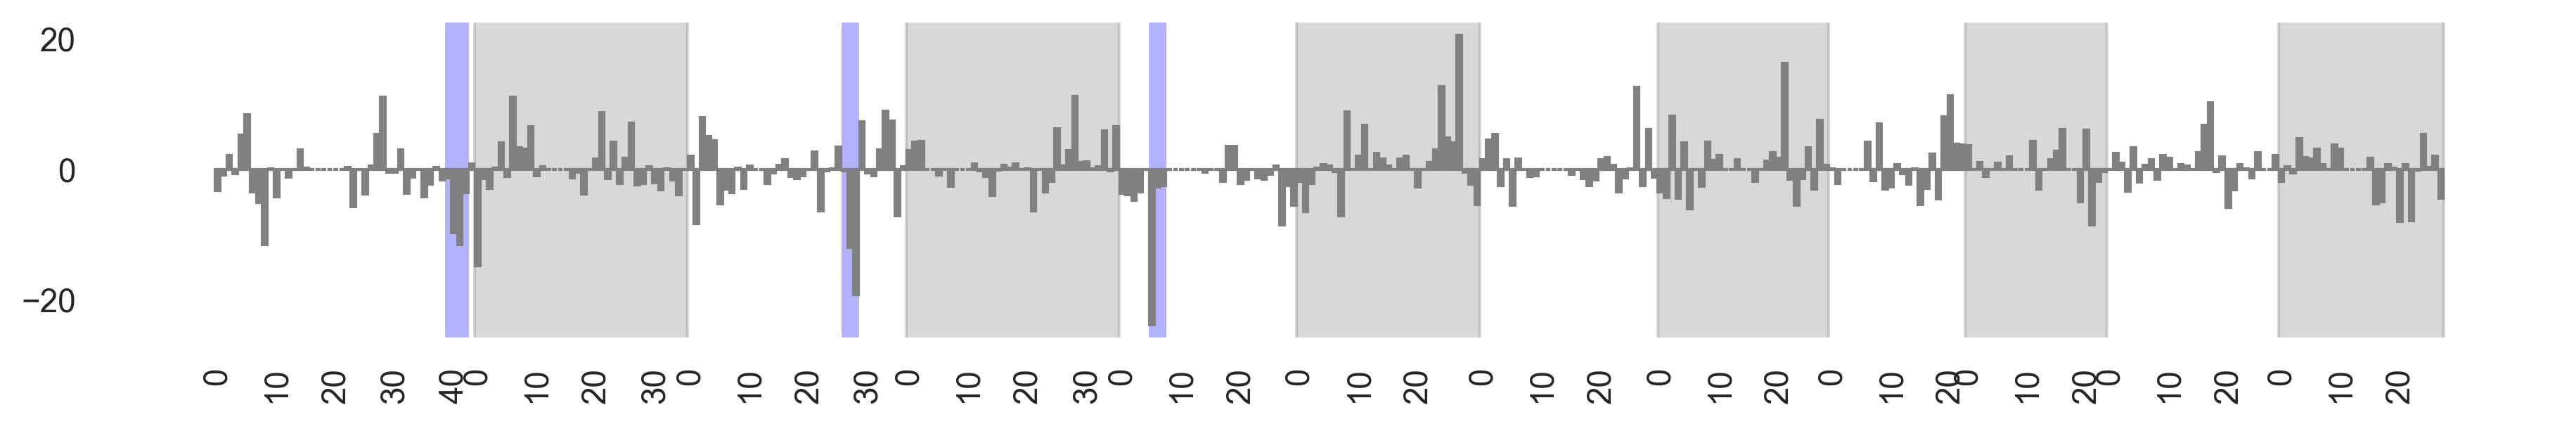

N08


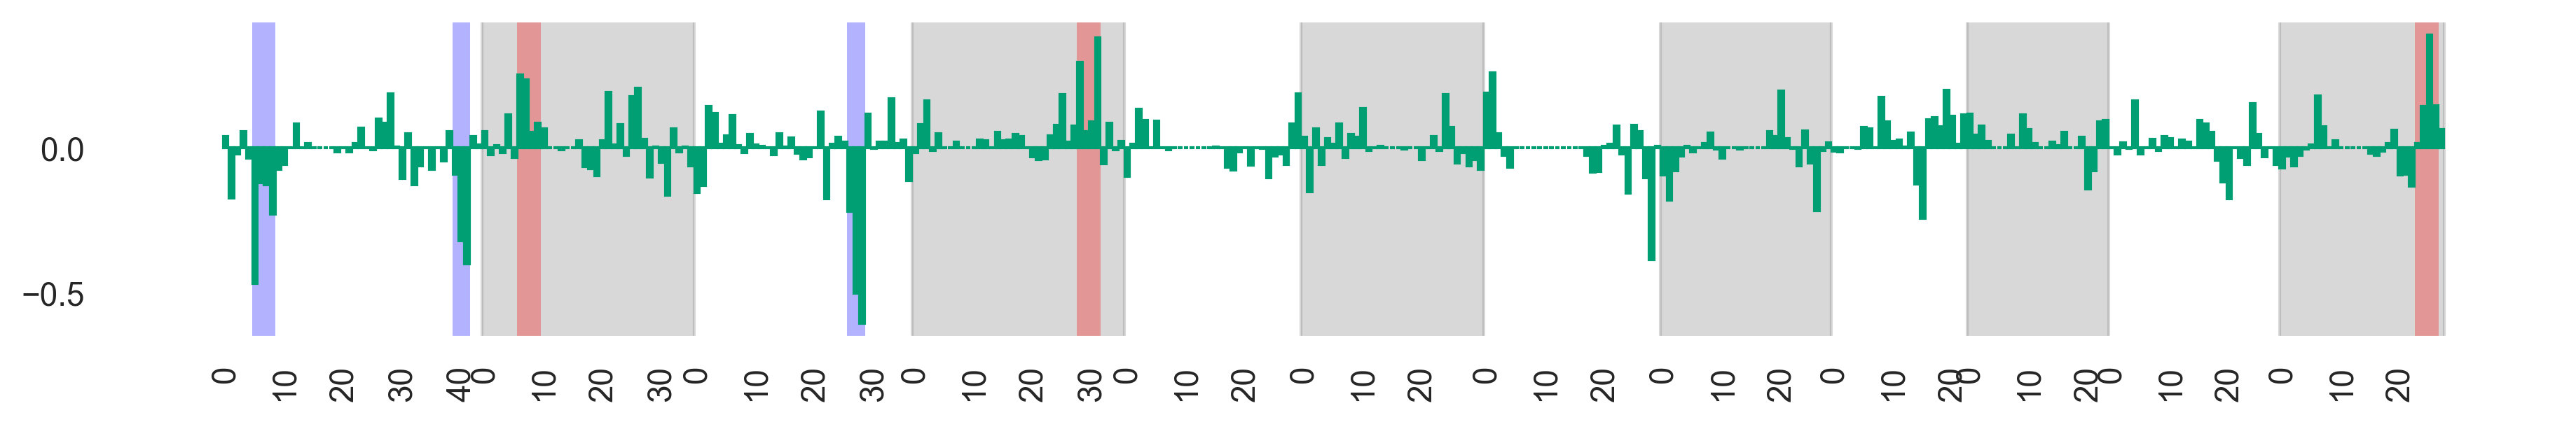

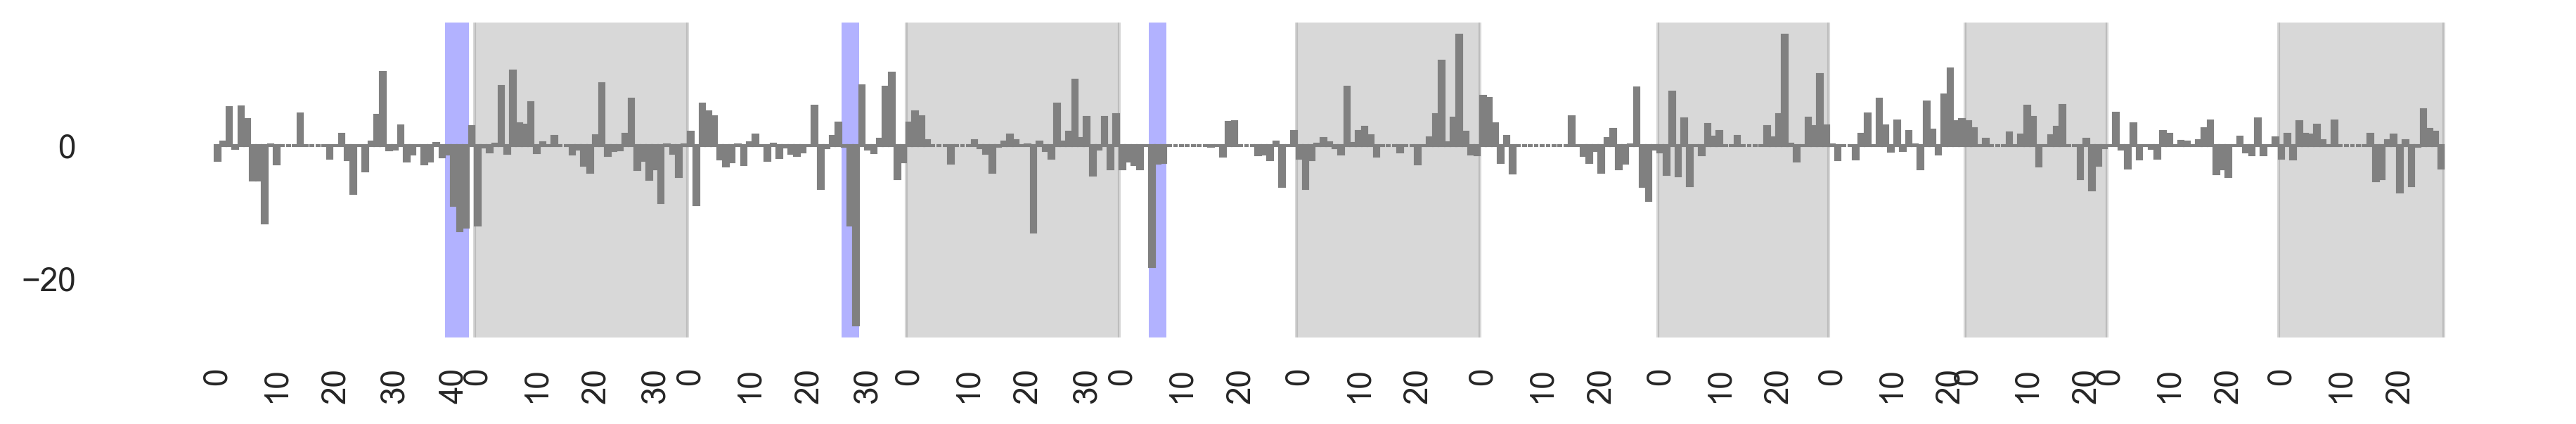

N09


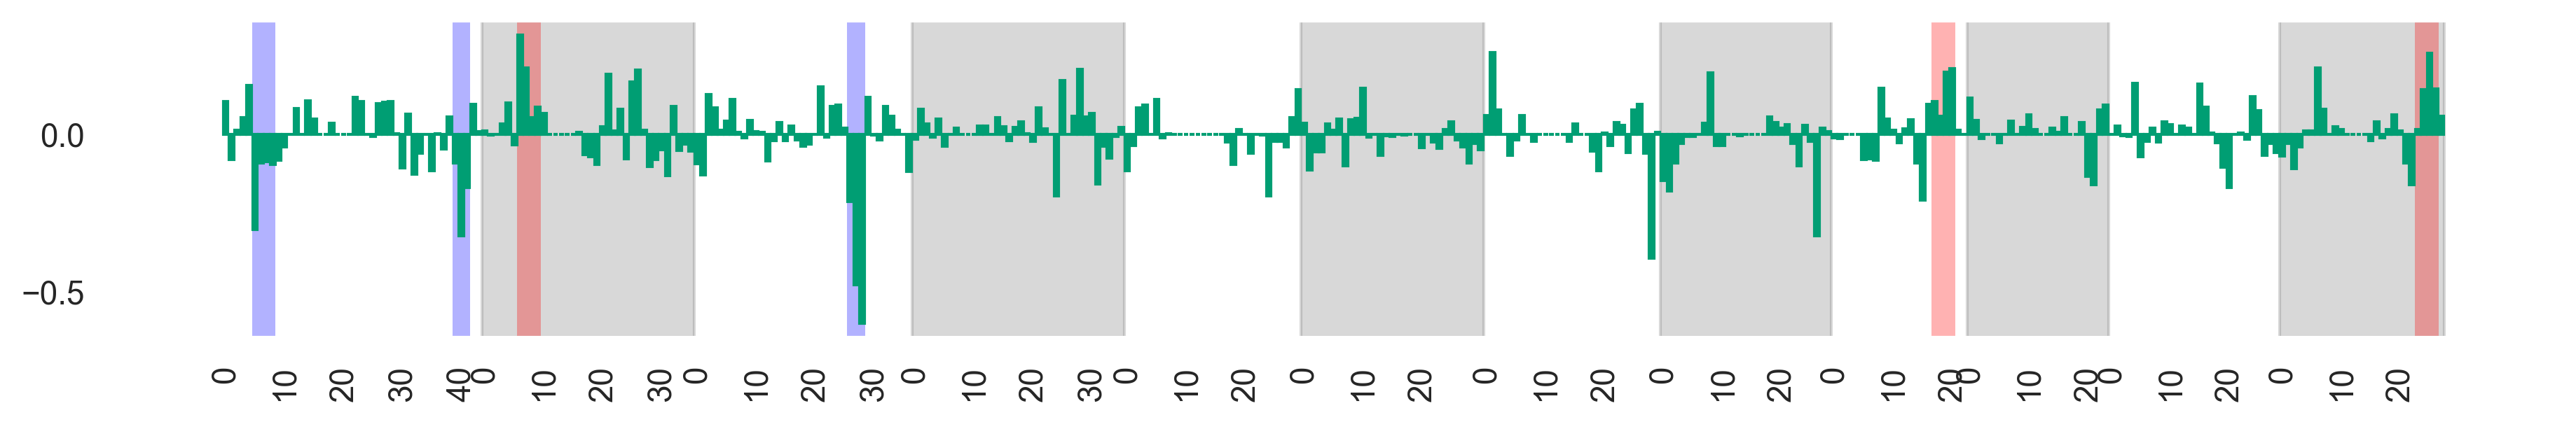

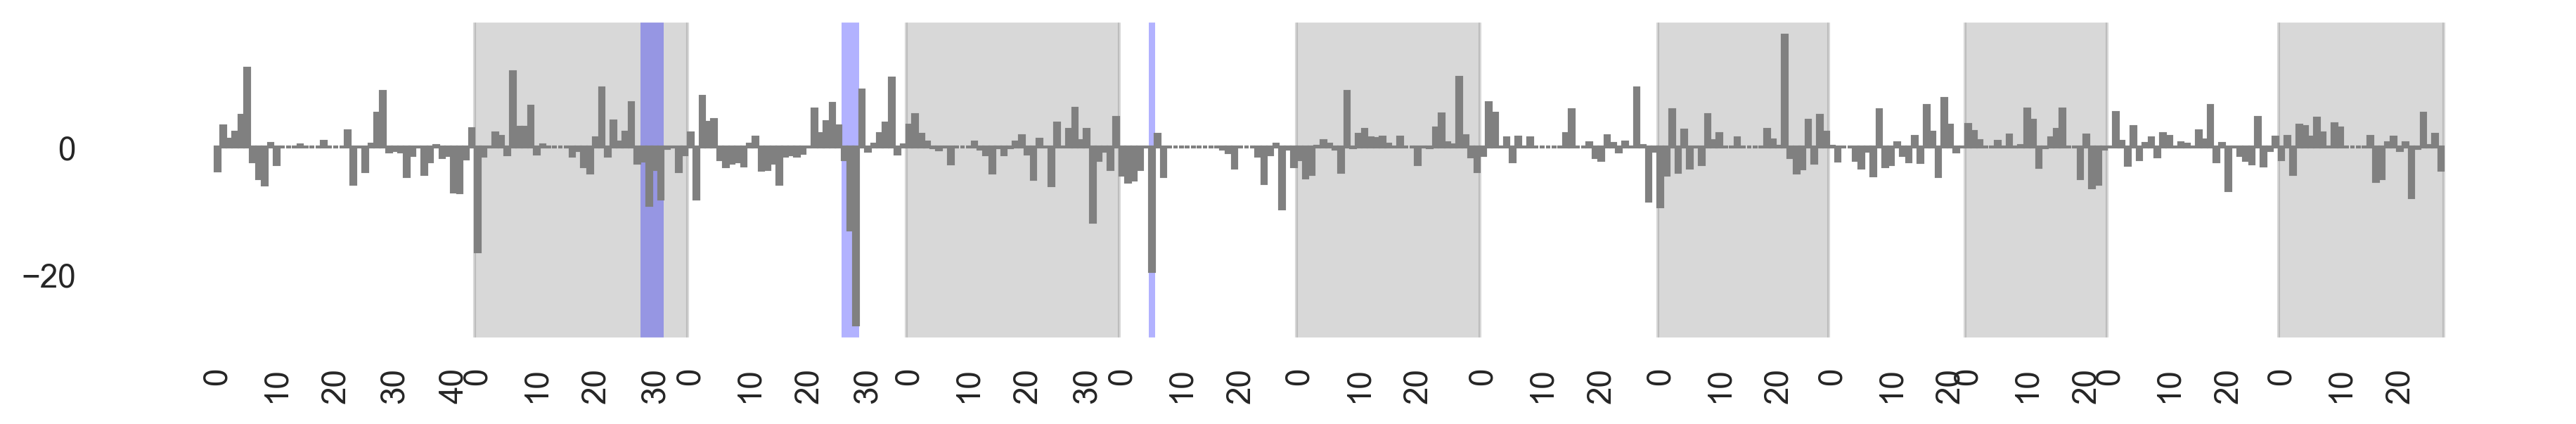

N10


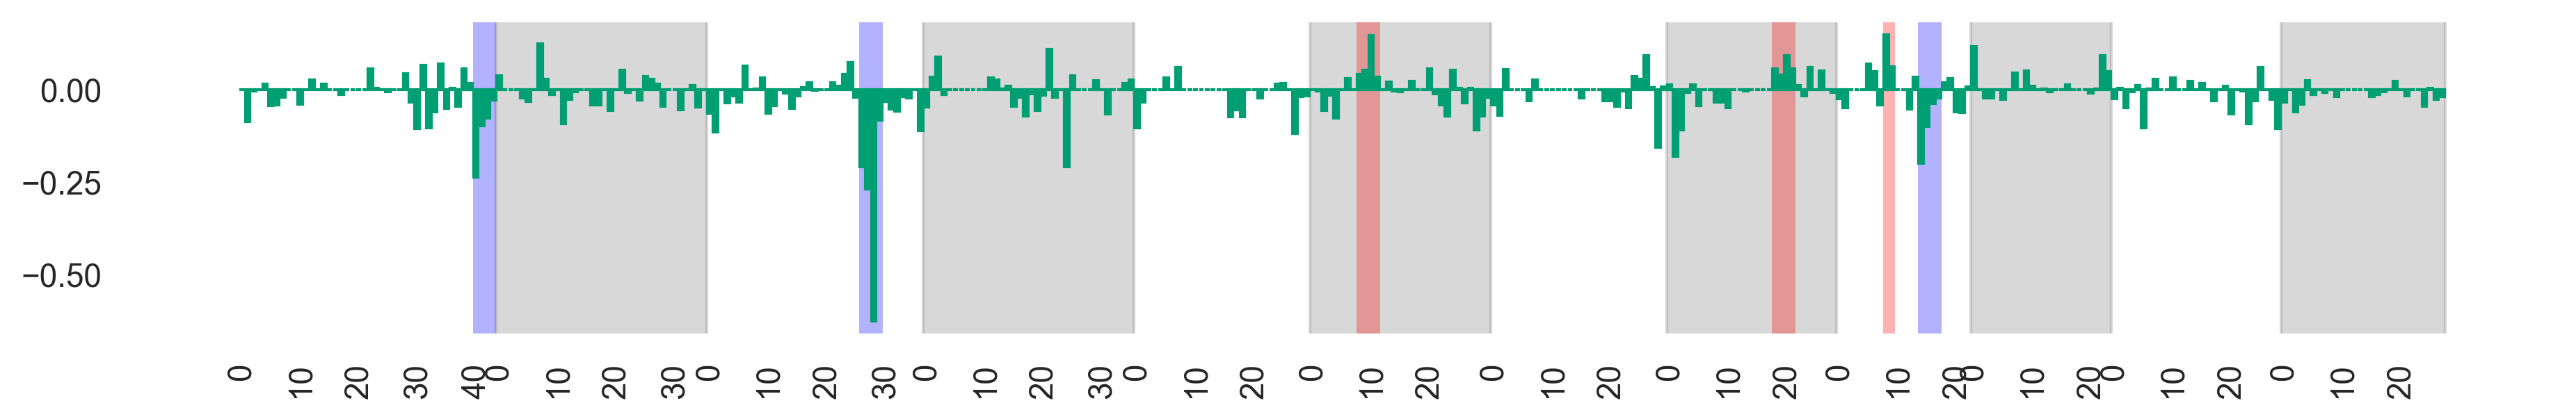

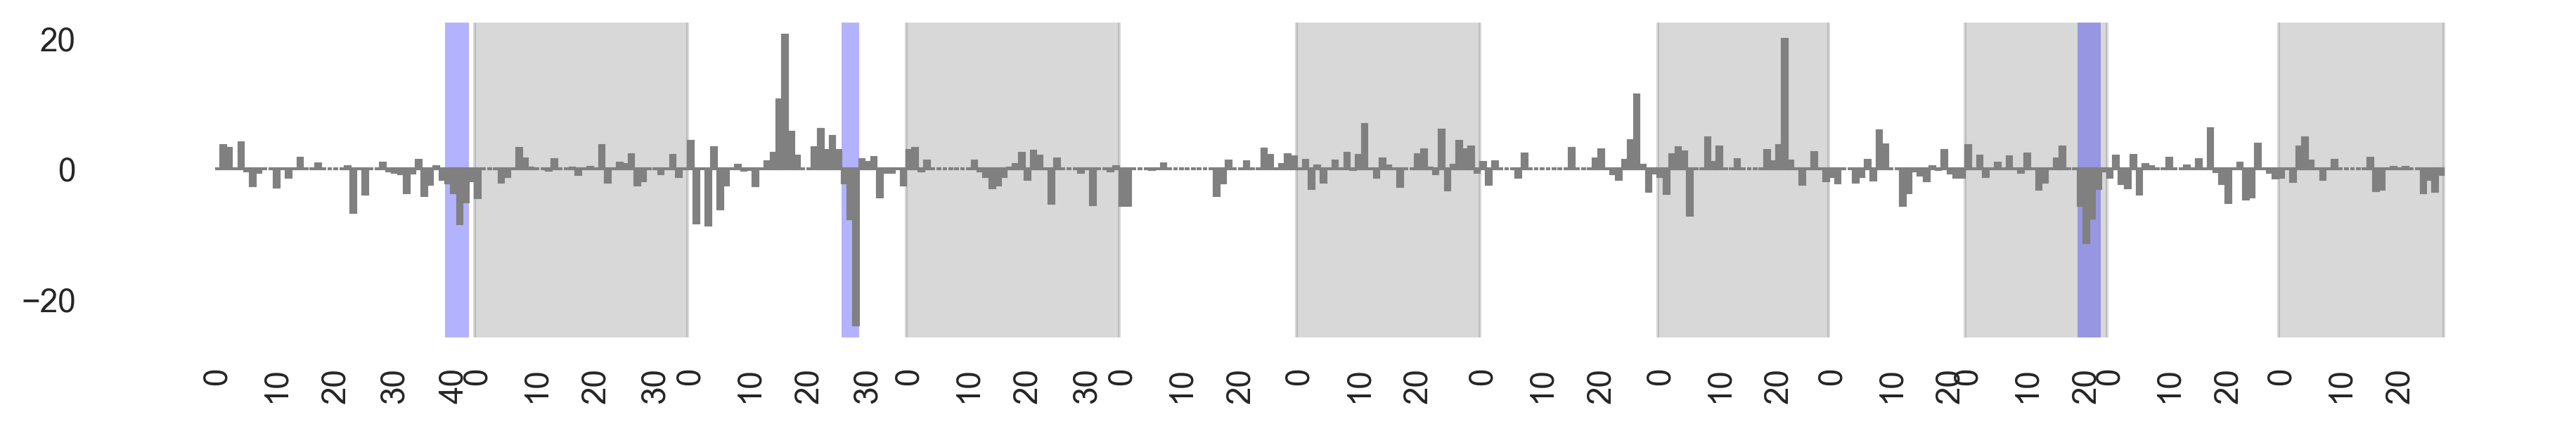

N11


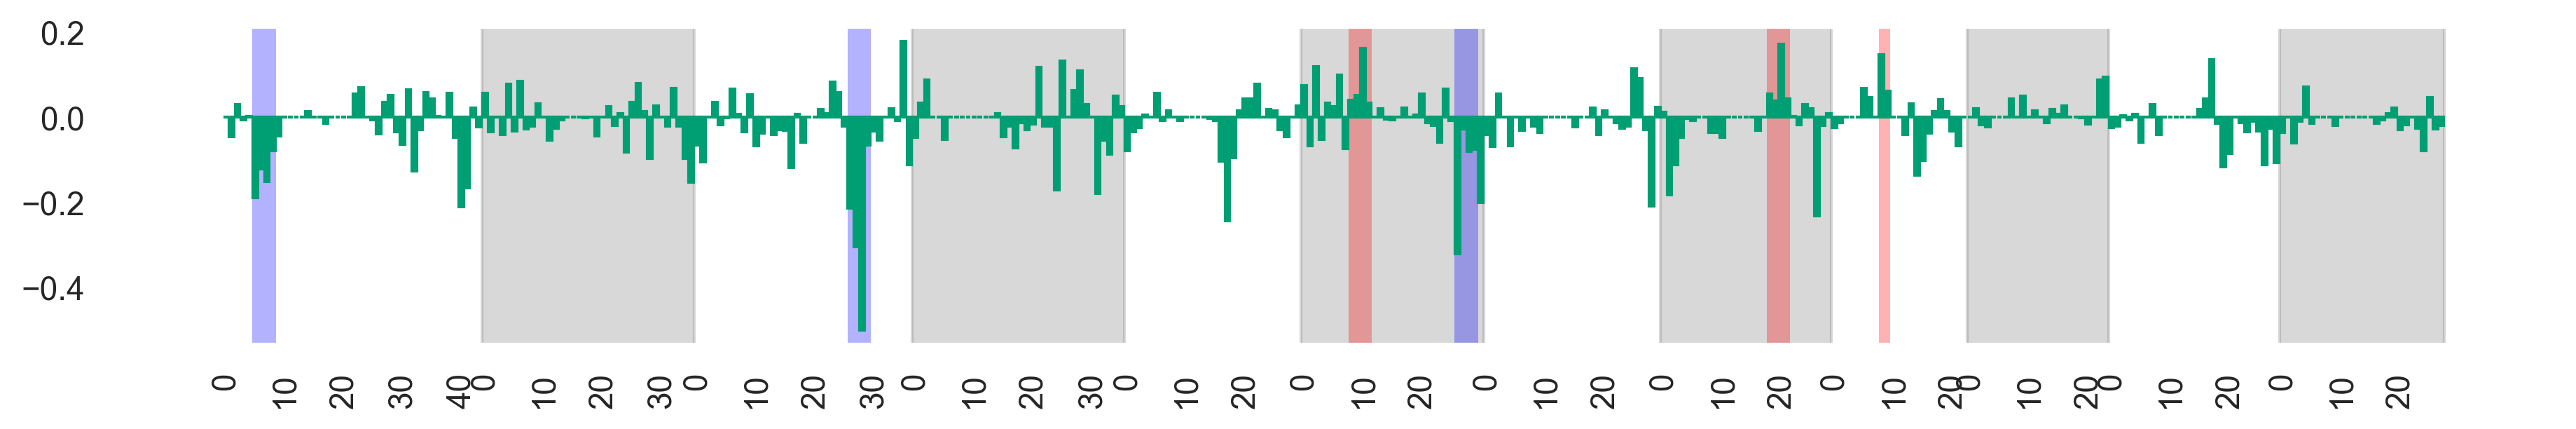

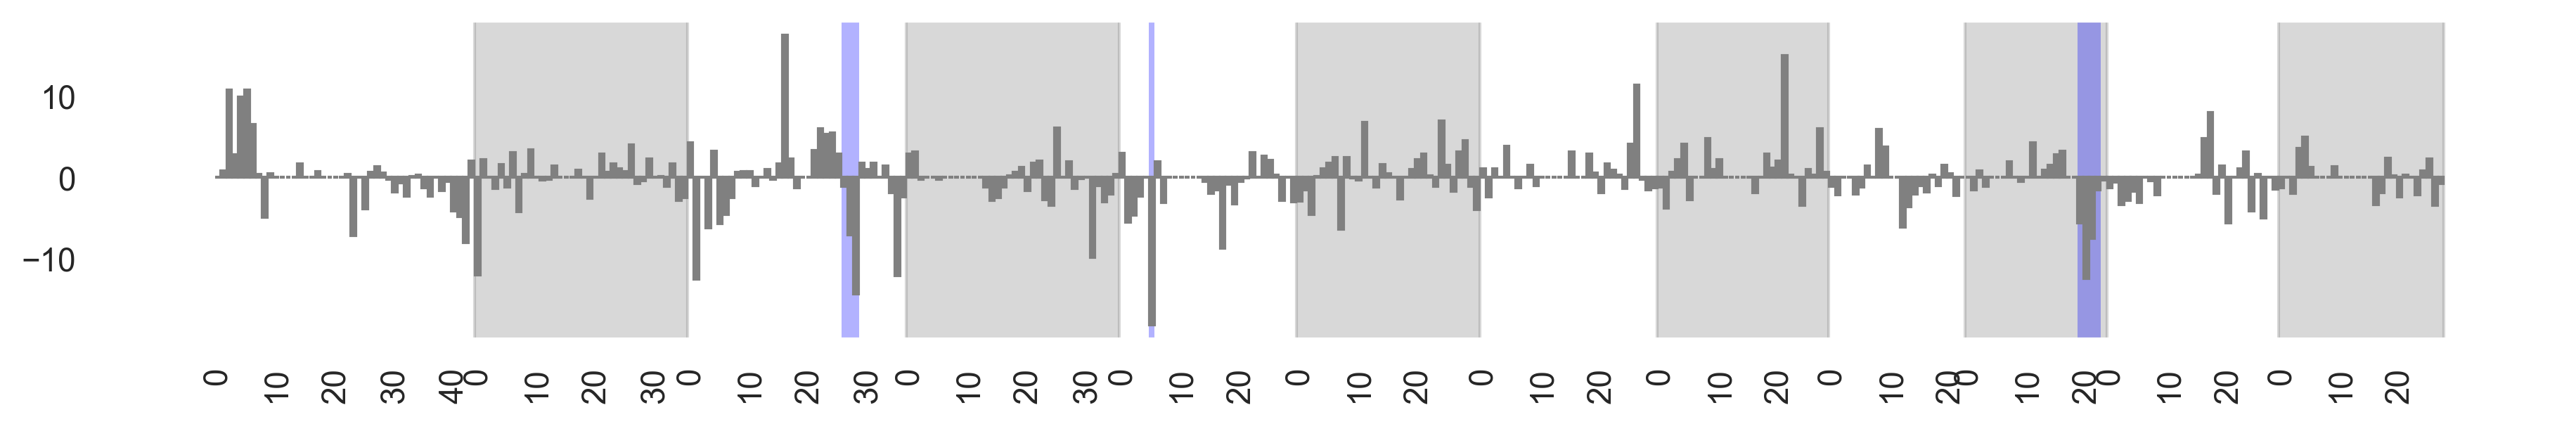

N12


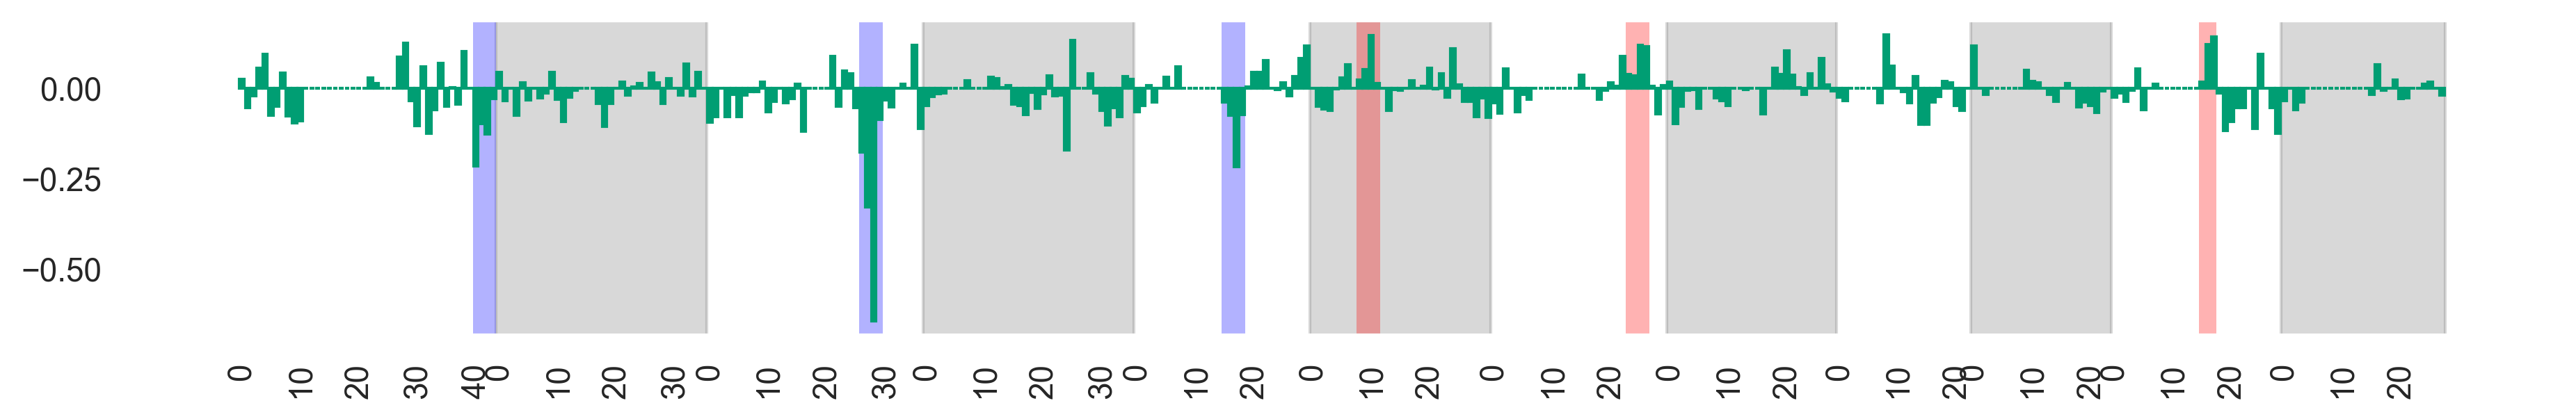

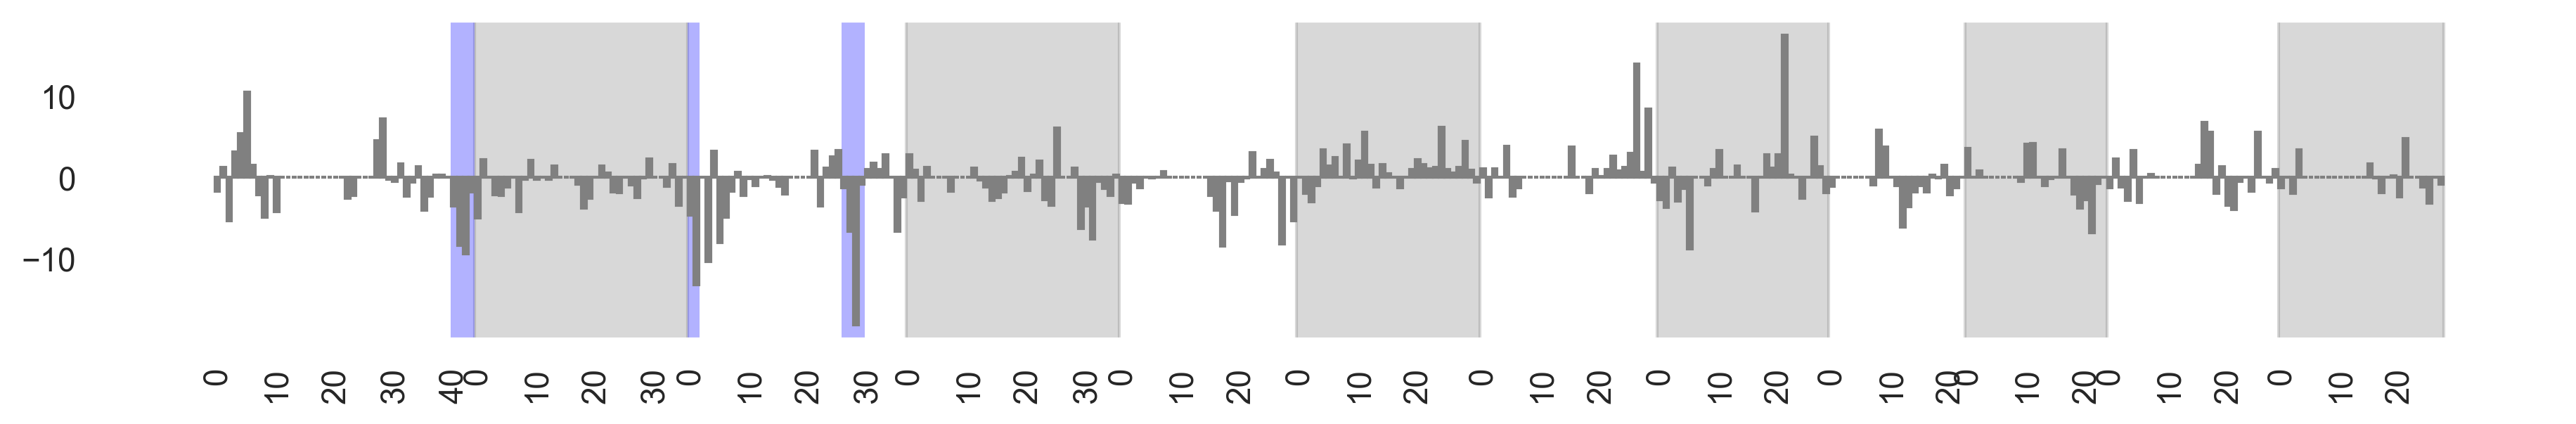

N13


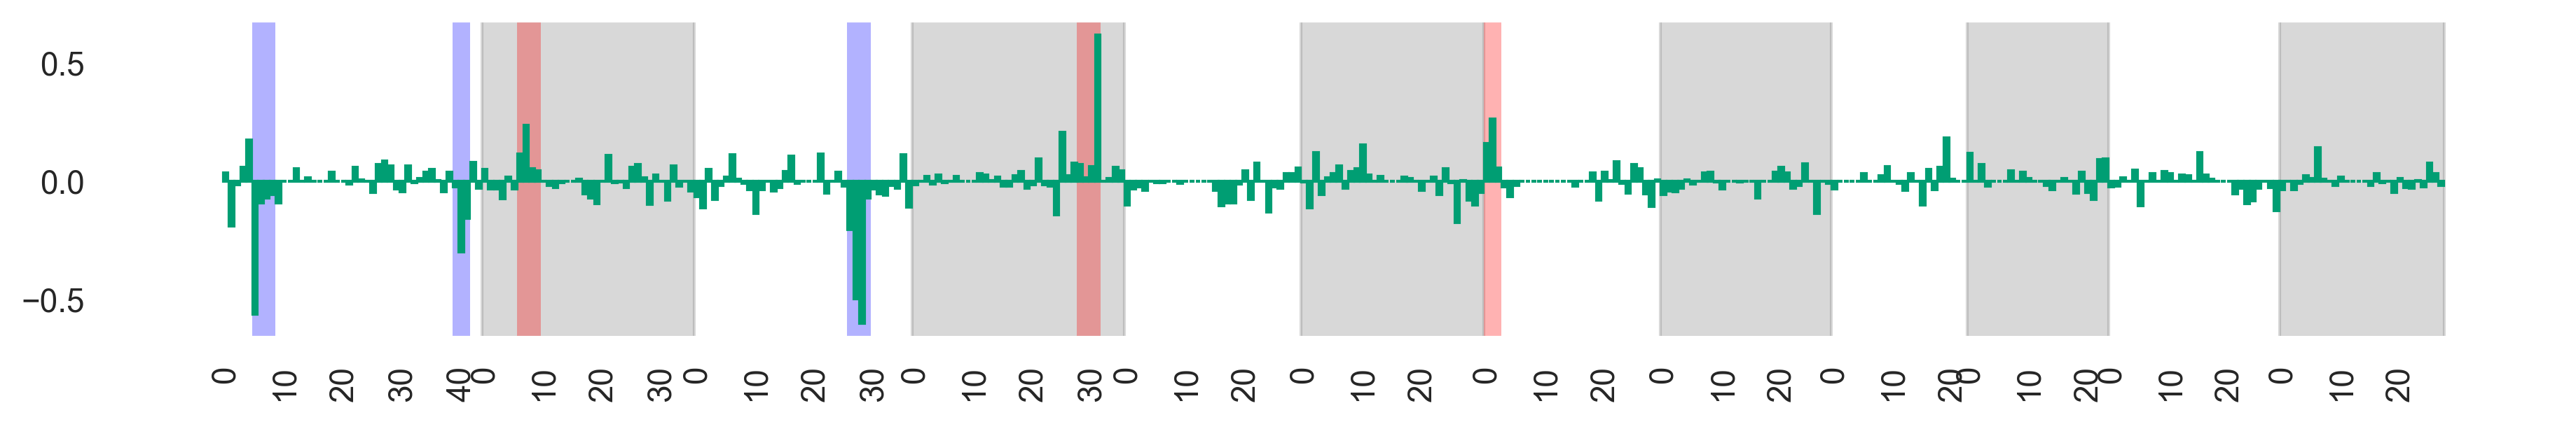

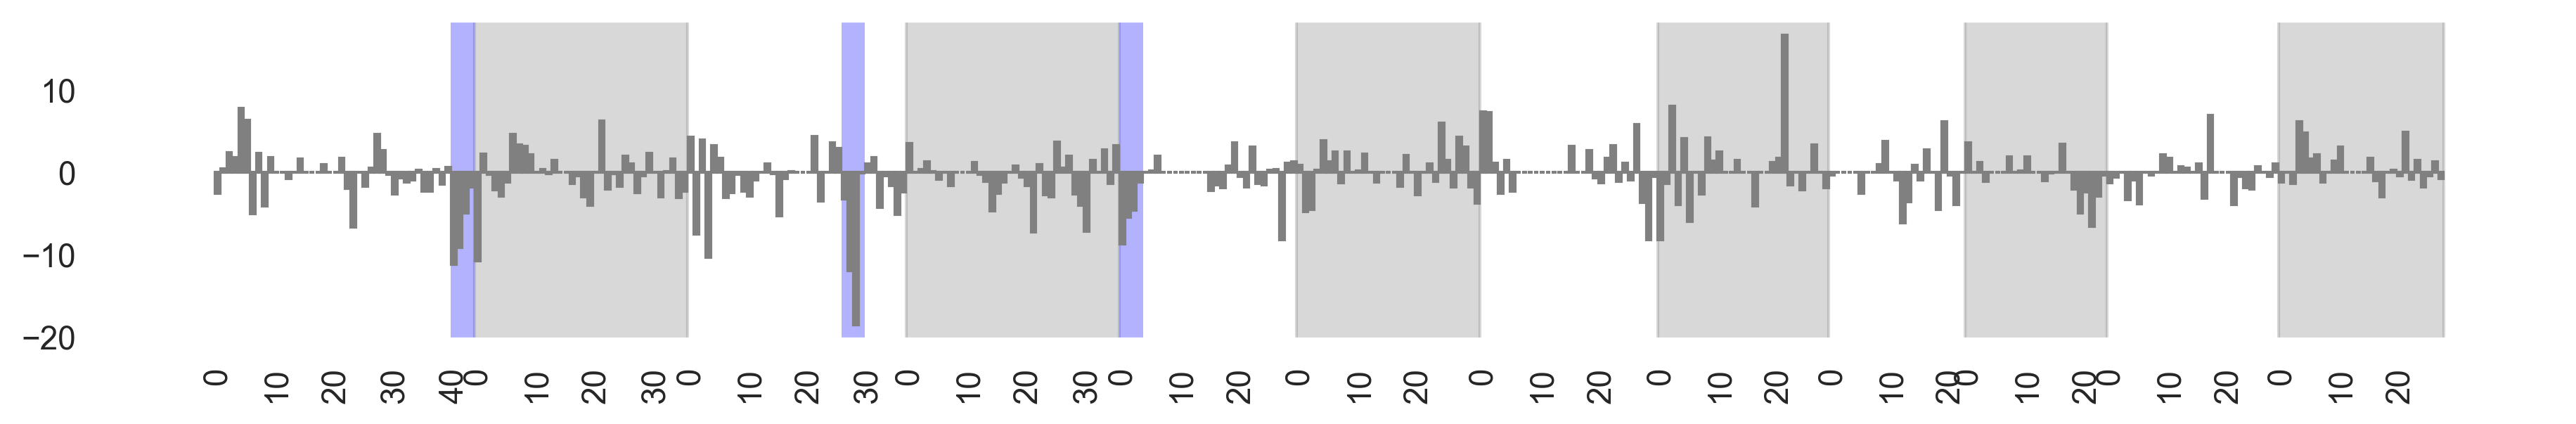

N14


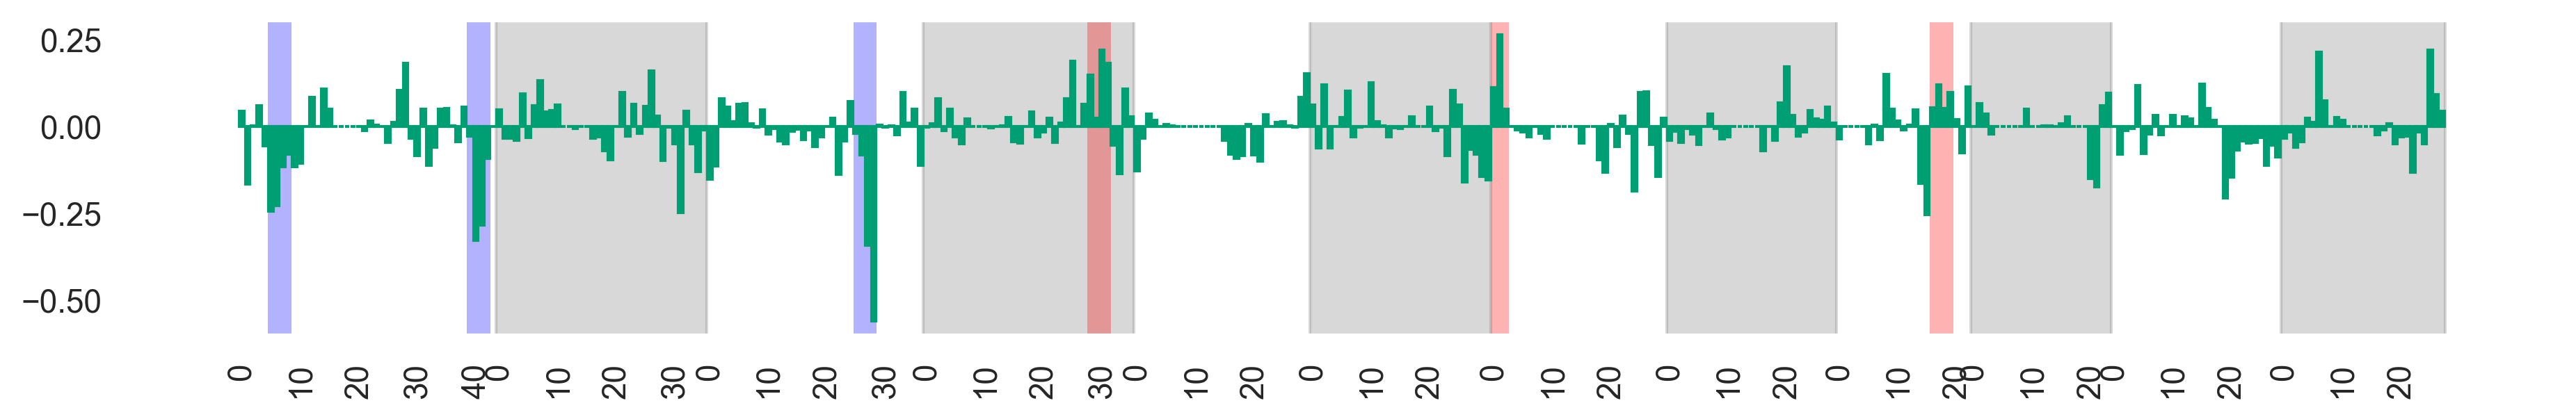

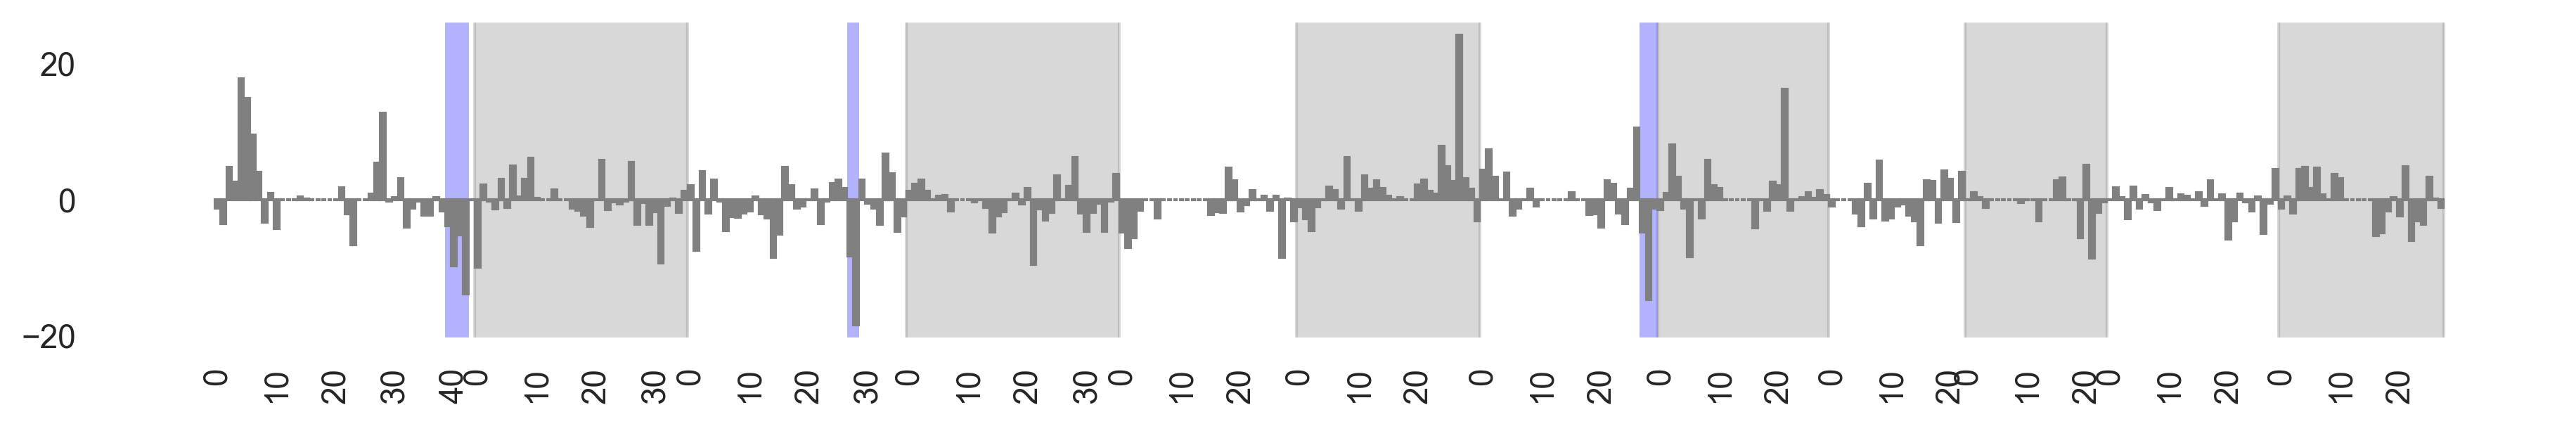

N16


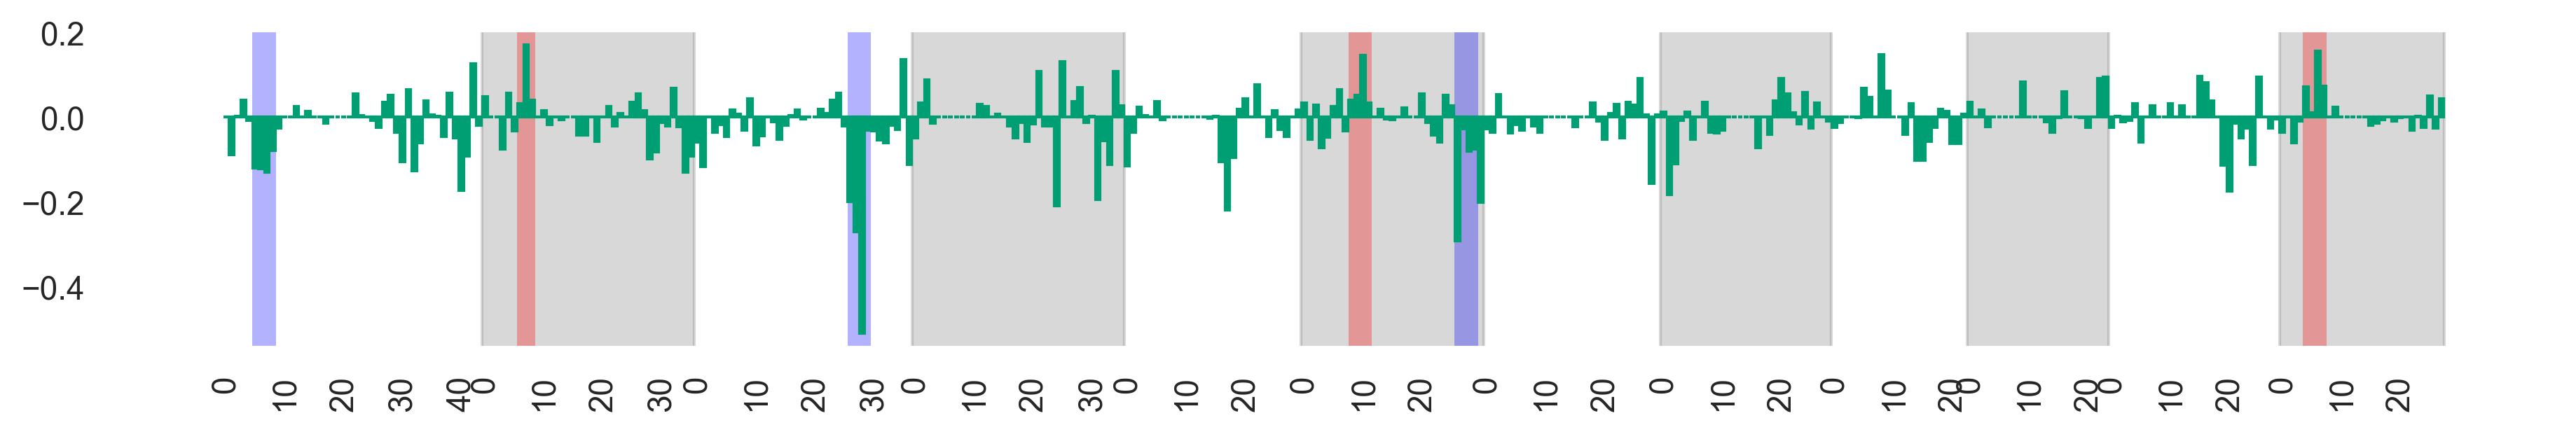

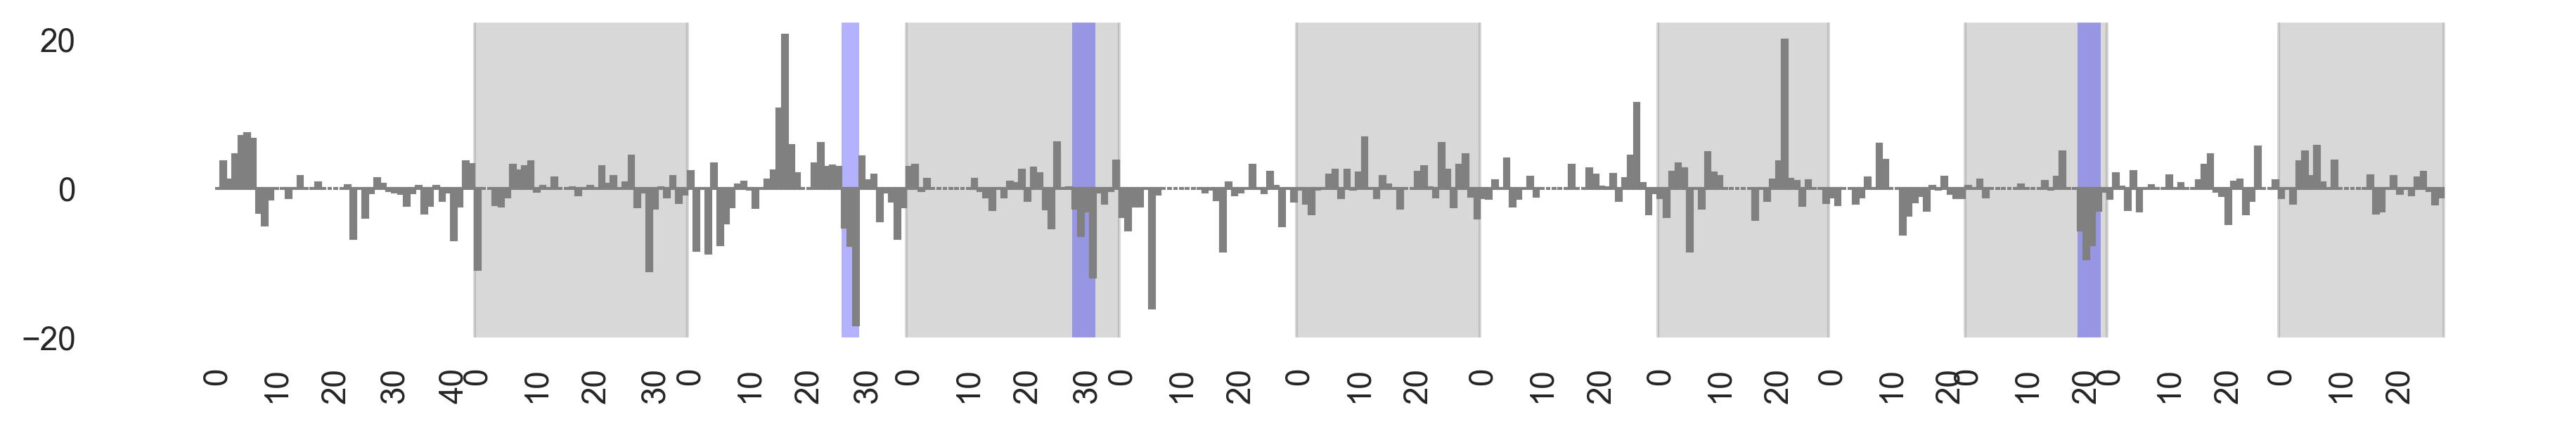

N17


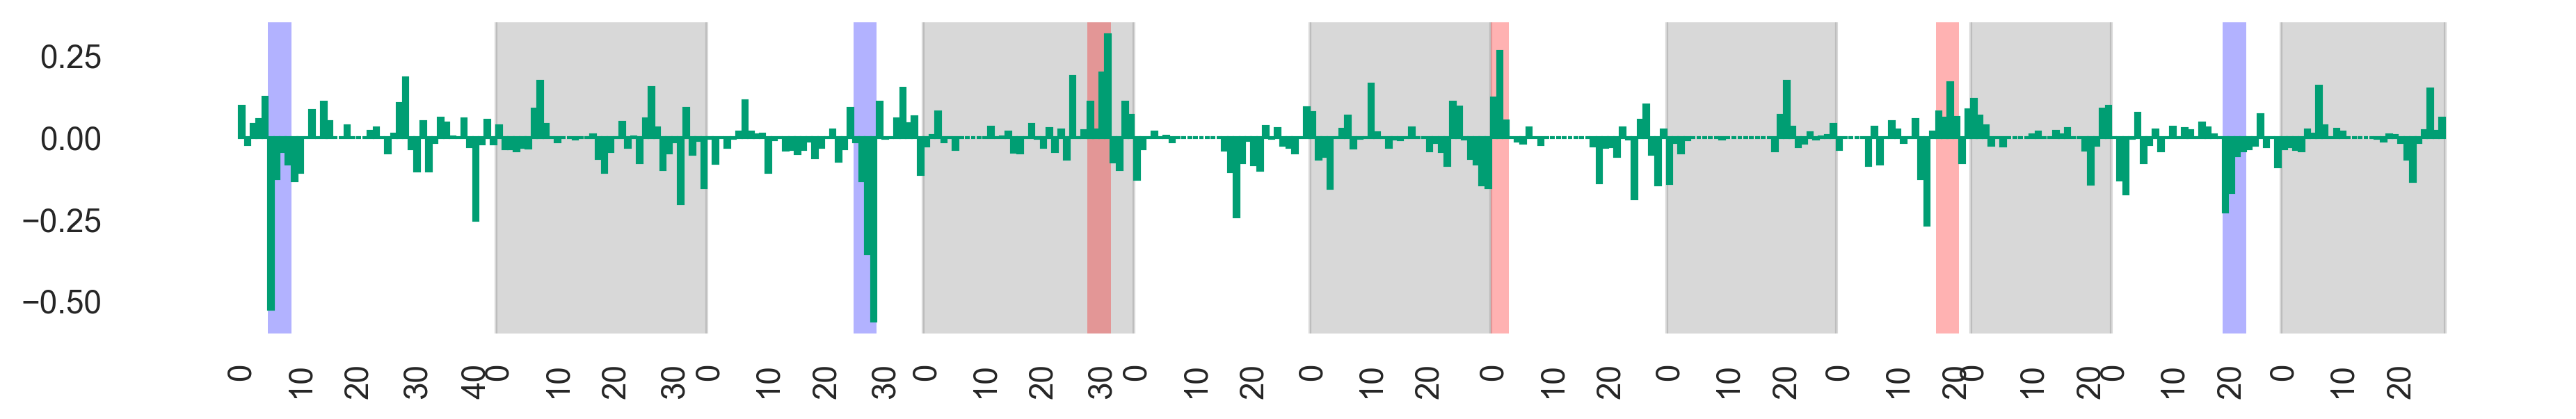

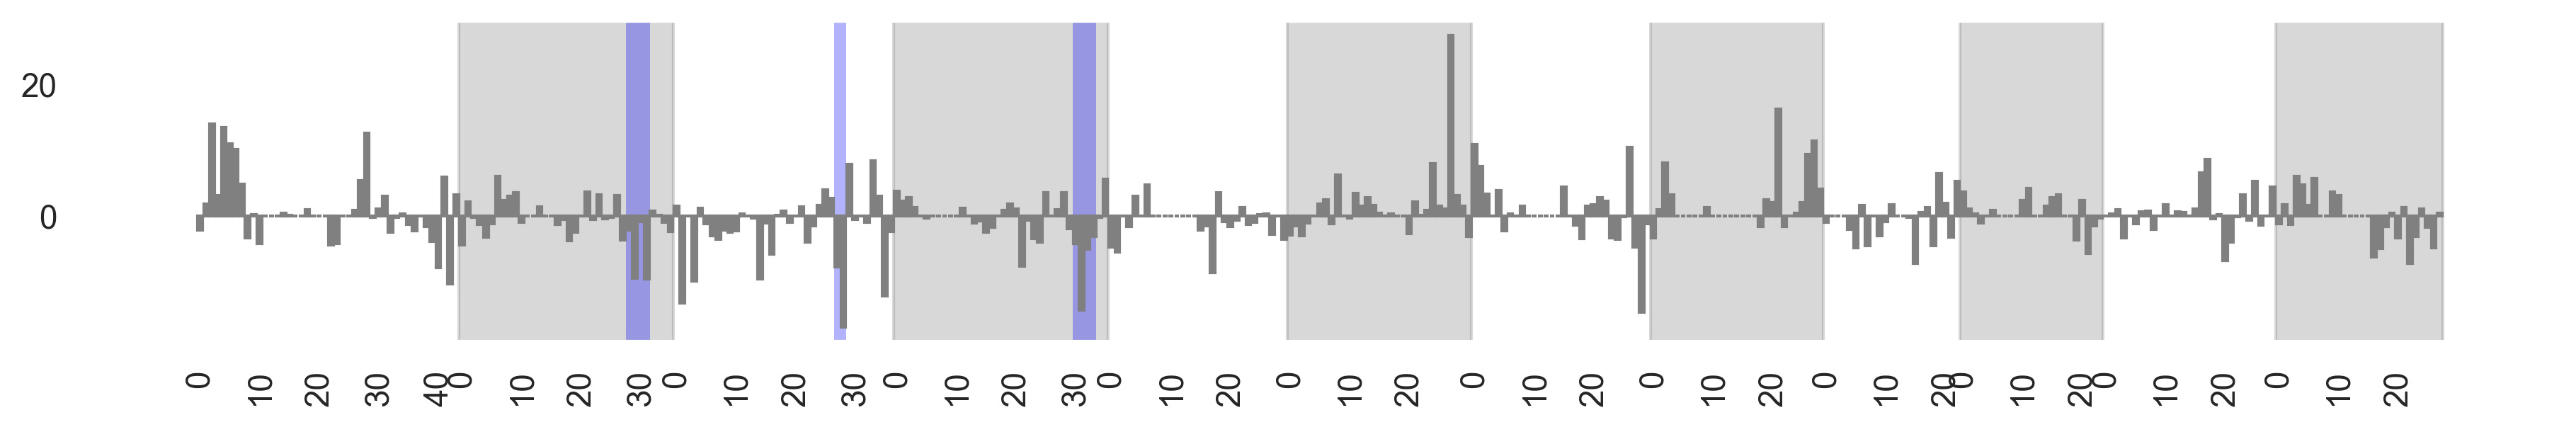

N18


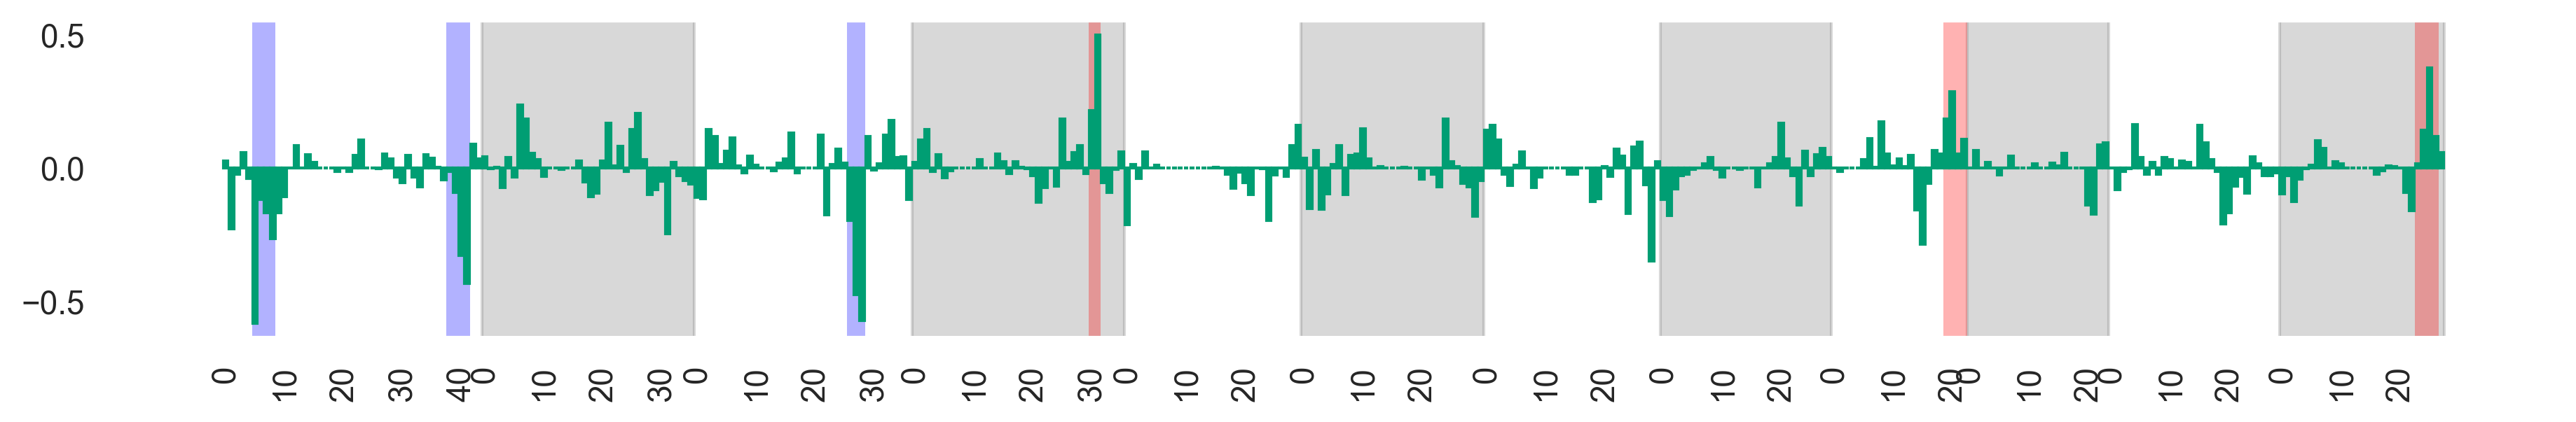

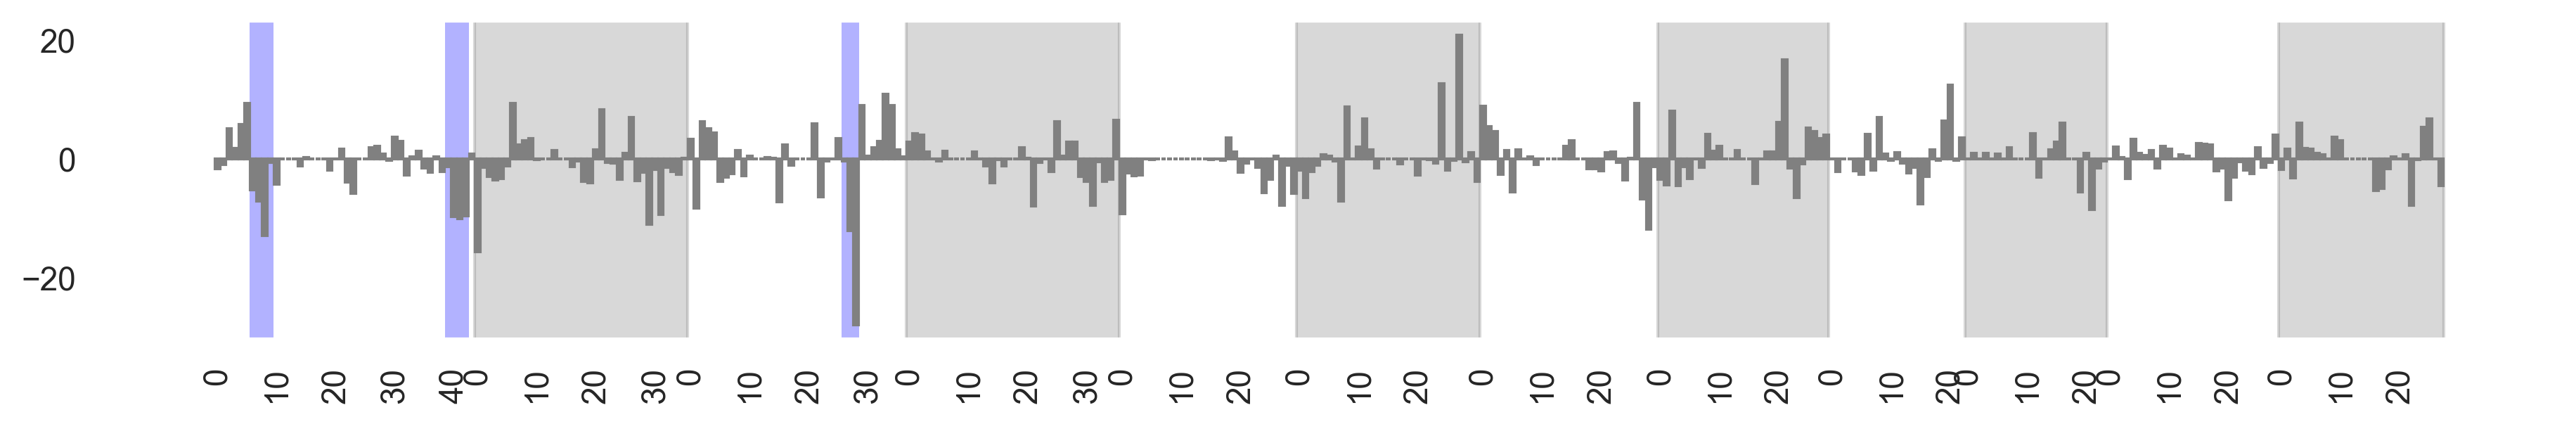

N19


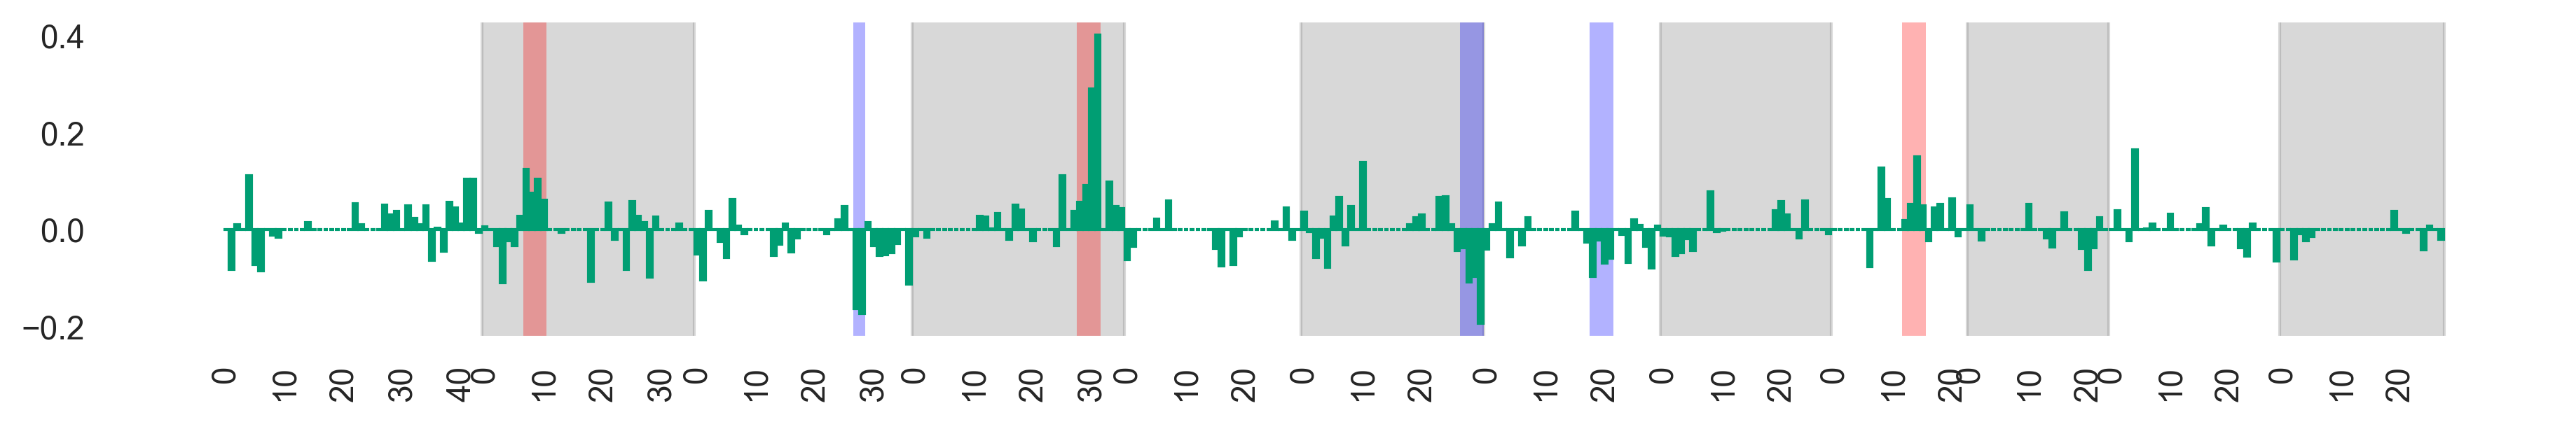

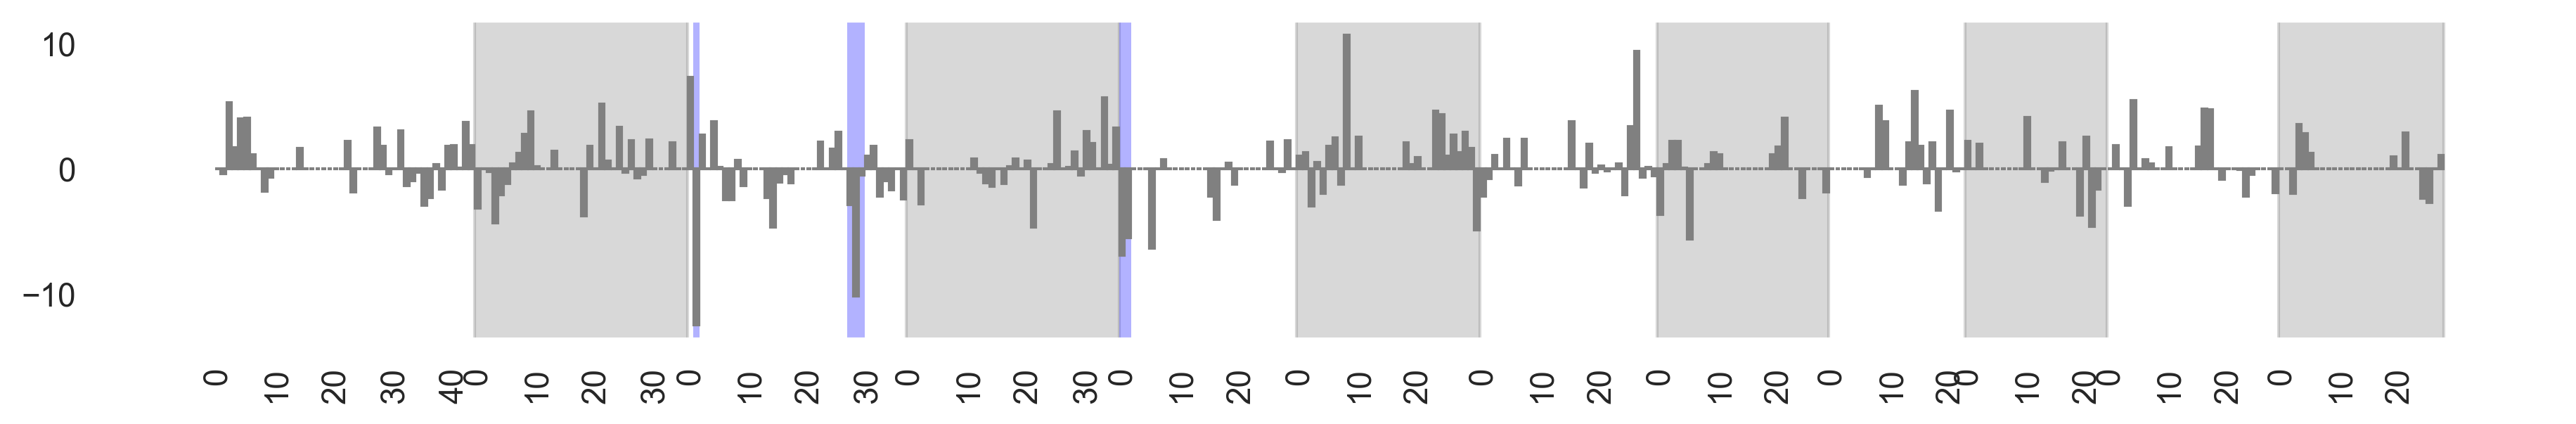

N20


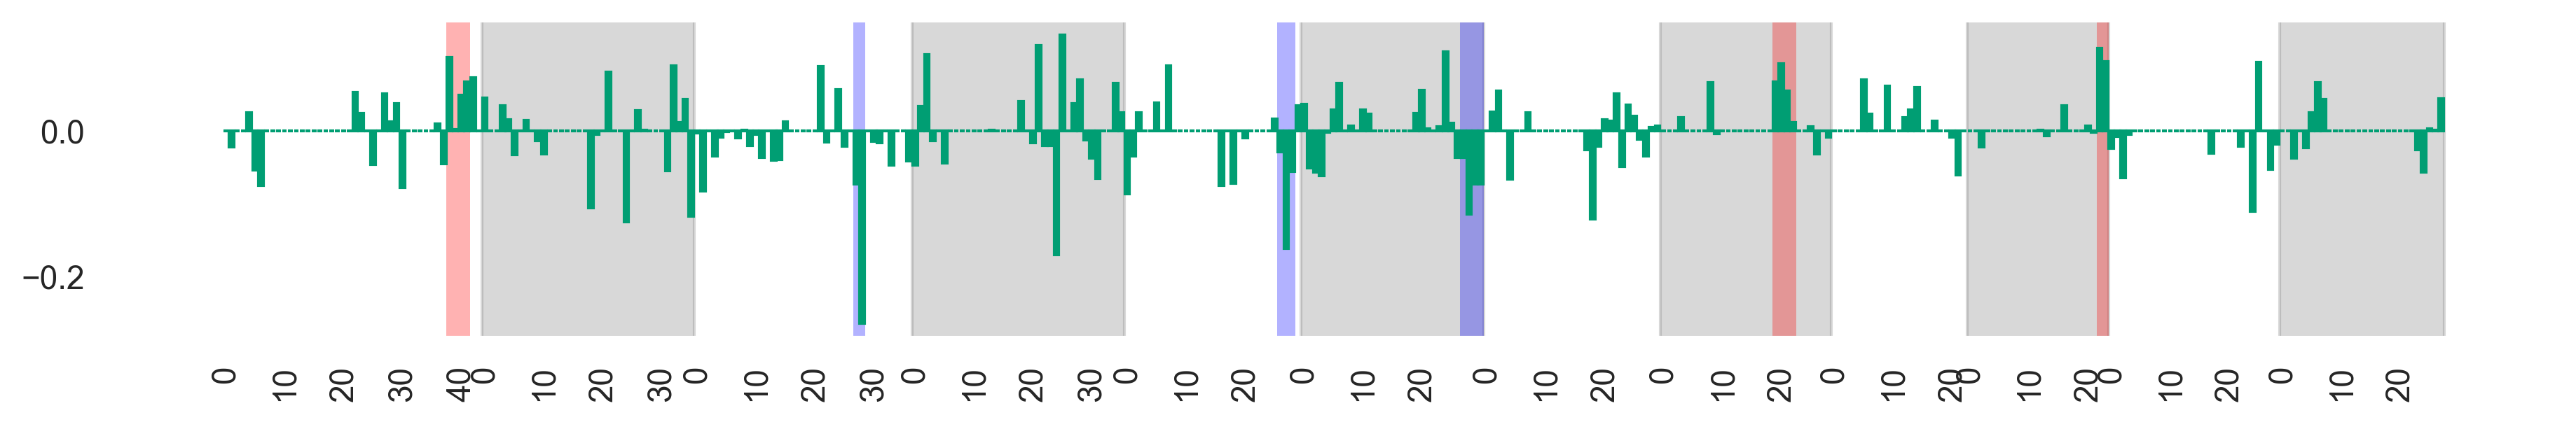

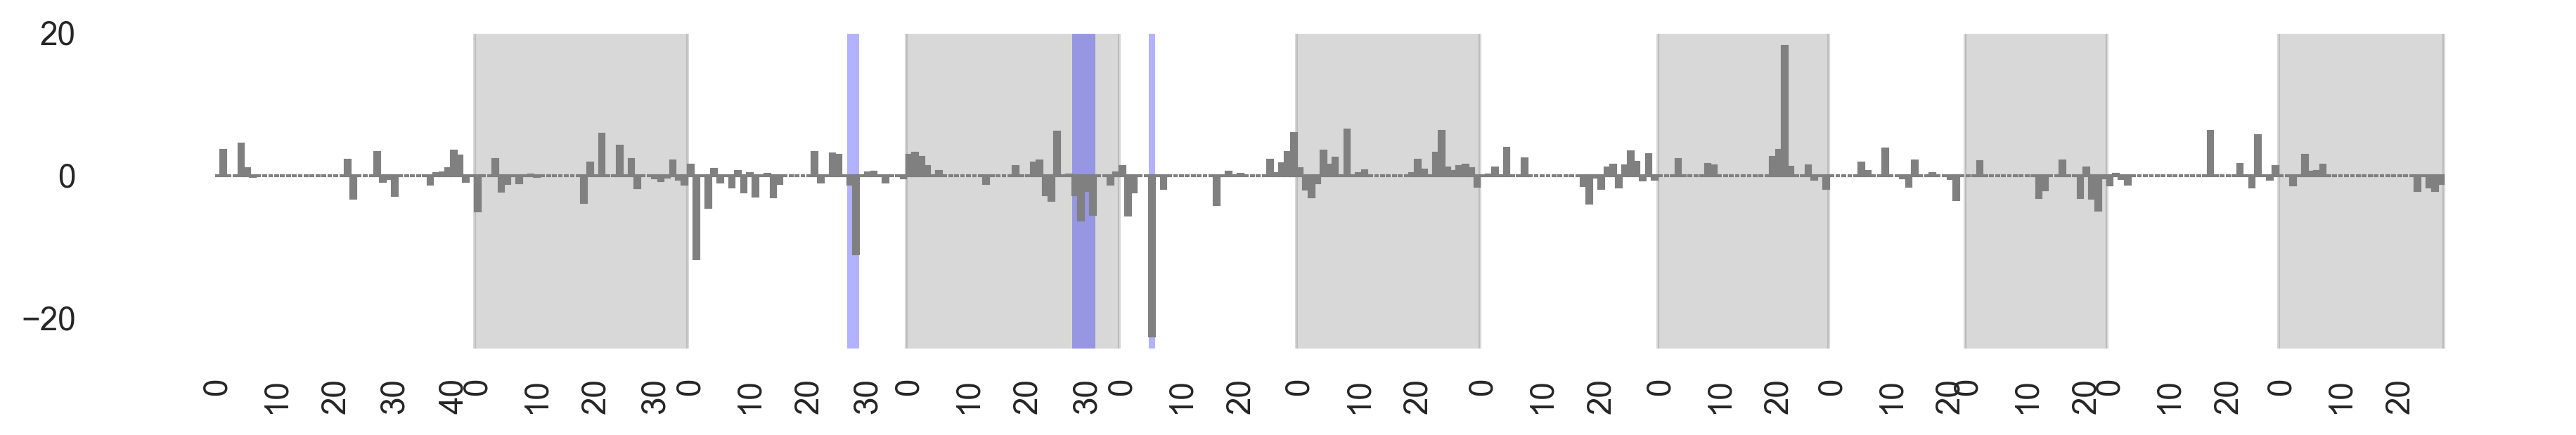

N21


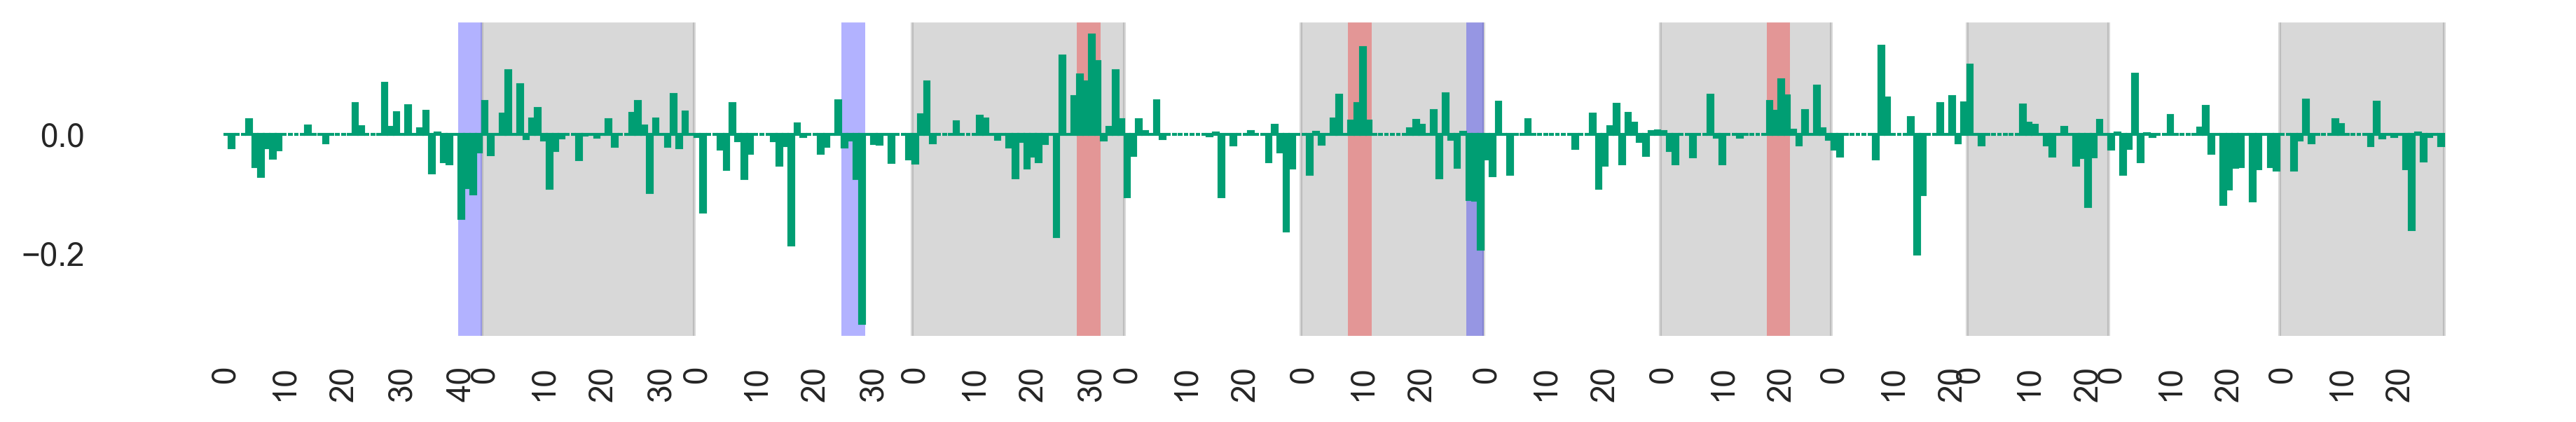

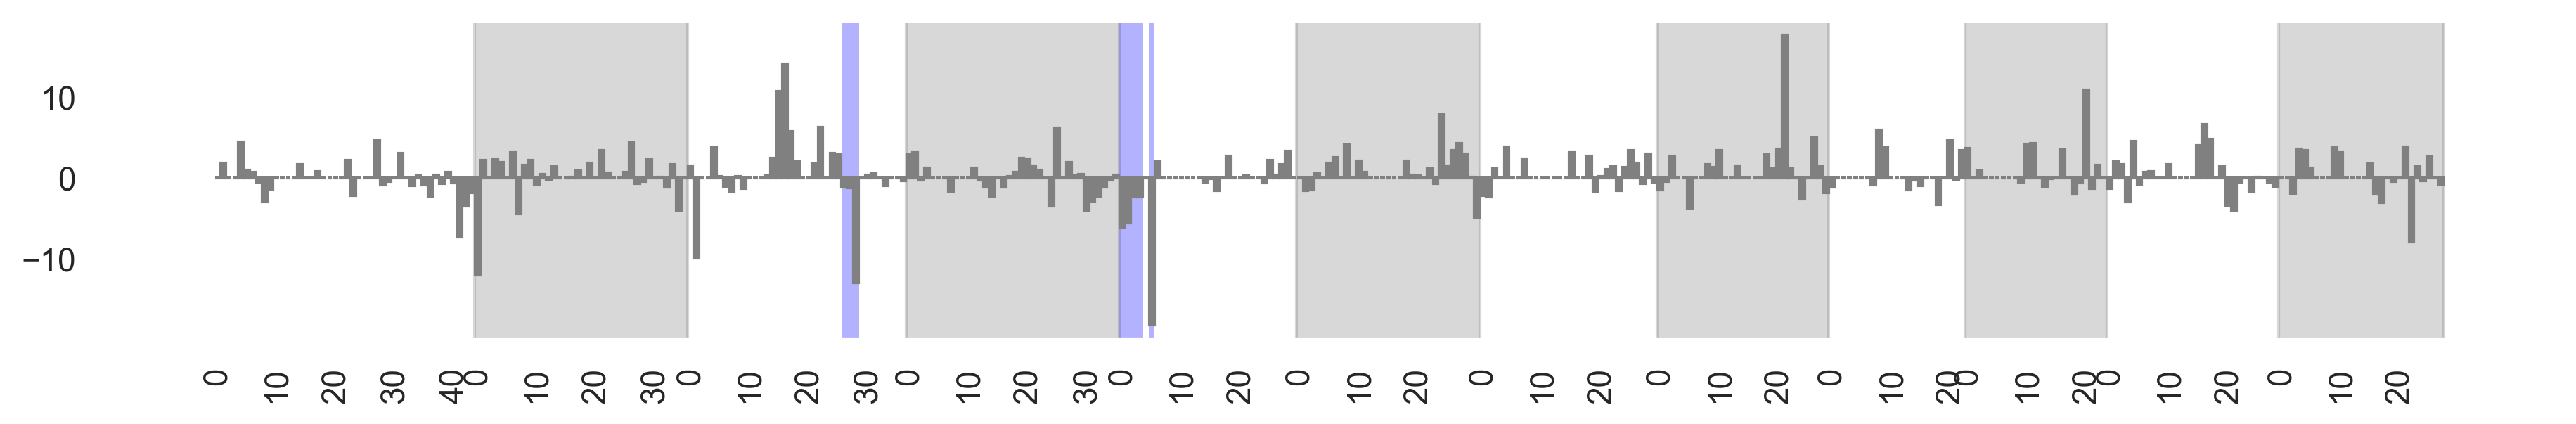

N22


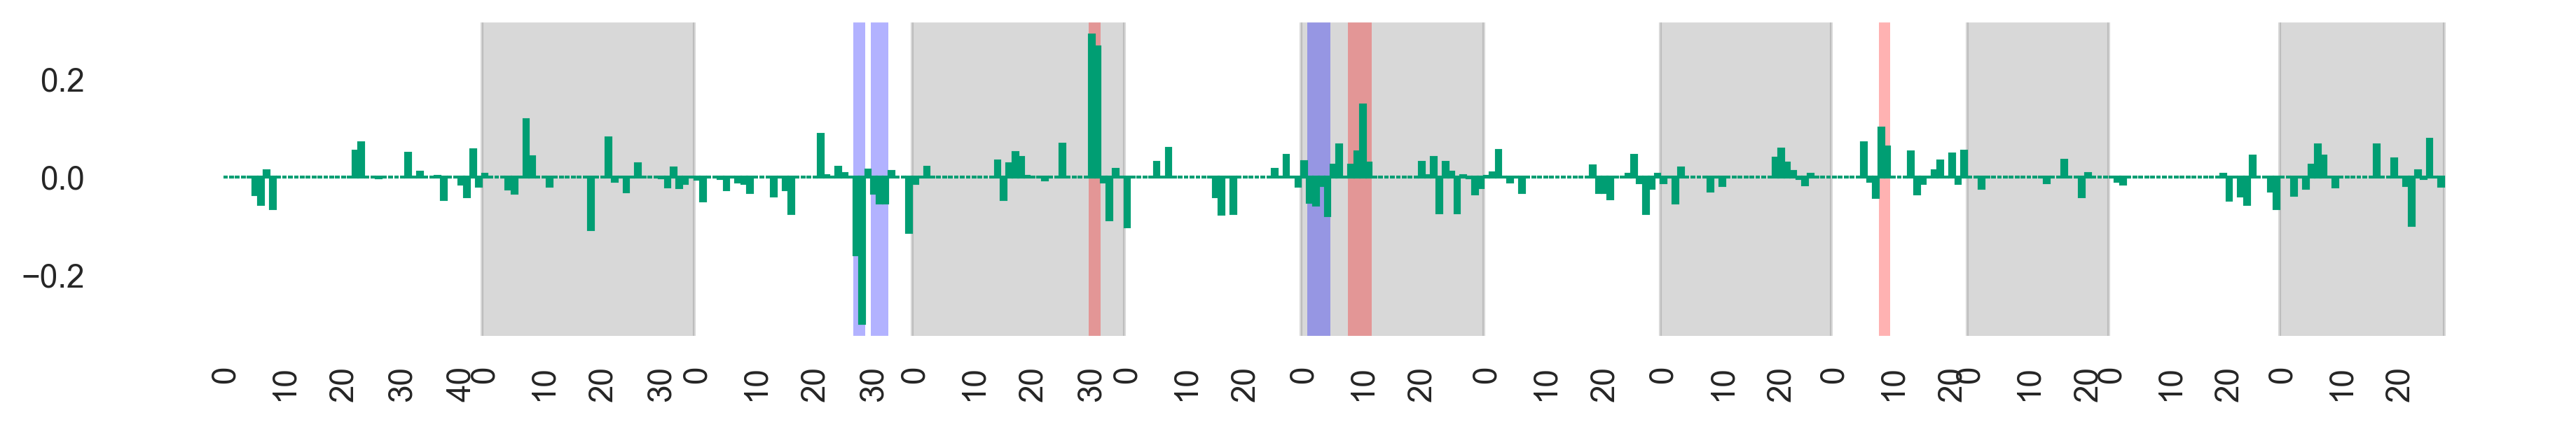

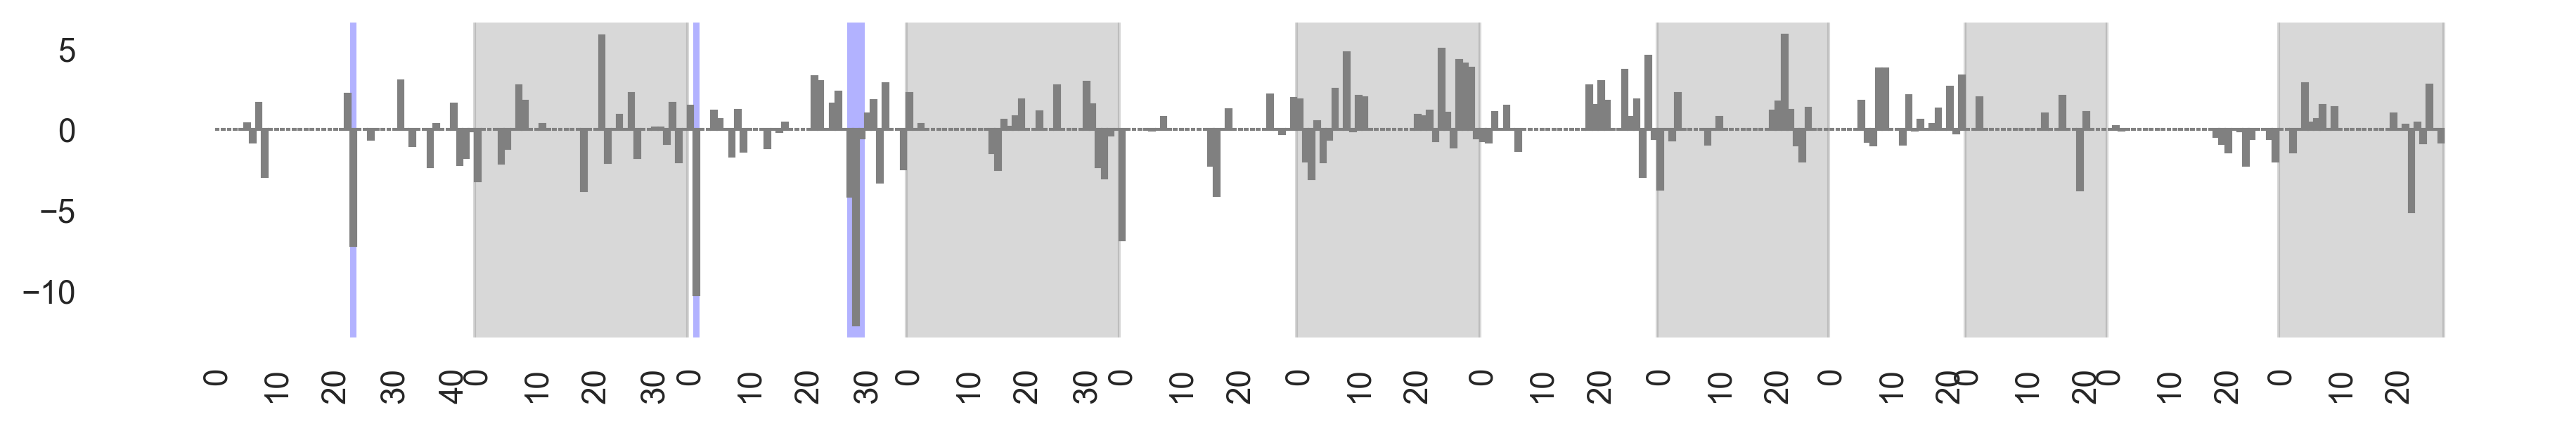

,RIL,PN_plus,PN_plus_regions,PN_plus_region_ratios,PN_minus,PN_minus_region_ratios,PN_merge,zscore_minus,zscore_minus_ratios,Hitome_per,PN_top_regions,PN_worst_regions,Total_worst_regions
226,N18_227,1.722159,3,"1.0, 1.0, 0.5",-0.039005,"0.119, 0, 0",1.683154,3.101775,"0.119, 0, 0",0.669818,"chr04_30-32Mbp,chr12_23-27Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_38-42Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr01_6-10Mbp"
10,N08_011,1.515347,2,"1.0, 1.0, 0",0.000000,"0, 0, 0",1.515347,0.000000,"0, 0, 0",0.685533,"chr04_28-32Mbp,chr12_23-27Mbp,chr02_6-10Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_39-42Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr05_5-8Mbp"
157,N01_160,1.514291,3,"0.234, 1.0, 1.0",0.000000,"0, 0, 0",1.514291,-22.730118,"0, 0.778, 0",0.665381,"chr04_28-32Mbp,chr02_6-10Mbp,chr12_23-27Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_39-42Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
32,N08_033,1.227839,3,"0.459, 0.364, 1.0",0.000000,"0, 0, 0",1.227839,-25.561604,"0, 0.02, 1.0",0.765156,"chr04_28-32Mbp,chr12_23-27Mbp,chr02_6-10Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_39-42Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr05_5-8Mbp"
4,N08_005,1.223888,3,"0.297, 1.0, 0.367",0.000000,"0, 0, 0",1.223888,-5.222383,"0, 0, 0.2",0.819907,"chr04_28-32Mbp,chr12_23-27Mbp,chr02_6-10Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_39-42Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr05_5-8Mbp"


In [28]:
genotype_path = "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv"
Hitome_per_path = "../data/PART0_NAM_stats/Percentage_Hitomebore_genotype.csv"

PN_top_regions_effect_summary = pd.DataFrame()
for pop in [i[:3] for i in family]:
# for pop in ["N07", "N08", "N18"]:
    print(pop)
    regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART6_Select_genomic_regions_and_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
    PN_top_regions = get_top_regions(regional_info_all, "PN_imps", "top", 3)
    PN_worst_regions = get_top_regions(regional_info_all, "PN_imps", "worst", 3)
    Total_worst_regions = get_top_regions(regional_info_all, "sum_zscore", "worst", 3)
    
    plot_regional_info_with_target(regional_info_all, "PN_imps", "#009E73", PN_top_regions, PN_worst_regions)
    plot_regional_info_with_target(regional_info_all, "sum_zscore", "gray", [], Total_worst_regions)
    each_effect_summary = target_effect_summary(imp_data, genotype_path, Hitome_per_path, pop, "PN", PN_top_regions, PN_worst_regions, Total_worst_regions)
    each_effect_summary["PN_top_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in PN_top_regions])
    each_effect_summary["PN_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in PN_worst_regions])
    each_effect_summary["Total_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in Total_worst_regions])
    PN_top_regions_effect_summary = pd.concat([PN_top_regions_effect_summary, each_effect_summary])
PN_top_regions_effect_summary.to_csv("../data/PART6_Select_genomic_regions_and_useful_RILs/Select_RILs_for_PN_stats.csv")
display(PN_top_regions_effect_summary[PN_top_regions_effect_summary.Hitome_per > 0.65].sort_values(by="PN_merge", ascending=False).iloc[:5, :])